# Johnson & Wyandotte County Tax Collection Analysis

Analysis of Local Sales Tax and Use Tax collections for Johnson County, Wyandotte County, and Johnson County cities (2019-2025).

In [464]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [14, 6]
plt.rcParams['figure.dpi'] = 100

# Format currency
def fmt_currency(x):
    return f"${x:,.0f}"

## Data Loading

In [465]:
# Load consolidated tax data
df = pd.read_excel('data/johnson_wyandotte_tax_consolidated.xlsx', sheet_name='All Data (Long)')

# Create date column for time series
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2) + '-01')

# Categorize entities
counties = ['Johnson County', 'Wyandotte County']
df['Entity_Type'] = df['Entity'].apply(lambda x: 'County' if x in counties else 'City')

print(f"Records: {len(df):,}")
print(f"Date range: {df['Date'].min().strftime('%b %Y')} to {df['Date'].max().strftime('%b %Y')}")
print(f"\nEntities ({df['Entity'].nunique()}):")
for e in sorted(df['Entity'].unique()):
    print(f"  - {e}")

Records: 5,960
Date range: Jan 2018 to Nov 2025

Entities (20):
  - DeSoto
  - Edgerton
  - Fairway
  - Gardner
  - Johnson County
  - Leawood
  - Lenexa
  - Merriam
  - Mission
  - Mission Hills
  - Mission Woods
  - Olathe
  - Overland Park
  - Prairie Village
  - Roeland Park
  - Shawnee
  - Spring Hill
  - Westwood
  - Westwood Hills
  - Wyandotte County


In [466]:
# Quick data overview
df.head(10)

,Entity,Tax_Type,Year,Month,Amount,Date,Entity_Type
0,DeSoto,Local Sales Tax,2018,1,73506.486667,2018-01-01,City
1,DeSoto,Local Sales Tax,2018,2,73506.486667,2018-02-01,City
2,DeSoto,Local Sales Tax,2018,3,73506.486667,2018-03-01,City
3,DeSoto,Local Sales Tax,2018,4,73506.486667,2018-04-01,City
4,DeSoto,Local Sales Tax,2018,5,73506.486667,2018-05-01,City
5,DeSoto,Local Sales Tax,2018,6,73506.486667,2018-06-01,City
6,DeSoto,Local Sales Tax,2018,7,73506.486667,2018-07-01,City
7,DeSoto,Local Sales Tax,2018,8,73506.486667,2018-08-01,City
8,DeSoto,Local Sales Tax,2018,9,73506.486667,2018-09-01,City
9,DeSoto,Local Sales Tax,2018,10,73506.486667,2018-10-01,City


## Summary Statistics

In [467]:
# Annual totals by entity and tax type
annual_totals = df.groupby(['Entity', 'Tax_Type', 'Year'])['Amount'].sum().reset_index()

# Pivot for display
annual_pivot = annual_totals.pivot_table(
    index=['Entity', 'Tax_Type'], 
    columns='Year', 
    values='Amount',
    aggfunc='sum'
)

# Format as currency
annual_pivot_fmt = annual_pivot.map(lambda x: f"${x:,.0f}" if pd.notna(x) else "")
annual_pivot_fmt

Year                                      2018          2019          2020  \
Entity           Tax_Type                                                    
DeSoto           Local Sales Tax      $882,078      $901,376    $1,001,473   
                 Use Tax                            $747,757                 
Edgerton         Local Sales Tax      $410,481      $415,367      $479,593   
                 Use Tax                            $182,087                 
Fairway          Local Sales Tax      $809,407      $779,380      $743,004   
                 Use Tax                            $393,125                 
Gardner          Local Sales Tax    $3,584,033    $3,682,650    $4,015,223   
                 Use Tax                            $636,092                 
Johnson County   Local Sales Tax  $176,669,957  $177,848,756  $173,260,529   
                 Use Tax                         $38,859,444                 
Leawood          Local Sales Tax    $8,236,584    $8,367,402    $7,227,382   
                 Use Tax                          $2,662,009                 
Lenexa           Local Sales Tax   $19,044,040   $18,015,292   $18,230,275   
                 Use Tax                          $6,844,492                 
Merriam          Local Sales Tax   $11,499,424   $11,642,541   $11,335,894   
                 Use Tax                            $772,472                 
Mission          Local Sales Tax    $3,951,481    $4,180,982    $4,174,291   
                 Use Tax                          $1,182,988                 
Mission Hills    Local Sales Tax      $627,087      $781,823      $778,842   
                 Use Tax                            $290,710                 
Mission Woods    Local Sales Tax       $25,174       $37,455       $34,338   
                 Use Tax                             $12,136                 
Olathe           Local Sales Tax   $39,546,896   $40,210,085   $40,589,402   
                 Use Tax                          $5,056,695                 
Overland Park    Local Sales Tax   $47,256,300   $46,421,799   $43,425,118   
                 Use Tax                          $9,604,861                 
Prairie Village  Local Sales Tax    $2,548,626    $2,516,909    $2,549,160   
                 Use Tax                            $839,214                 
Roeland Park     Local Sales Tax    $1,791,553    $1,720,313    $1,905,329   
                 Use Tax                            $205,752                 
Shawnee          Local Sales Tax   $16,545,525   $16,773,052   $16,819,324   
                 Use Tax                          $3,232,445                 
Spring Hill      Local Sales Tax    $1,033,225    $1,023,739    $1,131,345   
                 Use Tax                            $326,663                 
Westwood         Local Sales Tax      $438,948      $654,936      $650,432   
                 Use Tax                            $102,686                 
Westwood Hills   Local Sales Tax       $28,924       $34,255       $32,682   
                 Use Tax                             $14,920                 
Wyandotte County Local Sales Tax   $25,501,556   $26,118,005   $25,591,547   
                 Use Tax                          $4,730,175                 

Year                                      2021          2022          2023  \
Entity           Tax_Type                                                    
DeSoto           Local Sales Tax    $1,057,369    $1,015,592    $1,507,334   
                 Use Tax              $817,959      $767,533    $1,044,391   
Edgerton         Local Sales Tax      $523,941      $592,329      $674,555   
                 Use Tax              $253,200      $262,086      $425,015   
Fairway          Local Sales Tax      $789,659      $850,800      $882,916   
                 Use Tax              $570,830      $663,794      $696,538   
Gardner          Local Sales Tax    $4,341,620    $4,804,551    $4,829,397   
                 Use 

In [468]:
# Total collections by entity (all years combined)
entity_totals = df.groupby(['Entity', 'Tax_Type'])['Amount'].sum().unstack(fill_value=0)
entity_totals['Total'] = entity_totals.sum(axis=1)
entity_totals = entity_totals.sort_values('Total', ascending=False)

print("Total Tax Collections by Entity (2019-2025)")
print("=" * 70)
for entity in entity_totals.index:
    row = entity_totals.loc[entity]
    print(f"{entity:25} Sales: {fmt_currency(row['Local Sales Tax']):>15}  Use: {fmt_currency(row['Use Tax']):>15}")

Total Tax Collections by Entity (2019-2025)
Johnson County            Sales:  $1,584,736,795  Use:    $396,848,043
Overland Park             Sales:    $421,388,064  Use:     $97,740,979
Olathe                    Sales:    $358,558,393  Use:     $77,732,658
Wyandotte County          Sales:    $232,425,624  Use:     $47,992,979
Lenexa                    Sales:    $172,092,988  Use:     $60,920,423
Shawnee                   Sales:    $147,498,138  Use:     $35,214,032
Merriam                   Sales:    $108,840,675  Use:      $6,911,949
Leawood                   Sales:     $68,763,245  Use:     $22,437,320
Mission                   Sales:     $36,675,079  Use:      $8,448,425
Gardner                   Sales:     $34,856,074  Use:      $8,000,213
Prairie Village           Sales:     $22,595,196  Use:      $8,523,614
Roeland Park              Sales:     $17,660,879  Use:      $2,613,508
DeSoto                    Sales:     $10,874,036  Use:      $6,618,354
Spring Hill               Sales: 

## Year-over-Year Growth Analysis

In [469]:
# Calculate YoY growth for complete years only (exclude partial 2025)
complete_years = df[df['Year'] < 2025].copy()
annual = complete_years.groupby(['Entity', 'Tax_Type', 'Year'])['Amount'].sum().reset_index()

# Calculate YoY change
annual['Prev_Year'] = annual.groupby(['Entity', 'Tax_Type'])['Amount'].shift(1)
annual['YoY_Change'] = (annual['Amount'] - annual['Prev_Year']) / annual['Prev_Year'] * 100

# Pivot for display
yoy_pivot = annual.pivot_table(
    index=['Entity', 'Tax_Type'],
    columns='Year',
    values='YoY_Change'
).round(1)

print("Year-over-Year Growth (%)")
yoy_pivot

Year-over-Year Growth (%)


Year                              2019  2020   2021  2022  2023  2024
Entity           Tax_Type                                            
DeSoto           Local Sales Tax   2.2  11.1    5.6  -4.0  48.4  49.8
                 Use Tax           NaN   NaN    9.4  -6.2  36.1  65.7
Edgerton         Local Sales Tax   1.2  15.5    9.2  13.1  13.9  -9.9
                 Use Tax           NaN   NaN   39.1   3.5  62.2 -21.4
Fairway          Local Sales Tax  -3.7  -4.7    6.3   7.7   3.8  -4.6
                 Use Tax           NaN   NaN   45.2  16.3   4.9   4.3
Gardner          Local Sales Tax   2.8   9.0    8.1  10.7   0.5   0.7
                 Use Tax           NaN   NaN   77.8  21.1  10.7   3.8
Johnson County   Local Sales Tax   0.7  -2.6   10.7  11.3   3.1   0.8
                 Use Tax           NaN   NaN   51.7  20.6   6.9   1.6
Leawood          Local Sales Tax   1.6 -13.6   11.6  12.4   3.5   1.8
                 Use Tax           NaN   NaN   30.3  18.9  -2.4   1.9
Lenexa           Local Sales Tax  -5.4   1.2   13.7  14.5   4.1  -0.8
                 Use Tax           NaN   NaN   34.8  13.5   7.3   2.2
Merriam          Local Sales Tax   1.2  -2.6   20.9   8.0   5.1  -0.1
                 Use Tax           NaN   NaN   50.1   8.9  -4.5   7.6
Mission          Local Sales Tax   5.8  -0.2    3.1  15.9   2.5   1.8
                 Use Tax           NaN   NaN   32.9 -15.1  22.0  -7.4
Mission Hills    Local Sales Tax  24.7  -0.4   11.5  12.7   8.5   0.8
                 Use Tax           NaN   NaN   54.6  18.8   6.6  13.5
Mission Woods    Local Sales Tax  48.8  -8.3   31.0  61.6 -17.9 -10.6
                 Use Tax           NaN   NaN   46.4  79.2 -17.7  12.2
Olathe           Local Sales Tax   1.7   0.9    8.5   9.3   1.9   1.4
                 Use Tax           NaN   NaN  115.7  35.4  12.0  -2.1
Overland Park    Local Sales Tax  -1.8  -6.5   11.9  10.8   2.7  13.1
                 Use Tax           NaN   NaN   40.2  23.2   5.7  12.1
Prairie Village  Local Sales Tax  -1.2   1.3    5.9  13.8   4.6  -4.5
                 Use Tax           NaN   NaN   55.8  18.9   1.0   3.2
Roeland Park     Local Sales Tax  -4.0  10.8   18.1  11.5   3.1  -1.7
                 Use Tax           NaN   NaN   79.6  29.0   5.2  10.0
Shawnee          Local Sales Tax   1.4   0.3    7.8   7.8   2.4   2.3
                 Use Tax           NaN   NaN   60.0  20.0   3.1   7.7
Spring Hill      Local Sales Tax  -0.9  10.5   19.7  18.2   0.0   8.4
                 Use Tax           NaN   NaN  115.8  17.1  -4.4  10.0
Westwood         Local Sales Tax  49.2  -0.7   13.9  14.3   5.5   5.6
                 Use Tax           NaN   NaN   51.2  10.3  -1.9  26.6
Westwood Hills   Local Sales Tax  18.4  -4.6   -8.9 -10.4   9.1   4.0
                 Use Tax           NaN   NaN   73.5  20.7 -23.3  12.8
Wyandotte County Local Sales Tax   2.4  -2.0   15.0   4.5   3.1   3.0
                 Use Tax           NaN   NaN   50.6  15.7  -6.6  39.4

In [470]:
# Average annual growth by entity
avg_growth = annual[annual['Year'] >= 2020].groupby(['Entity', 'Tax_Type'])['YoY_Change'].mean().unstack()
avg_growth = avg_growth.round(1).sort_values('Local Sales Tax', ascending=False)

print("Average Annual Growth Rate (2020-2024)")
print("=" * 50)
avg_growth

Average Annual Growth Rate (2020-2024)


Tax_Type,Local Sales Tax,Use Tax
Entity,,
DeSoto,22.2,26.3
Spring Hill,11.4,34.7
Mission Woods,11.2,30.0
Roeland Park,8.3,31.0
Edgerton,8.3,20.8
Westwood,7.7,21.6
Mission Hills,6.6,23.4
Lenexa,6.5,14.4
Overland Park,6.4,20.3


## Time Series Visualizations

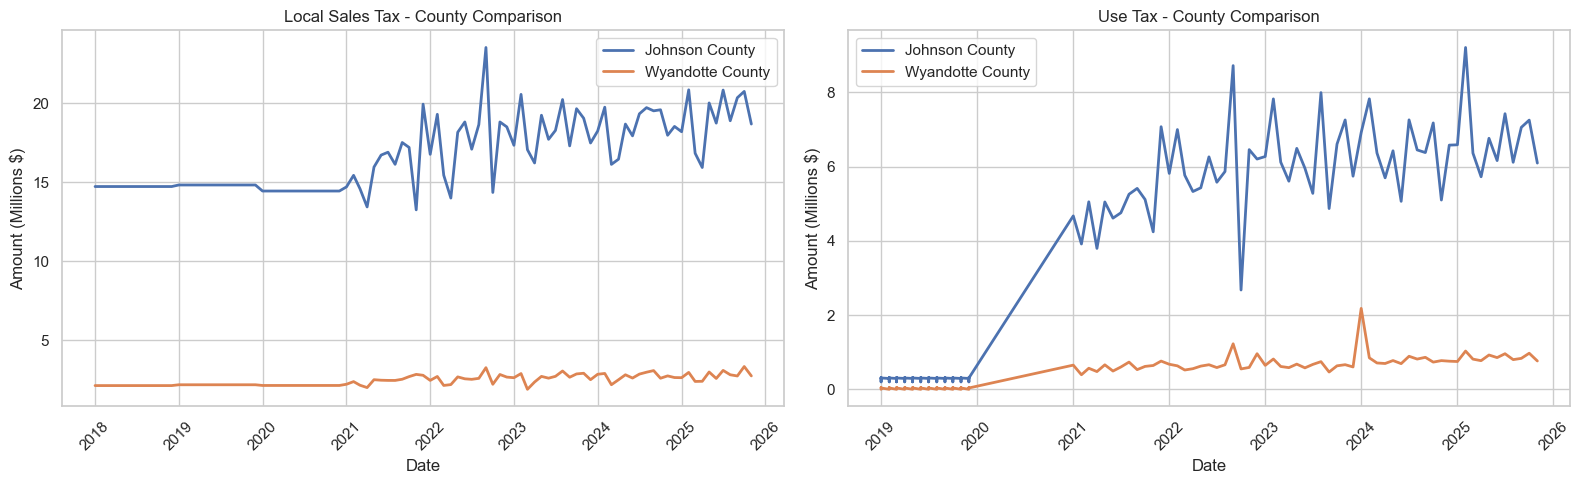

In [471]:
# Monthly collections - Counties comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx, tax_type in enumerate(['Local Sales Tax', 'Use Tax']):
    ax = axes[idx]
    county_data = df[(df['Entity_Type'] == 'County') & (df['Tax_Type'] == tax_type)]
    
    for entity in counties:
        entity_data = county_data[county_data['Entity'] == entity]
        ax.plot(entity_data['Date'], entity_data['Amount'] / 1e6, label=entity, linewidth=2)
    
    ax.set_title(f'{tax_type} - County Comparison')
    ax.set_xlabel('Date')
    ax.set_ylabel('Amount (Millions $)')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

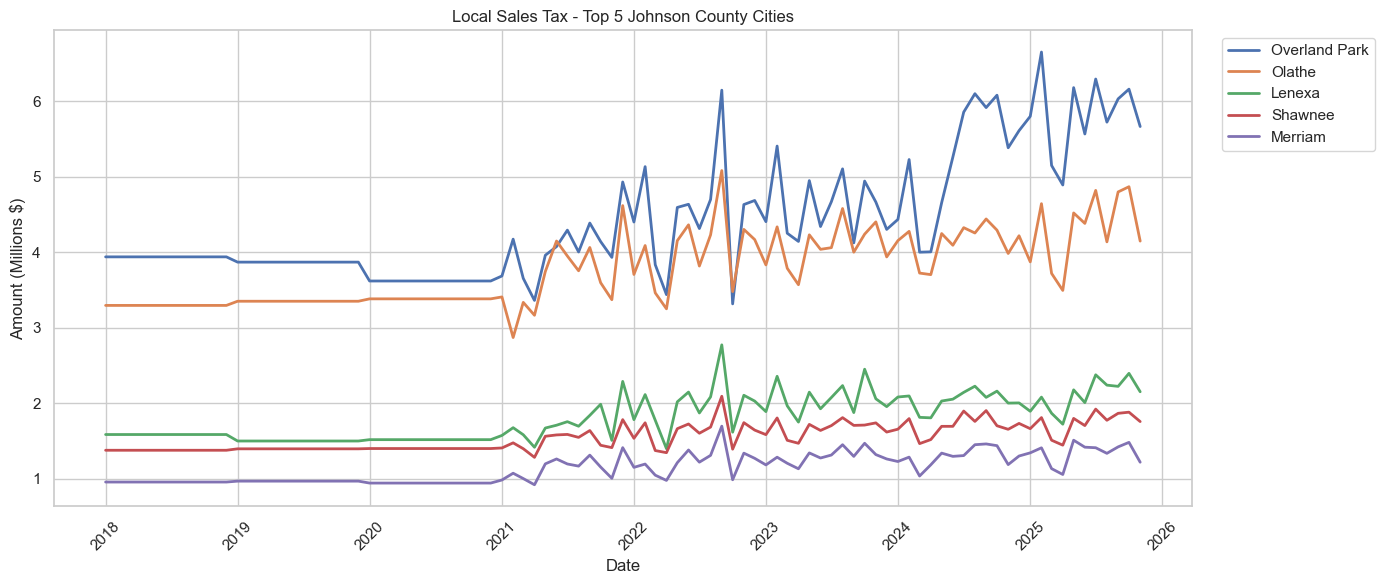

In [472]:
# Top 5 cities by total sales tax
city_totals = df[(df['Entity_Type'] == 'City') & (df['Tax_Type'] == 'Local Sales Tax')].groupby('Entity')['Amount'].sum()
top_cities = city_totals.nlargest(5).index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))

city_data = df[(df['Entity'].isin(top_cities)) & (df['Tax_Type'] == 'Local Sales Tax')]
for city in top_cities:
    data = city_data[city_data['Entity'] == city]
    ax.plot(data['Date'], data['Amount'] / 1e6, label=city, linewidth=2)

ax.set_title('Local Sales Tax - Top 5 Johnson County Cities')
ax.set_xlabel('Date')
ax.set_ylabel('Amount (Millions $)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

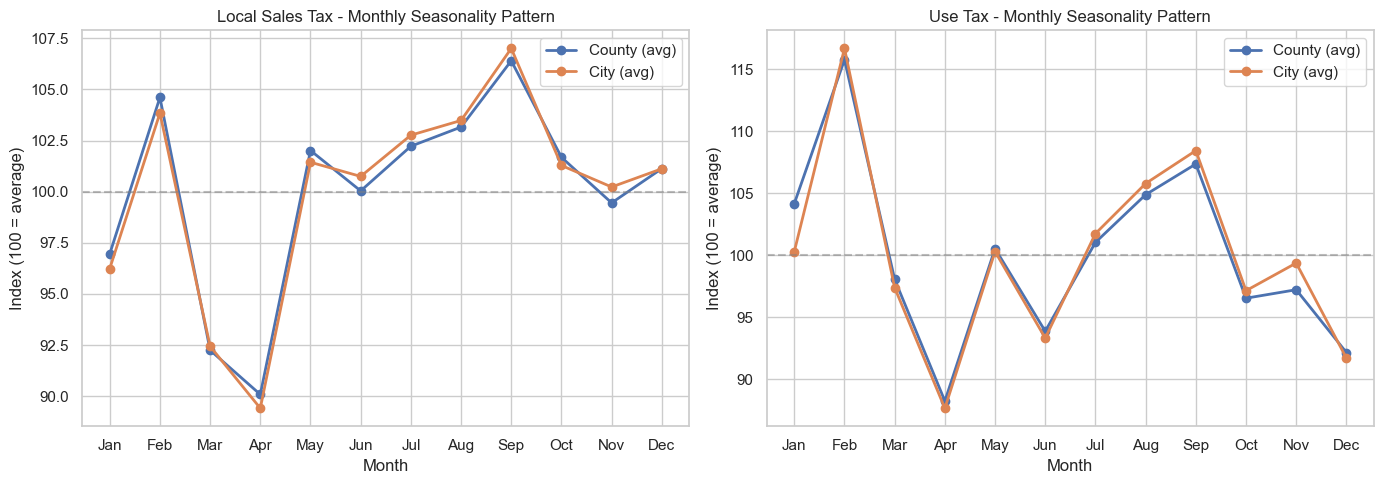

In [473]:
# Seasonality analysis - Monthly patterns
monthly_avg = df.groupby(['Entity_Type', 'Tax_Type', 'Month'])['Amount'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, tax_type in enumerate(['Local Sales Tax', 'Use Tax']):
    ax = axes[idx]
    for entity_type in ['County', 'City']:
        data = monthly_avg[(monthly_avg['Entity_Type'] == entity_type) & (monthly_avg['Tax_Type'] == tax_type)]
        # Normalize to show relative pattern
        normalized = data.groupby('Month')['Amount'].sum()
        normalized = normalized / normalized.mean() * 100
        ax.plot(range(1, 13), normalized.values, marker='o', label=f'{entity_type} (avg)', linewidth=2)
    
    ax.set_title(f'{tax_type} - Monthly Seasonality Pattern')
    ax.set_xlabel('Month')
    ax.set_ylabel('Index (100 = average)')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5)
    ax.legend()

plt.tight_layout()
plt.show()

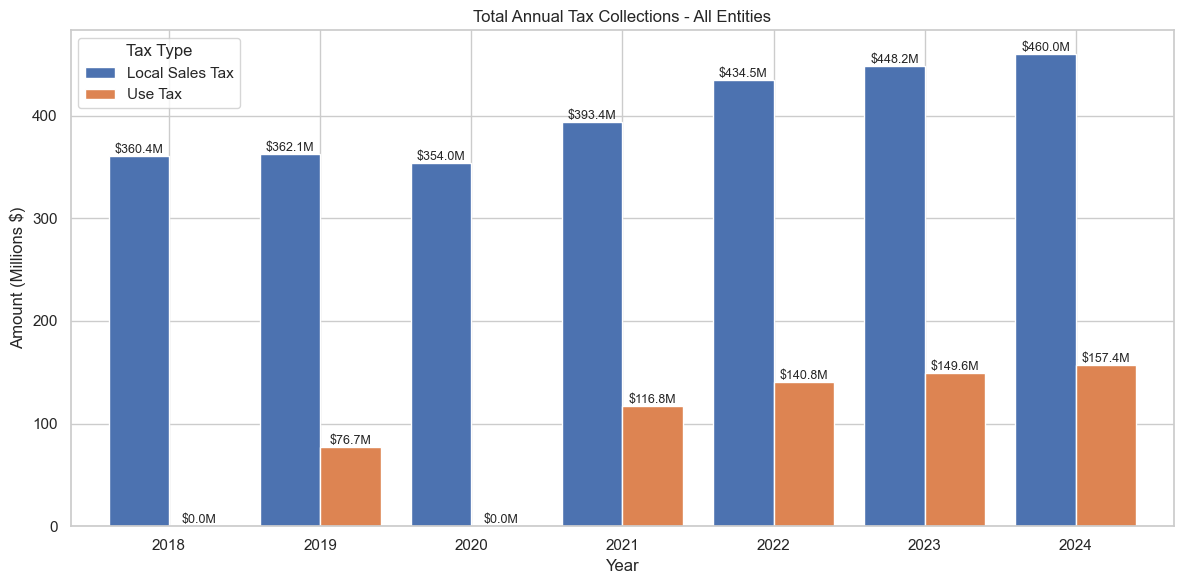

In [474]:
# Annual totals bar chart
annual_by_type = df[df['Year'] < 2025].groupby(['Year', 'Tax_Type'])['Amount'].sum().unstack() / 1e6

fig, ax = plt.subplots(figsize=(12, 6))
annual_by_type.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Total Annual Tax Collections - All Entities')
ax.set_xlabel('Year')
ax.set_ylabel('Amount (Millions $)')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Tax Type')

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='$%.1fM', fontsize=9)

plt.tight_layout()
plt.show()

## Entity Comparison

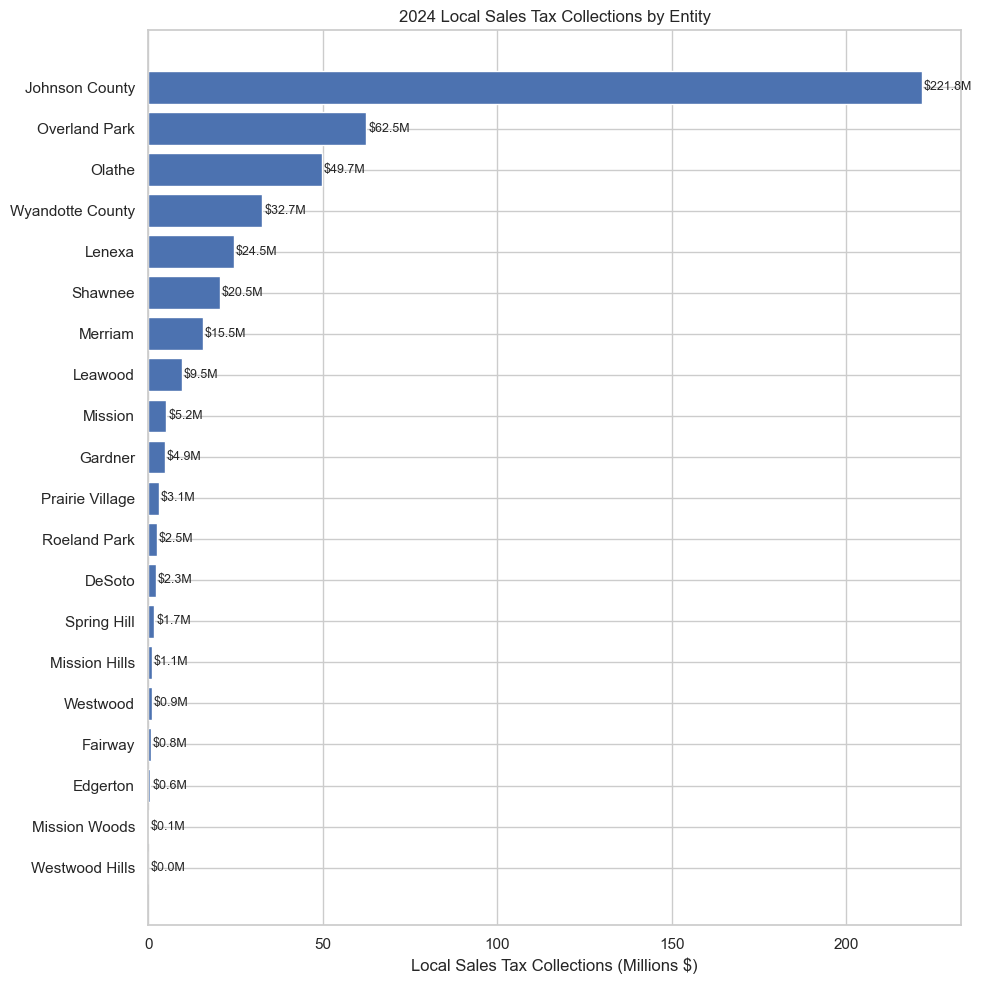

In [475]:
# Share of total collections by entity (2024)
data_2024 = df[(df['Year'] == 2024) & (df['Tax_Type'] == 'Local Sales Tax')]
entity_2024 = data_2024.groupby('Entity')['Amount'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
bars = ax.barh(entity_2024.index, entity_2024.values / 1e6)
ax.set_xlabel('Local Sales Tax Collections (Millions $)')
ax.set_title('2024 Local Sales Tax Collections by Entity')

# Add value labels
for bar, val in zip(bars, entity_2024.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
            f'${val/1e6:.1f}M', va='center', fontsize=9)

plt.tight_layout()
plt.show()

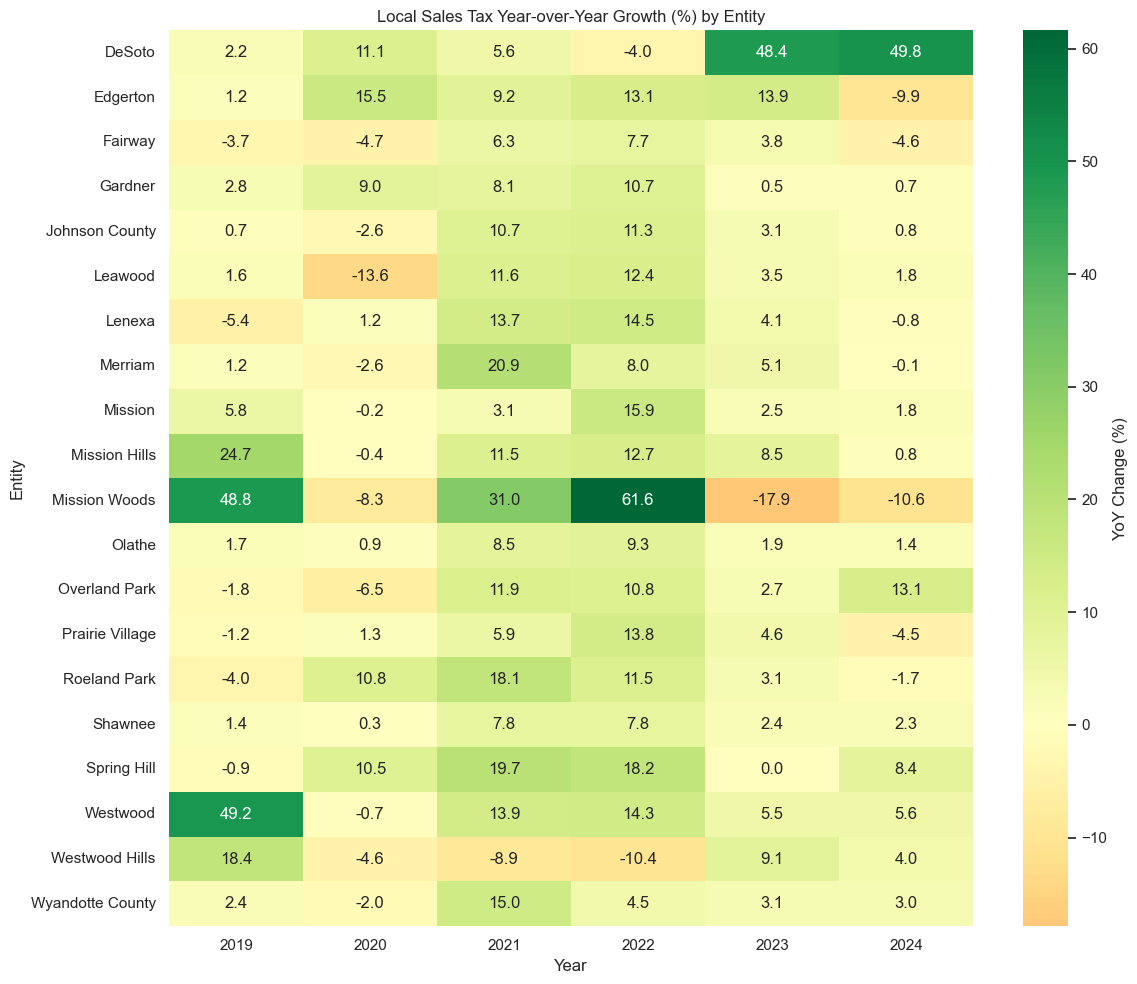

In [476]:
# Heatmap of YoY growth by entity
sales_tax_annual = df[(df['Tax_Type'] == 'Local Sales Tax') & (df['Year'] < 2025)].groupby(['Entity', 'Year'])['Amount'].sum().unstack()
sales_tax_yoy = sales_tax_annual.pct_change(axis=1) * 100

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(sales_tax_yoy.iloc[:, 1:], annot=True, fmt='.1f', cmap='RdYlGn', center=0, 
            ax=ax, cbar_kws={'label': 'YoY Change (%)'})
ax.set_title('Local Sales Tax Year-over-Year Growth (%) by Entity')
ax.set_xlabel('Year')
ax.set_ylabel('Entity')
plt.tight_layout()
plt.show()

## Johnson County Cities Analysis

In [477]:
# Johnson County cities only (excluding counties)
joco_cities = df[(df['Entity_Type'] == 'City') & (df['Tax_Type'] == 'Local Sales Tax')].copy()

# Market share over time
city_annual = joco_cities.groupby(['Entity', 'Year'])['Amount'].sum().unstack()
city_share = city_annual.div(city_annual.sum()) * 100

print("Market Share of Johnson County City Sales Tax Collections (%)")
city_share.round(1)

Market Share of Johnson County City Sales Tax Collections (%)


Year,2018,2019,2020,2021,2022,2023,2024,2025
Entity,,,,,,,,
DeSoto,0.6,0.6,0.6,0.6,0.5,0.8,1.1,1.1
Edgerton,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3
Fairway,0.5,0.5,0.5,0.5,0.4,0.4,0.4,0.4
Gardner,2.3,2.3,2.6,2.5,2.5,2.5,2.4,2.4
Leawood,5.2,5.3,4.7,4.7,4.8,4.8,4.6,4.5
Lenexa,12.0,11.4,11.8,12.0,12.5,12.6,11.9,11.6
Merriam,7.3,7.4,7.3,8.0,7.8,7.9,7.6,7.4
Mission,2.5,2.6,2.7,2.5,2.6,2.6,2.5,2.4
Mission Hills,0.4,0.5,0.5,0.5,0.5,0.5,0.5,0.5


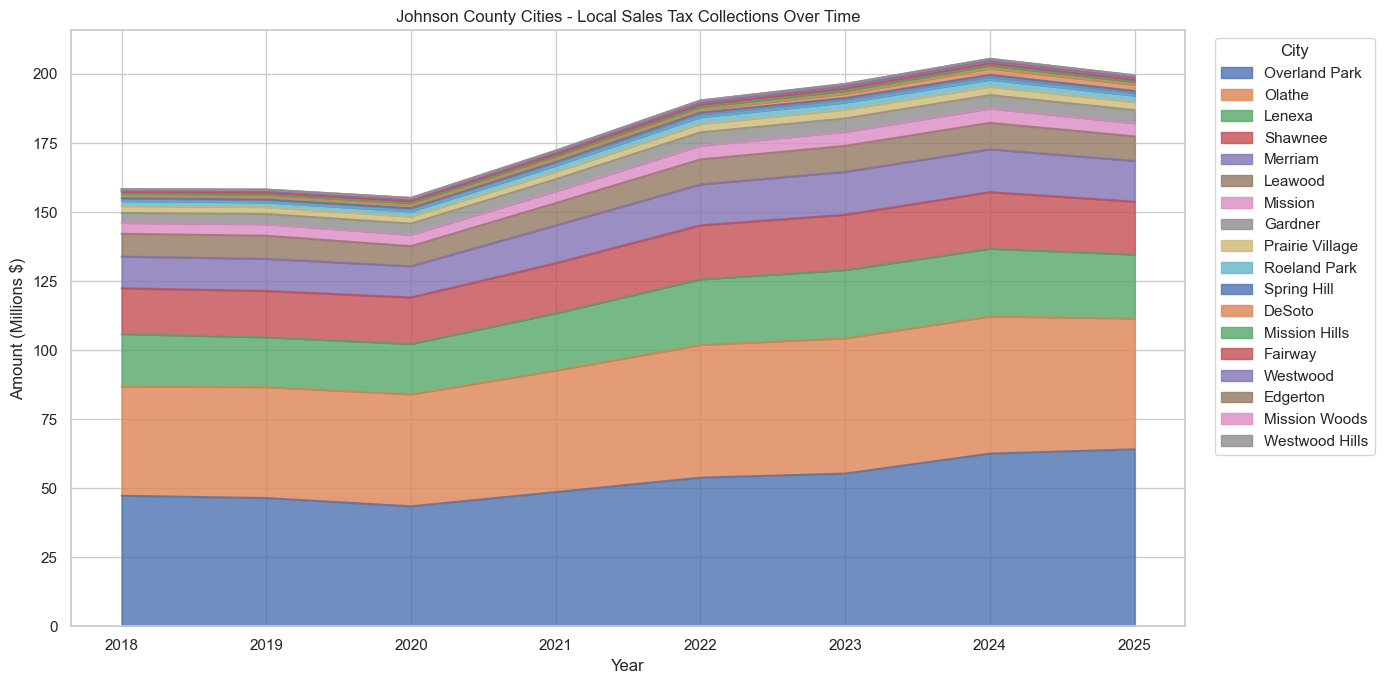

In [478]:
# Stacked area chart of city contributions
fig, ax = plt.subplots(figsize=(14, 7))

# Sort cities by total collections
city_order = city_annual.sum(axis=1).sort_values(ascending=False).index
city_annual_sorted = city_annual.loc[city_order].T / 1e6

city_annual_sorted.plot(kind='area', stacked=True, ax=ax, alpha=0.8)
ax.set_title('Johnson County Cities - Local Sales Tax Collections Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Amount (Millions $)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='City')
plt.tight_layout()
plt.show()

## Bond Projections

Use the historical tax data to project future revenues for bond analysis.

In [479]:
# Simple projection based on average growth rate
def project_revenue(entity, tax_type, years_ahead=5):
    """Project future revenue based on historical growth."""
    entity_data = df[(df['Entity'] == entity) & (df['Tax_Type'] == tax_type) & (df['Year'] < 2025)]
    annual = entity_data.groupby('Year')['Amount'].sum()
    
    # Calculate CAGR
    start_val = annual.iloc[0]
    end_val = annual.iloc[-1]
    n_years = len(annual) - 1
    cagr = (end_val / start_val) ** (1 / n_years) - 1
    
    # Project
    last_year = annual.index[-1]
    last_val = annual.iloc[-1]
    
    projections = {}
    for i in range(1, years_ahead + 1):
        proj_year = last_year + i
        proj_val = last_val * ((1 + cagr) ** i)
        projections[proj_year] = proj_val
    
    return {
        'historical': annual.to_dict(),
        'projections': projections,
        'cagr': cagr
    }

# Example projection for Johnson County
joco_proj = project_revenue('Johnson County', 'Local Sales Tax', years_ahead=5)
print(f"Johnson County Local Sales Tax Projection")
print(f"CAGR (2019-2024): {joco_proj['cagr']:.1%}")
print(f"\nHistorical:")
for year, val in joco_proj['historical'].items():
    print(f"  {year}: {fmt_currency(val)}")
print(f"\nProjected:")
for year, val in joco_proj['projections'].items():
    print(f"  {year}: {fmt_currency(val)}")

Johnson County Local Sales Tax Projection
CAGR (2019-2024): 3.9%

Historical:
  2018: $176,669,957
  2019: $177,848,756
  2020: $173,260,529
  2021: $191,720,706
  2022: $213,360,537
  2023: $220,070,599
  2024: $221,789,700

Projected:
  2025: $230,358,629
  2026: $239,258,622
  2027: $248,502,469
  2028: $258,103,456
  2029: $268,075,381


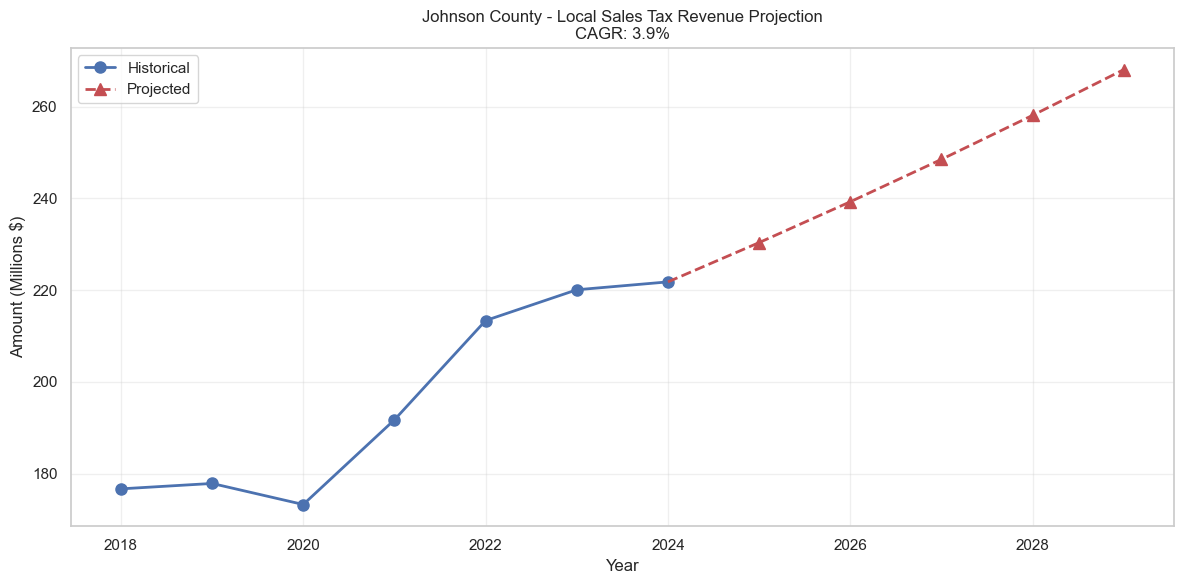

In [480]:
# Projection visualization
def plot_projection(entity, tax_type):
    proj = project_revenue(entity, tax_type)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Historical
    hist_years = list(proj['historical'].keys())
    hist_vals = [v / 1e6 for v in proj['historical'].values()]
    ax.plot(hist_years, hist_vals, 'bo-', linewidth=2, markersize=8, label='Historical')
    
    # Projected
    proj_years = list(proj['projections'].keys())
    proj_vals = [v / 1e6 for v in proj['projections'].values()]
    ax.plot(proj_years, proj_vals, 'r^--', linewidth=2, markersize=8, label='Projected')
    
    # Connect historical to projected
    ax.plot([hist_years[-1], proj_years[0]], [hist_vals[-1], proj_vals[0]], 'r--', linewidth=2)
    
    ax.set_title(f'{entity} - {tax_type} Revenue Projection\nCAGR: {proj["cagr"]:.1%}')
    ax.set_xlabel('Year')
    ax.set_ylabel('Amount (Millions $)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_projection('Johnson County', 'Local Sales Tax')

In [481]:
# Compare projections for multiple entities
entities_to_project = ['Johnson County', 'Wyandotte County', 'Overland Park', 'Olathe']

print("5-Year Revenue Projections (Local Sales Tax)")
print("=" * 80)

for entity in entities_to_project:
    proj = project_revenue(entity, 'Local Sales Tax')
    print(f"\n{entity} (CAGR: {proj['cagr']:.1%})")
    print(f"  2024 Actual: {fmt_currency(proj['historical'][2024])}")
    print(f"  2029 Projected: {fmt_currency(proj['projections'][2029])}")
    growth = (proj['projections'][2029] - proj['historical'][2024]) / proj['historical'][2024] * 100
    print(f"  5-Year Growth: {growth:.1f}%")

5-Year Revenue Projections (Local Sales Tax)

Johnson County (CAGR: 3.9%)
  2024 Actual: $221,789,700
  2029 Projected: $268,075,381
  5-Year Growth: 20.9%

Wyandotte County (CAGR: 4.2%)
  2024 Actual: $32,676,896
  2029 Projected: $40,176,235
  5-Year Growth: 22.9%

Overland Park (CAGR: 4.8%)
  2024 Actual: $62,510,061
  2029 Projected: $78,920,851
  5-Year Growth: 26.3%

Olathe (CAGR: 3.9%)
  2024 Actual: $49,703,253
  2029 Projected: $60,132,855
  5-Year Growth: 21.0%


## Export Analysis Results

In [482]:
# Export summary tables to Excel
with pd.ExcelWriter('data/tax_analysis_results.xlsx', engine='openpyxl') as writer:
    # Annual totals
    annual_pivot.to_excel(writer, sheet_name='Annual Totals')
    
    # YoY growth
    yoy_pivot.to_excel(writer, sheet_name='YoY Growth')
    
    # Entity totals
    entity_totals.to_excel(writer, sheet_name='Entity Totals')
    
    # City market share
    city_share.to_excel(writer, sheet_name='City Market Share')

print("Results exported to data/tax_analysis_results.xlsx")

Results exported to data/tax_analysis_results.xlsx


## STAR Bond Increment Schedule

Generate a 30-year schedule of estimated increment from combined revenue sources:
- **Sales + Use Tax**: State sales and use tax captured via STAR district
- **Alcohol**: Liquor Enforcement Tax (LET) + Liquor Drink Tax (state portion)
- **Gambling**: Sports Wagering APSK Fund (65% pledged to STAR bonds)

All projections use CPI-based annual growth. Adjust parameters below to model different scenarios.

In [483]:
# =============================================================================
# ADJUSTABLE PARAMETERS - Modify these values to model different scenarios
# =============================================================================

# CPI / Growth Rate Assumptions
CPI_SALES_USE = 0.025          # Annual growth rate for sales + use tax (2.5% default)
CPI_ALCOHOL = 0.02             # Annual growth rate for alcohol taxes (2% default)
CPI_GAMBLING = 0.03            # Annual growth rate for gambling revenues (3% default)

# Base Year Revenue Amounts (Year 0 - pre-increment baseline)
# Sales + Use Tax Base (state portion captured by STAR district)
BASE_SALES_TAX = 495_000_000   # $495M - state sales tax base (grocery-adjusted)
BASE_USE_TAX = 173_000_000     # $173M - state use tax base (34.9% of sales)
BASE_SALES_USE_TOTAL = BASE_SALES_TAX + BASE_USE_TAX  # $668M combined

# Alcohol Tax Bases (district portion)
BASE_LET = 17_400_000          # $17.4M - Liquor Enforcement Tax (8% on retail liquor)
BASE_DRINK_TAX = 8_200_000     # $8.2M - Liquor Drink Tax (10% state portion)
BASE_ALCOHOL_TOTAL = BASE_LET + BASE_DRINK_TAX  # $25.6M combined

# Gambling / Sports Wagering Base
BASE_APSK_TOTAL = 8_700_000    # $8.7M - Total APSK Fund annual intake
APSK_STAR_PLEDGE_PCT = 0.65    # 65% of APSK pledged to STAR bonds
BASE_GAMBLING = BASE_APSK_TOTAL * APSK_STAR_PLEDGE_PCT  # ~$5.66M

# Bond Term
BOND_TERM_YEARS = 30           # 30-year bond term

# Display settings
SHOW_ANNUAL_DETAIL = True      # Show year-by-year table
SHOW_CUMULATIVE = True         # Show cumulative totals

print("=" * 70)
print("STAR BOND INCREMENT MODEL - PARAMETER SUMMARY")
print("=" * 70)
print(f"\n📈 GROWTH RATES (CPI)")
print(f"   Sales + Use Tax:  {CPI_SALES_USE:.1%}")
print(f"   Alcohol Taxes:    {CPI_ALCOHOL:.1%}")
print(f"   Gambling/APSK:    {CPI_GAMBLING:.1%}")
print(f"\n💰 BASE YEAR AMOUNTS (Year 0)")
print(f"   Sales Tax Base:   ${BASE_SALES_TAX:>15,.0f}")
print(f"   Use Tax Base:     ${BASE_USE_TAX:>15,.0f}")
print(f"   Sales+Use Total:  ${BASE_SALES_USE_TOTAL:>15,.0f}")
print(f"   LET Base:         ${BASE_LET:>15,.0f}")
print(f"   Drink Tax Base:   ${BASE_DRINK_TAX:>15,.0f}")
print(f"   Alcohol Total:    ${BASE_ALCOHOL_TOTAL:>15,.0f}")
print(f"   APSK Total:       ${BASE_APSK_TOTAL:>15,.0f}")
print(f"   APSK to STAR:     ${BASE_GAMBLING:>15,.0f} ({APSK_STAR_PLEDGE_PCT:.0%} pledged)")
print(f"\n⏱️  BOND TERM: {BOND_TERM_YEARS} years")
print("=" * 70)

STAR BOND INCREMENT MODEL - PARAMETER SUMMARY

📈 GROWTH RATES (CPI)
   Sales + Use Tax:  2.5%
   Alcohol Taxes:    2.0%
   Gambling/APSK:    3.0%

💰 BASE YEAR AMOUNTS (Year 0)
   Sales Tax Base:   $    495,000,000
   Use Tax Base:     $    173,000,000
   Sales+Use Total:  $    668,000,000
   LET Base:         $     17,400,000
   Drink Tax Base:   $      8,200,000
   Alcohol Total:    $     25,600,000
   APSK Total:       $      8,700,000
   APSK to STAR:     $      5,655,000 (65% pledged)

⏱️  BOND TERM: 30 years


In [484]:
# =============================================================================
# GENERATE 30-YEAR INCREMENT SCHEDULE
# =============================================================================

def generate_increment_schedule(
    years: int,
    base_sales_use: float,
    base_alcohol: float,
    base_gambling: float,
    cpi_sales_use: float,
    cpi_alcohol: float,
    cpi_gambling: float
) -> pd.DataFrame:
    """
    Generate a year-by-year schedule of STAR bond increment revenues.
    
    Increment = (Current Year Revenue) - (Base Year Revenue)
    
    Returns DataFrame with columns for each revenue source and totals.
    """
    records = []
    
    for year in range(0, years + 1):
        # Calculate current year revenues (compounded growth)
        current_sales_use = base_sales_use * ((1 + cpi_sales_use) ** year)
        current_alcohol = base_alcohol * ((1 + cpi_alcohol) ** year)
        current_gambling = base_gambling * ((1 + cpi_gambling) ** year)
        
        # Calculate increment (current - base)
        # Year 0 has no increment (it's the base year)
        if year == 0:
            increment_sales_use = 0
            increment_alcohol = 0
            increment_gambling = 0
        else:
            increment_sales_use = current_sales_use - base_sales_use
            increment_alcohol = current_alcohol - base_alcohol
            increment_gambling = current_gambling - base_gambling
        
        total_increment = increment_sales_use + increment_alcohol + increment_gambling
        
        records.append({
            'Year': year,
            'Sales+Use_Current': current_sales_use,
            'Sales+Use_Increment': increment_sales_use,
            'Alcohol_Current': current_alcohol,
            'Alcohol_Increment': increment_alcohol,
            'Gambling_Current': current_gambling,
            'Gambling_Increment': increment_gambling,
            'Total_Increment': total_increment
        })
    
    df = pd.DataFrame(records)
    
    # Add cumulative columns
    df['Sales+Use_Cumulative'] = df['Sales+Use_Increment'].cumsum()
    df['Alcohol_Cumulative'] = df['Alcohol_Increment'].cumsum()
    df['Gambling_Cumulative'] = df['Gambling_Increment'].cumsum()
    df['Total_Cumulative'] = df['Total_Increment'].cumsum()
    
    return df

# Generate the schedule with current parameters
schedule = generate_increment_schedule(
    years=BOND_TERM_YEARS,
    base_sales_use=BASE_SALES_USE_TOTAL,
    base_alcohol=BASE_ALCOHOL_TOTAL,
    base_gambling=BASE_GAMBLING,
    cpi_sales_use=CPI_SALES_USE,
    cpi_alcohol=CPI_ALCOHOL,
    cpi_gambling=CPI_GAMBLING
)

print(f"Schedule generated: {len(schedule)} years (Year 0 through Year {BOND_TERM_YEARS})")

Schedule generated: 31 years (Year 0 through Year 30)


In [485]:
# =============================================================================
# DISPLAY ANNUAL INCREMENT SCHEDULE
# =============================================================================

def format_schedule_display(df: pd.DataFrame) -> pd.DataFrame:
    """Format schedule for display with currency formatting."""
    display_df = df[['Year', 'Sales+Use_Increment', 'Alcohol_Increment', 
                     'Gambling_Increment', 'Total_Increment']].copy()
    
    display_df.columns = ['Year', 'Sales+Use Tax', 'Alcohol', 'Gambling', 'Total Increment']
    
    # Format as currency (millions)
    for col in ['Sales+Use Tax', 'Alcohol', 'Gambling', 'Total Increment']:
        display_df[col] = display_df[col].apply(lambda x: f"${x/1e6:,.2f}M")
    
    return display_df

if SHOW_ANNUAL_DETAIL:
    print("=" * 80)
    print("ANNUAL INCREMENT SCHEDULE (Year 0 = Base Year, no increment)")
    print("=" * 80)
    display_schedule = format_schedule_display(schedule)
    # Show key years: 0, 1, 5, 10, 15, 20, 25, 30
    key_years = [0, 1, 5, 10, 15, 20, 25, 30]
    key_years = [y for y in key_years if y <= BOND_TERM_YEARS]
    print(display_schedule[display_schedule['Year'].isin(key_years)].to_string(index=False))
    print("\n(Showing key years only. Full schedule available in 'schedule' DataFrame)")

# Show full table
display_schedule = format_schedule_display(schedule)
display_schedule

ANNUAL INCREMENT SCHEDULE (Year 0 = Base Year, no increment)
 Year Sales+Use Tax Alcohol Gambling Total Increment
    0        $0.00M  $0.00M   $0.00M          $0.00M
    1       $16.70M  $0.51M   $0.17M         $17.38M
    5       $87.78M  $2.66M   $0.90M         $91.35M
   10      $187.10M  $5.61M   $1.94M        $194.65M
   15      $299.46M  $8.85M   $3.16M        $311.47M
   20      $426.60M $12.44M   $4.56M        $443.59M
   25      $570.43M $16.40M   $6.19M        $593.02M
   30      $733.18M $20.77M   $8.07M        $762.02M

(Showing key years only. Full schedule available in 'schedule' DataFrame)


,Year,Sales+Use Tax,Alcohol,Gambling,Total Increment
0,0,$0.00M,$0.00M,$0.00M,$0.00M
1,1,$16.70M,$0.51M,$0.17M,$17.38M
2,2,$33.82M,$1.03M,$0.34M,$35.20M
3,3,$51.36M,$1.57M,$0.52M,$53.45M
4,4,$69.35M,$2.11M,$0.71M,$72.17M
5,5,$87.78M,$2.66M,$0.90M,$91.35M
6,6,$106.68M,$3.23M,$1.10M,$111.00M
7,7,$126.04M,$3.81M,$1.30M,$131.15M
8,8,$145.89M,$4.39M,$1.51M,$151.80M
9,9,$166.24M,$4.99M,$1.72M,$172.96M


In [486]:
# =============================================================================
# CUMULATIVE TOTALS SUMMARY
# =============================================================================

if SHOW_CUMULATIVE:
    final_row = schedule.iloc[-1]
    
    print("=" * 80)
    print(f"CUMULATIVE {BOND_TERM_YEARS}-YEAR INCREMENT TOTALS")
    print("=" * 80)
    
    # Calculate totals
    total_sales_use = final_row['Sales+Use_Cumulative']
    total_alcohol = final_row['Alcohol_Cumulative']
    total_gambling = final_row['Gambling_Cumulative']
    grand_total = final_row['Total_Cumulative']
    
    # Calculate percentages
    pct_sales_use = (total_sales_use / grand_total) * 100
    pct_alcohol = (total_alcohol / grand_total) * 100
    pct_gambling = (total_gambling / grand_total) * 100
    
    print(f"\n{'Revenue Source':<25} {'Cumulative Total':>20} {'Share':>10}")
    print("-" * 55)
    print(f"{'Sales + Use Tax':<25} ${total_sales_use/1e9:>17.2f}B {pct_sales_use:>9.1f}%")
    print(f"{'Alcohol (LET + Drink)':<25} ${total_alcohol/1e6:>17.1f}M {pct_alcohol:>9.1f}%")
    print(f"{'Gambling (APSK 65%)':<25} ${total_gambling/1e6:>17.1f}M {pct_gambling:>9.1f}%")
    print("-" * 55)
    print(f"{'GRAND TOTAL':<25} ${grand_total/1e9:>17.2f}B {'100.0':>9}%")
    
    print(f"\n📊 KEY INSIGHT:")
    print(f"   Sales + Use Tax provides {pct_sales_use:.1f}% of total increment financing.")
    print(f"   Alcohol + Gambling combined provide only {pct_alcohol + pct_gambling:.1f}%.")
    
    # Year 30 annual amounts
    print(f"\n📅 YEAR {BOND_TERM_YEARS} ANNUAL INCREMENT:")
    print(f"   Sales + Use: ${final_row['Sales+Use_Increment']/1e6:,.1f}M")
    print(f"   Alcohol:     ${final_row['Alcohol_Increment']/1e6:,.1f}M")
    print(f"   Gambling:    ${final_row['Gambling_Increment']/1e6:,.1f}M")
    print(f"   Total:       ${final_row['Total_Increment']/1e6:,.1f}M")

CUMULATIVE 30-YEAR INCREMENT TOTALS

Revenue Source                Cumulative Total      Share
-------------------------------------------------------
Sales + Use Tax           $            10.02B      96.2%
Alcohol (LET + Drink)     $            291.3M       2.8%
Gambling (APSK 65%)       $            107.5M       1.0%
-------------------------------------------------------
GRAND TOTAL               $            10.42B     100.0%

📊 KEY INSIGHT:
   Sales + Use Tax provides 96.2% of total increment financing.
   Alcohol + Gambling combined provide only 3.8%.

📅 YEAR 30 ANNUAL INCREMENT:
   Sales + Use: $733.2M
   Alcohol:     $20.8M
   Gambling:    $8.1M
   Total:       $762.0M


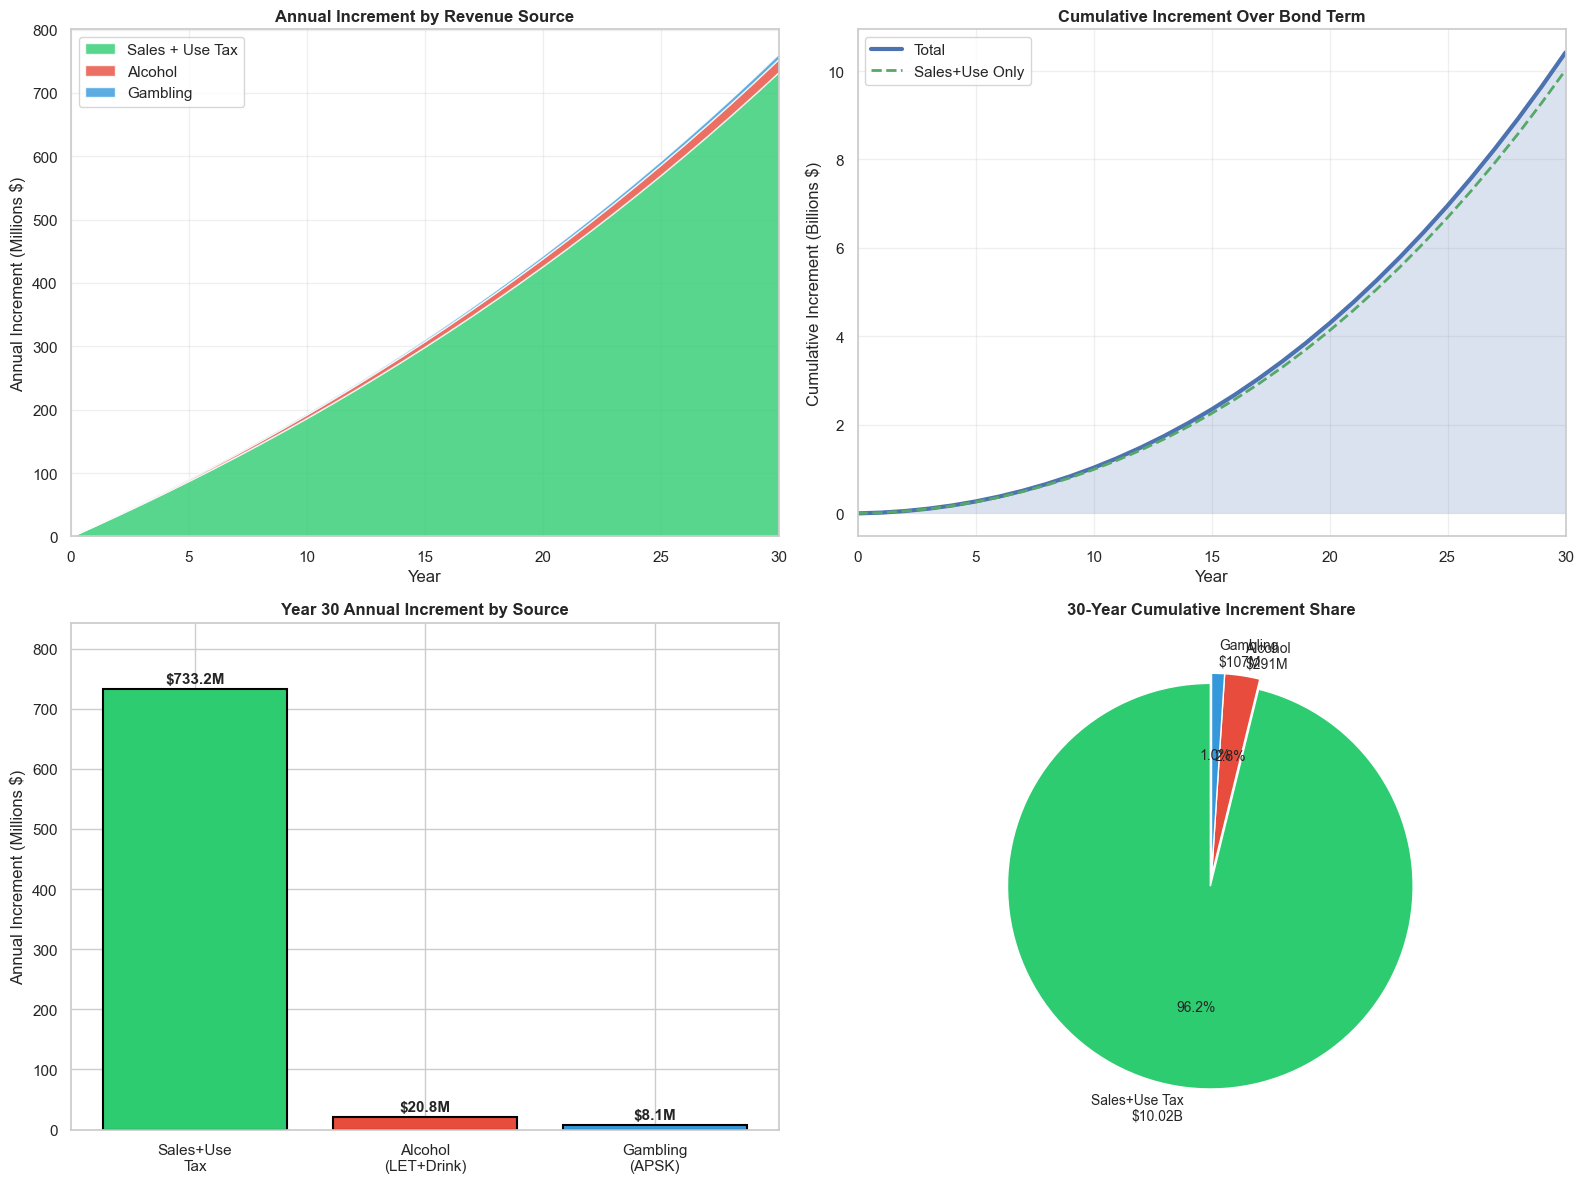


📁 Chart saved to: data/star_bond_increment_schedule.png


In [487]:
# =============================================================================
# VISUALIZATIONS
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Annual Increment by Source (Stacked Area)
ax1 = axes[0, 0]
years = schedule['Year']
ax1.stackplot(years, 
              schedule['Sales+Use_Increment'] / 1e6,
              schedule['Alcohol_Increment'] / 1e6,
              schedule['Gambling_Increment'] / 1e6,
              labels=['Sales + Use Tax', 'Alcohol', 'Gambling'],
              colors=['#2ecc71', '#e74c3c', '#3498db'],
              alpha=0.8)
ax1.set_title('Annual Increment by Revenue Source', fontsize=12, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Annual Increment (Millions $)')
ax1.legend(loc='upper left')
ax1.set_xlim(0, BOND_TERM_YEARS)
ax1.grid(True, alpha=0.3)

# 2. Cumulative Increment Over Time
ax2 = axes[0, 1]
ax2.plot(years, schedule['Total_Cumulative'] / 1e9, 'b-', linewidth=3, label='Total')
ax2.plot(years, schedule['Sales+Use_Cumulative'] / 1e9, 'g--', linewidth=2, label='Sales+Use Only')
ax2.fill_between(years, 0, schedule['Total_Cumulative'] / 1e9, alpha=0.2)
ax2.set_title('Cumulative Increment Over Bond Term', fontsize=12, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Cumulative Increment (Billions $)')
ax2.legend(loc='upper left')
ax2.set_xlim(0, BOND_TERM_YEARS)
ax2.grid(True, alpha=0.3)

# 3. Revenue Source Comparison (Final Year)
ax3 = axes[1, 0]
final = schedule.iloc[-1]
sources = ['Sales+Use\nTax', 'Alcohol\n(LET+Drink)', 'Gambling\n(APSK)']
values = [final['Sales+Use_Increment']/1e6, final['Alcohol_Increment']/1e6, final['Gambling_Increment']/1e6]
colors = ['#2ecc71', '#e74c3c', '#3498db']
bars = ax3.bar(sources, values, color=colors, edgecolor='black', linewidth=1.5)
ax3.set_title(f'Year {BOND_TERM_YEARS} Annual Increment by Source', fontsize=12, fontweight='bold')
ax3.set_ylabel('Annual Increment (Millions $)')
for bar, val in zip(bars, values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'${val:.1f}M', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax3.set_ylim(0, max(values) * 1.15)

# 4. Revenue Share Pie Chart (Cumulative)
ax4 = axes[1, 1]
cumulative_values = [final['Sales+Use_Cumulative'], final['Alcohol_Cumulative'], final['Gambling_Cumulative']]
labels_pct = [f'Sales+Use Tax\n${v/1e9:.2f}B' for v in [cumulative_values[0]]] + \
             [f'Alcohol\n${v/1e6:.0f}M' for v in [cumulative_values[1]]] + \
             [f'Gambling\n${v/1e6:.0f}M' for v in [cumulative_values[2]]]
explode = (0.05, 0, 0)
ax4.pie(cumulative_values, labels=labels_pct, colors=colors, explode=explode,
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10})
ax4.set_title(f'{BOND_TERM_YEARS}-Year Cumulative Increment Share', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('data/star_bond_increment_schedule.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📁 Chart saved to: data/star_bond_increment_schedule.png")

### Scenario Comparison

Compare different CPI growth rate scenarios to see how they impact total increment.

In [488]:
# =============================================================================
# SCENARIO COMPARISON - Multiple CPI Rates
# =============================================================================

# Define scenarios to compare
scenarios = {
    'Conservative (2%)': {'cpi_sales_use': 0.02, 'cpi_alcohol': 0.015, 'cpi_gambling': 0.02},
    'Moderate (2.5%)': {'cpi_sales_use': 0.025, 'cpi_alcohol': 0.02, 'cpi_gambling': 0.025},
    'Baseline (3%)': {'cpi_sales_use': 0.03, 'cpi_alcohol': 0.025, 'cpi_gambling': 0.03},
    'Optimistic (3.5%)': {'cpi_sales_use': 0.035, 'cpi_alcohol': 0.03, 'cpi_gambling': 0.035},
}

scenario_results = {}

print("=" * 90)
print("SCENARIO COMPARISON - 30-Year Cumulative Increment by CPI Assumption")
print("=" * 90)
print(f"\n{'Scenario':<22} {'Sales+Use':>15} {'Alcohol':>12} {'Gambling':>12} {'TOTAL':>15}")
print("-" * 76)

for name, params in scenarios.items():
    sched = generate_increment_schedule(
        years=BOND_TERM_YEARS,
        base_sales_use=BASE_SALES_USE_TOTAL,
        base_alcohol=BASE_ALCOHOL_TOTAL,
        base_gambling=BASE_GAMBLING,
        **params
    )
    final = sched.iloc[-1]
    scenario_results[name] = {
        'schedule': sched,
        'total': final['Total_Cumulative'],
        'sales_use': final['Sales+Use_Cumulative'],
        'alcohol': final['Alcohol_Cumulative'],
        'gambling': final['Gambling_Cumulative']
    }
    
    print(f"{name:<22} ${final['Sales+Use_Cumulative']/1e9:>12.2f}B "
          f"${final['Alcohol_Cumulative']/1e6:>9.0f}M "
          f"${final['Gambling_Cumulative']/1e6:>9.0f}M "
          f"${final['Total_Cumulative']/1e9:>12.2f}B")

print("-" * 76)

# Range summary
totals = [r['total'] for r in scenario_results.values()]
print(f"\n📊 RANGE: ${min(totals)/1e9:.2f}B to ${max(totals)/1e9:.2f}B")
print(f"   Spread: ${(max(totals)-min(totals))/1e9:.2f}B depending on CPI assumption")

SCENARIO COMPARISON - 30-Year Cumulative Increment by CPI Assumption

Scenario                     Sales+Use      Alcohol     Gambling           TOTAL
----------------------------------------------------------------------------
Conservative (2%)      $        7.60B $      207M $       64M $        7.87B
Moderate (2.5%)        $       10.02B $      291M $       85M $       10.40B
Baseline (3%)          $       12.69B $      384M $      107M $       13.19B
Optimistic (3.5%)      $       15.65B $      486M $      132M $       16.27B
----------------------------------------------------------------------------

📊 RANGE: $7.87B to $16.27B
   Spread: $8.40B depending on CPI assumption


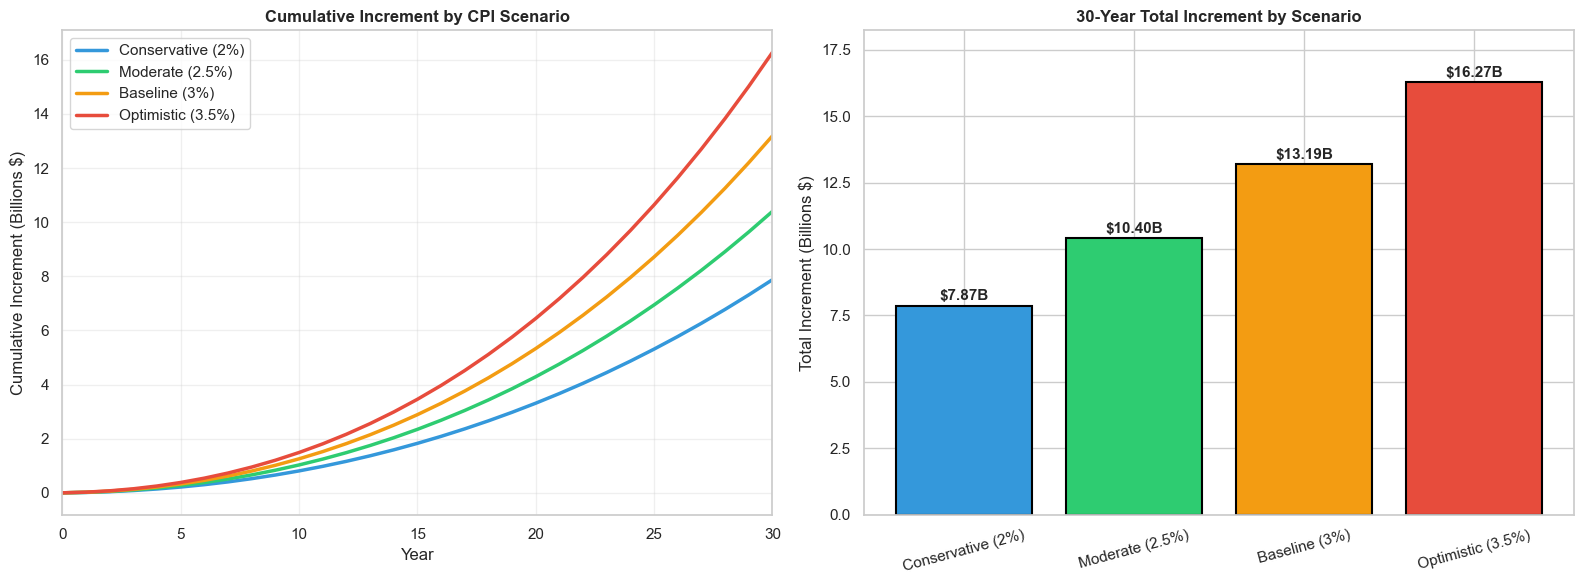

In [489]:
# Scenario comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Cumulative growth by scenario
ax1 = axes[0]
colors_scenario = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
for (name, result), color in zip(scenario_results.items(), colors_scenario):
    sched = result['schedule']
    ax1.plot(sched['Year'], sched['Total_Cumulative'] / 1e9, 
             linewidth=2.5, label=name, color=color)

ax1.set_title('Cumulative Increment by CPI Scenario', fontsize=12, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Cumulative Increment (Billions $)')
ax1.legend(loc='upper left')
ax1.set_xlim(0, BOND_TERM_YEARS)
ax1.grid(True, alpha=0.3)

# 2. Total comparison bar chart
ax2 = axes[1]
scenario_names = list(scenario_results.keys())
totals_billions = [r['total']/1e9 for r in scenario_results.values()]
bars = ax2.bar(scenario_names, totals_billions, color=colors_scenario, edgecolor='black', linewidth=1.5)
ax2.set_title(f'{BOND_TERM_YEARS}-Year Total Increment by Scenario', fontsize=12, fontweight='bold')
ax2.set_ylabel('Total Increment (Billions $)')
ax2.tick_params(axis='x', rotation=15)

for bar, val in zip(bars, totals_billions):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'${val:.2f}B', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.set_ylim(0, max(totals_billions) * 1.12)

plt.tight_layout()
plt.show()

---

## Bond Debt Service Analysis

Model the bond structure with capitalized interest and coverage ratio requirements.

See `BOND_ASSUMPTIONS.md` for detailed methodology and assumptions.

In [490]:
# =============================================================================
# BOND STRUCTURE PARAMETERS - Modify these values to model different scenarios
# =============================================================================

# Project Financing Structure
TOTAL_PROJECT_COST = 4_000_000_000    # $4.0 billion total project cost
PUBLIC_SHARE_PCT = 0.60               # 60% state/public share via STAR bonds
PRIVATE_SHARE_PCT = 1 - PUBLIC_SHARE_PCT  # 40% private/team contribution

# Derived: Bond Principal
BOND_PRINCIPAL = TOTAL_PROJECT_COST * PUBLIC_SHARE_PCT  # $2.4 billion

# Bond Terms
BOND_RATE = 0.05                      # 5.0% annual interest rate
BOND_TERM_YEARS = 30                  # 30-year bond term
CONSTRUCTION_YEARS = 4                # Years of capitalized interest (no payments)

# Coverage Requirement
COVERAGE_RATIO = 1.30                 # 1.30x coverage ratio required

# Derived: Repayment Period
REPAYMENT_YEARS = BOND_TERM_YEARS - CONSTRUCTION_YEARS

print("=" * 70)
print("BOND STRUCTURE MODEL - PARAMETER SUMMARY")
print("=" * 70)
print(f"\n🏗️  PROJECT STRUCTURE")
print(f"   Total Project Cost:    ${TOTAL_PROJECT_COST/1e9:.2f} billion")
print(f"   Public Share:          {PUBLIC_SHARE_PCT:.0%} (${BOND_PRINCIPAL/1e9:.2f}B)")
print(f"   Private Share:         {PRIVATE_SHARE_PCT:.0%} (${TOTAL_PROJECT_COST * PRIVATE_SHARE_PCT/1e9:.2f}B)")
print(f"\n📊 BOND TERMS")
print(f"   Bond Principal:        ${BOND_PRINCIPAL/1e9:.2f} billion")
print(f"   Interest Rate:         {BOND_RATE:.2%}")
print(f"   Total Term:            {BOND_TERM_YEARS} years")
print(f"   Construction Period:   {CONSTRUCTION_YEARS} years (interest capitalizes)")
print(f"   Repayment Period:      {REPAYMENT_YEARS} years")
print(f"\n🛡️  COVERAGE REQUIREMENT")
print(f"   Coverage Ratio:        {COVERAGE_RATIO:.2f}x")
print("=" * 70)

BOND STRUCTURE MODEL - PARAMETER SUMMARY

🏗️  PROJECT STRUCTURE
   Total Project Cost:    $4.00 billion
   Public Share:          60% ($2.40B)
   Private Share:         40% ($1.60B)

📊 BOND TERMS
   Bond Principal:        $2.40 billion
   Interest Rate:         5.00%
   Total Term:            30 years
   Construction Period:   4 years (interest capitalizes)
   Repayment Period:      26 years

🛡️  COVERAGE REQUIREMENT
   Coverage Ratio:        1.30x


In [491]:
# =============================================================================
# BOND CALCULATIONS - Capitalized Interest & Debt Service
# =============================================================================

def calculate_bond_structure(
    principal: float,
    rate: float,
    total_term: int,
    construction_years: int,
    coverage_ratio: float
) -> dict:
    """
    Calculate bond structure with capitalized interest.
    
    Returns dict with all key bond metrics.
    """
    # Capitalized Interest: simple interest during construction
    # (In practice, may compound annually - this is conservative)
    capitalized_interest = principal * rate * construction_years
    
    # Total debt after capitalization
    total_debt = principal + capitalized_interest
    
    # Repayment period
    repayment_years = total_term - construction_years
    
    # Annual debt service (level payment amortization)
    # PMT = P * [r(1+r)^n] / [(1+r)^n - 1]
    r = rate
    n = repayment_years
    if r > 0:
        pmt_factor = (r * (1 + r)**n) / ((1 + r)**n - 1)
    else:
        pmt_factor = 1 / n  # Simple division if 0% rate
    
    annual_debt_service = total_debt * pmt_factor
    
    # Total payments over life of bond
    total_payments = annual_debt_service * repayment_years
    
    # Total interest paid (including capitalized)
    total_interest = total_payments - principal
    
    # Required revenue for coverage
    required_annual_revenue = annual_debt_service * coverage_ratio
    
    return {
        'principal': principal,
        'rate': rate,
        'total_term': total_term,
        'construction_years': construction_years,
        'repayment_years': repayment_years,
        'capitalized_interest': capitalized_interest,
        'total_debt': total_debt,
        'annual_debt_service': annual_debt_service,
        'total_payments': total_payments,
        'total_interest': total_interest,
        'coverage_ratio': coverage_ratio,
        'required_annual_revenue': required_annual_revenue
    }

# Calculate with current parameters
bond = calculate_bond_structure(
    principal=BOND_PRINCIPAL,
    rate=BOND_RATE,
    total_term=BOND_TERM_YEARS,
    construction_years=CONSTRUCTION_YEARS,
    coverage_ratio=COVERAGE_RATIO
)

print("=" * 70)
print("BOND STRUCTURE RESULTS")
print("=" * 70)
print(f"\n💵 CAPITALIZED INTEREST")
print(f"   Interest during construction:  ${bond['capitalized_interest']/1e6:,.0f} million")
print(f"   Original Principal:            ${bond['principal']/1e9:.2f} billion")
print(f"   Total Debt (after cap.):       ${bond['total_debt']/1e9:.2f} billion")
print(f"\n📅 DEBT SERVICE")
print(f"   Repayment Period:              {bond['repayment_years']} years")
print(f"   Annual Debt Service:           ${bond['annual_debt_service']/1e6:,.1f} million")
print(f"   Total Payments (life of bond): ${bond['total_payments']/1e9:.2f} billion")
print(f"   Total Interest Paid:           ${bond['total_interest']/1e9:.2f} billion")
print(f"\n🛡️  COVERAGE REQUIREMENT ({bond['coverage_ratio']:.2f}x)")
print(f"   Required Annual Revenue:       ${bond['required_annual_revenue']/1e6:,.1f} million")
print("=" * 70)

BOND STRUCTURE RESULTS

💵 CAPITALIZED INTEREST
   Interest during construction:  $480 million
   Original Principal:            $2.40 billion
   Total Debt (after cap.):       $2.88 billion

📅 DEBT SERVICE
   Repayment Period:              26 years
   Annual Debt Service:           $200.3 million
   Total Payments (life of bond): $5.21 billion
   Total Interest Paid:           $2.81 billion

🛡️  COVERAGE REQUIREMENT (1.30x)
   Required Annual Revenue:       $260.4 million


In [492]:
# =============================================================================
# MAP INCREMENT REVENUE TO DEBT SERVICE REQUIREMENTS
# =============================================================================

# Create a combined schedule showing increment vs required debt service
def create_coverage_analysis(
    increment_schedule: pd.DataFrame,
    bond_structure: dict,
    construction_years: int
) -> pd.DataFrame:
    """
    Combine increment projections with debt service requirements.
    Shows coverage ratio achieved in each year.
    """
    records = []
    annual_service = bond_structure['annual_debt_service']
    required_revenue = bond_structure['required_annual_revenue']
    
    for _, row in increment_schedule.iterrows():
        year = int(row['Year'])
        
        # During construction, no debt service required (interest capitalizes)
        if year <= construction_years:
            debt_service = 0
            required = 0
            phase = "Construction"
        else:
            debt_service = annual_service
            required = required_revenue
            phase = "Repayment"
        
        total_increment = row['Total_Increment']
        
        # Calculate actual coverage ratio
        if debt_service > 0:
            actual_coverage = total_increment / debt_service
            meets_coverage = total_increment >= required
        else:
            actual_coverage = np.inf
            meets_coverage = True
        
        # Calculate surplus/shortfall
        surplus_shortfall = total_increment - required
        
        records.append({
            'Year': year,
            'Phase': phase,
            'Total_Increment': total_increment,
            'Debt_Service': debt_service,
            'Required_Revenue': required,
            'Actual_Coverage': actual_coverage,
            'Meets_Coverage': meets_coverage,
            'Surplus_Shortfall': surplus_shortfall
        })
    
    return pd.DataFrame(records)

# Generate coverage analysis
coverage_analysis = create_coverage_analysis(schedule, bond, CONSTRUCTION_YEARS)

# Display key years
print("=" * 90)
print("REVENUE vs DEBT SERVICE COVERAGE ANALYSIS")
print("=" * 90)
print(f"\nRequired Annual Debt Service: ${bond['annual_debt_service']/1e6:,.1f}M")
print(f"Required Revenue ({COVERAGE_RATIO:.2f}x coverage): ${bond['required_annual_revenue']/1e6:,.1f}M")
print()

# Show key years
key_years = [0, 1, 2, 3, 4, 5, 10, 15, 20, 25, 30]
key_years = [y for y in key_years if y <= BOND_TERM_YEARS]

print(f"{'Year':<6} {'Phase':<14} {'Increment':>14} {'Debt Svc':>12} {'Required':>12} {'Coverage':>10} {'Status':>12}")
print("-" * 82)

for year in key_years:
    row = coverage_analysis[coverage_analysis['Year'] == year].iloc[0]
    
    if row['Phase'] == 'Construction':
        coverage_str = "N/A"
        status = "Capitalizing"
    else:
        coverage_str = f"{row['Actual_Coverage']:.2f}x"
        status = "✓ Met" if row['Meets_Coverage'] else "✗ Short"
    
    print(f"{row['Year']:<6} {row['Phase']:<14} ${row['Total_Increment']/1e6:>11,.1f}M "
          f"${row['Debt_Service']/1e6:>9,.1f}M ${row['Required_Revenue']/1e6:>9,.1f}M "
          f"{coverage_str:>10} {status:>12}")

REVENUE vs DEBT SERVICE COVERAGE ANALYSIS

Required Annual Debt Service: $200.3M
Required Revenue (1.30x coverage): $260.4M

Year   Phase               Increment     Debt Svc     Required   Coverage       Status
----------------------------------------------------------------------------------
0      Construction   $        0.0M $      0.0M $      0.0M        N/A Capitalizing
1      Construction   $       17.4M $      0.0M $      0.0M        N/A Capitalizing
2      Construction   $       35.2M $      0.0M $      0.0M        N/A Capitalizing
3      Construction   $       53.5M $      0.0M $      0.0M        N/A Capitalizing
4      Construction   $       72.2M $      0.0M $      0.0M        N/A Capitalizing
5      Repayment      $       91.3M $    200.3M $    260.4M      0.46x      ✗ Short
10     Repayment      $      194.6M $    200.3M $    260.4M      0.97x      ✗ Short
15     Repayment      $      311.5M $    200.3M $    260.4M      1.55x        ✓ Met
20     Repayment      $      443.

In [493]:
# =============================================================================
# COVERAGE GAP ANALYSIS
# =============================================================================

# Find first year coverage is met
repayment_years = coverage_analysis[coverage_analysis['Phase'] == 'Repayment']
first_coverage_met = repayment_years[repayment_years['Meets_Coverage']]['Year'].min()
if pd.isna(first_coverage_met):
    first_coverage_met = "Never (within term)"

# Calculate cumulative shortfall in early years
shortfall_years = repayment_years[~repayment_years['Meets_Coverage']]
total_shortfall = shortfall_years['Surplus_Shortfall'].sum()

# Calculate lifetime surplus
total_surplus_shortfall = repayment_years['Surplus_Shortfall'].sum()

# Years in shortfall
years_in_shortfall = len(shortfall_years)

print("=" * 70)
print("COVERAGE GAP ANALYSIS")
print("=" * 70)
print(f"\n📅 COVERAGE TIMELINE")
print(f"   First year coverage met:       Year {first_coverage_met}")
print(f"   Years in shortfall:            {years_in_shortfall} years")
print(f"\n💸 SHORTFALL ANALYSIS")
print(f"   Cumulative early-year gap:     ${abs(total_shortfall)/1e6:,.1f} million")
print(f"   (Revenue needed to bridge gap until coverage is achieved)")
print(f"\n📈 LIFETIME BALANCE")
print(f"   Net surplus over bond term:    ${total_surplus_shortfall/1e9:,.2f} billion")
if total_surplus_shortfall > 0:
    print(f"   ✓ Sufficient lifetime revenue to cover debt service + coverage ratio")
else:
    print(f"   ✗ WARNING: Lifetime revenue insufficient for debt service")

# What rate scenarios would help?
print(f"\n💡 SENSITIVITY NOTE:")
print(f"   Higher CPI = faster increment growth = earlier coverage")
print(f"   Lower bond rate = lower debt service = easier coverage")
print(f"   Longer construction period = more capitalized interest = higher debt")
print("=" * 70)

COVERAGE GAP ANALYSIS

📅 COVERAGE TIMELINE
   First year coverage met:       Year 13
   Years in shortfall:            8 years

💸 SHORTFALL ANALYSIS
   Cumulative early-year gap:     $774.2 million
   (Revenue needed to bridge gap until coverage is achieved)

📈 LIFETIME BALANCE
   Net surplus over bond term:    $3.47 billion
   ✓ Sufficient lifetime revenue to cover debt service + coverage ratio

💡 SENSITIVITY NOTE:
   Higher CPI = faster increment growth = earlier coverage
   Lower bond rate = lower debt service = easier coverage
   Longer construction period = more capitalized interest = higher debt


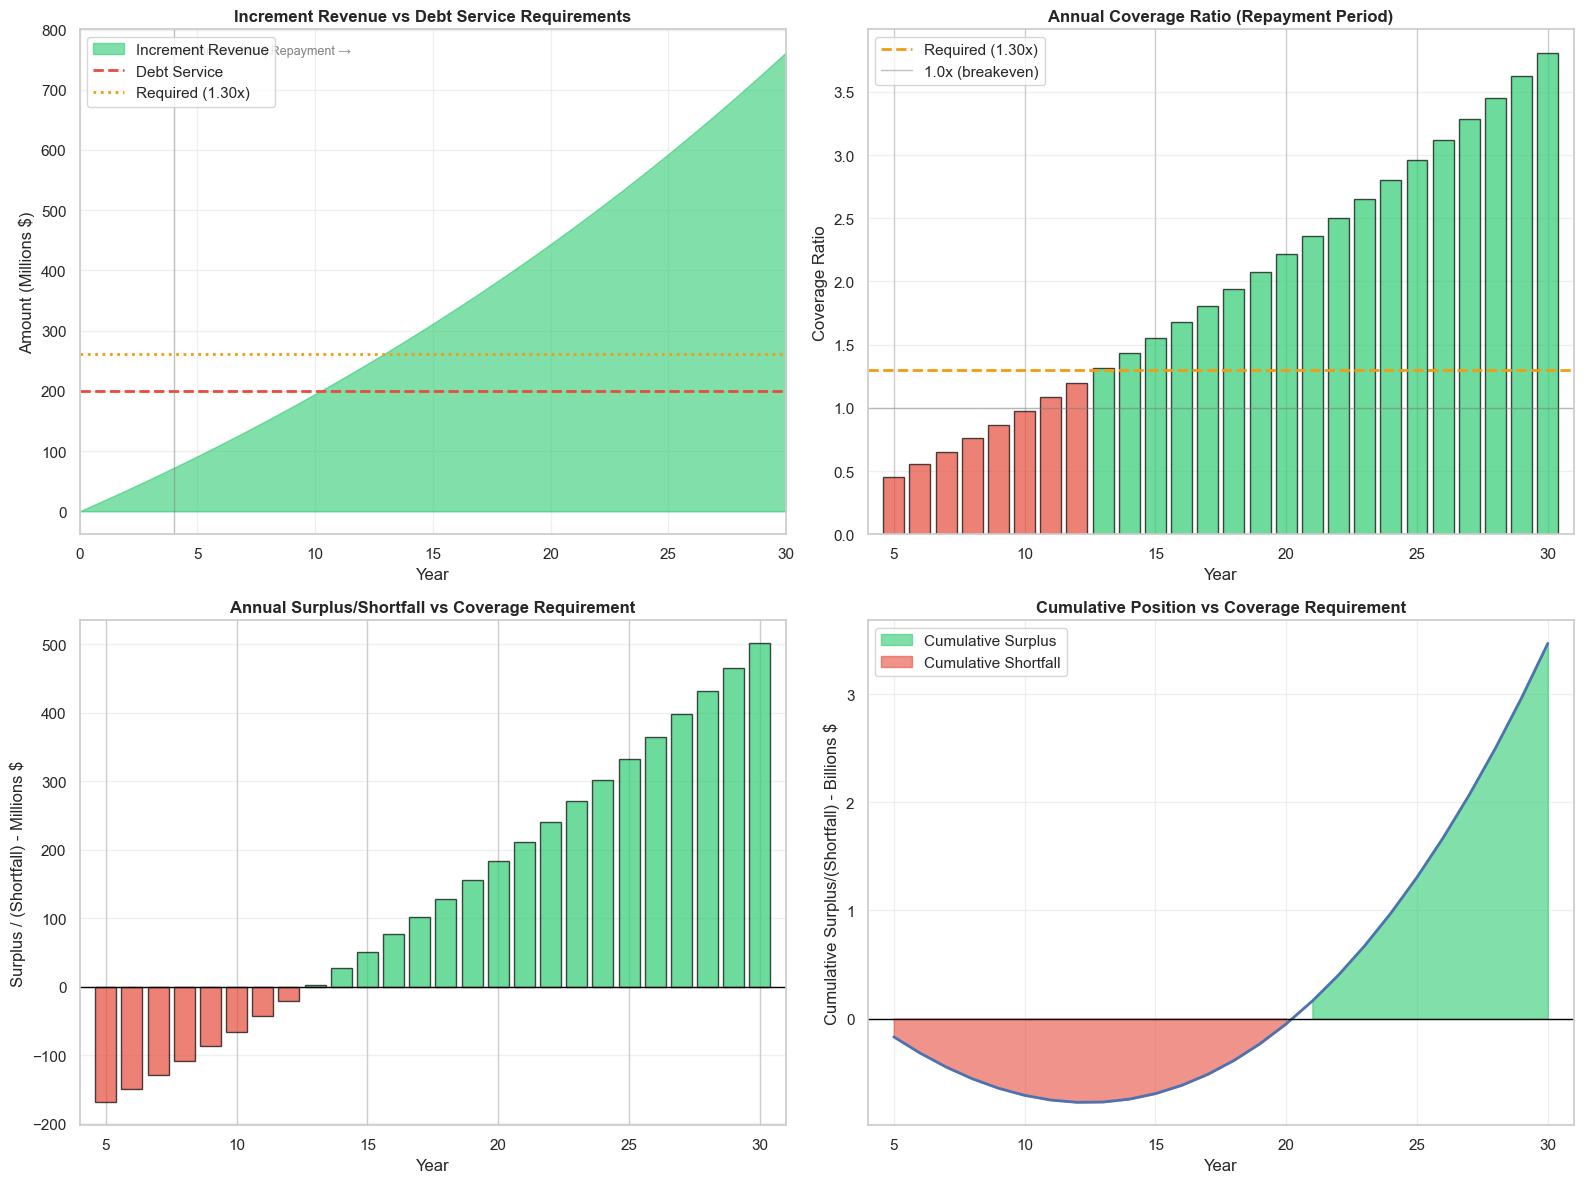


📁 Chart saved to: data/bond_coverage_analysis.png


In [494]:
# =============================================================================
# COVERAGE VISUALIZATION
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Revenue vs Debt Service Over Time
ax1 = axes[0, 0]
years = coverage_analysis['Year']
ax1.fill_between(years, 0, coverage_analysis['Total_Increment'] / 1e6, 
                  alpha=0.6, label='Increment Revenue', color='#2ecc71')
ax1.axhline(y=bond['annual_debt_service'] / 1e6, color='#e74c3c', 
            linewidth=2, linestyle='--', label='Debt Service')
ax1.axhline(y=bond['required_annual_revenue'] / 1e6, color='#f39c12', 
            linewidth=2, linestyle=':', label=f'Required ({COVERAGE_RATIO:.2f}x)')
ax1.axvline(x=CONSTRUCTION_YEARS, color='gray', linewidth=1, linestyle='-', alpha=0.5)
ax1.annotate('← Construction | Repayment →', xy=(CONSTRUCTION_YEARS, ax1.get_ylim()[1]*0.95), 
             fontsize=9, color='gray')
ax1.set_title('Increment Revenue vs Debt Service Requirements', fontsize=12, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Amount (Millions $)')
ax1.legend(loc='upper left')
ax1.set_xlim(0, BOND_TERM_YEARS)
ax1.grid(True, alpha=0.3)

# 2. Coverage Ratio Over Time
ax2 = axes[0, 1]
repay = coverage_analysis[coverage_analysis['Phase'] == 'Repayment'].copy()
colors = ['#2ecc71' if x >= COVERAGE_RATIO else '#e74c3c' for x in repay['Actual_Coverage']]
ax2.bar(repay['Year'], repay['Actual_Coverage'], color=colors, alpha=0.7, edgecolor='black')
ax2.axhline(y=COVERAGE_RATIO, color='#f39c12', linewidth=2, linestyle='--', 
            label=f'Required ({COVERAGE_RATIO:.2f}x)')
ax2.axhline(y=1.0, color='gray', linewidth=1, linestyle='-', alpha=0.5, label='1.0x (breakeven)')
ax2.set_title('Annual Coverage Ratio (Repayment Period)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Coverage Ratio')
ax2.legend(loc='upper left')
ax2.set_xlim(CONSTRUCTION_YEARS, BOND_TERM_YEARS + 1)
ax2.grid(True, alpha=0.3, axis='y')

# 3. Annual Surplus/Shortfall
ax3 = axes[1, 0]
surplus = coverage_analysis[coverage_analysis['Phase'] == 'Repayment']['Surplus_Shortfall'] / 1e6
years_repay = coverage_analysis[coverage_analysis['Phase'] == 'Repayment']['Year']
colors = ['#2ecc71' if x >= 0 else '#e74c3c' for x in surplus]
ax3.bar(years_repay, surplus, color=colors, alpha=0.7, edgecolor='black')
ax3.axhline(y=0, color='black', linewidth=1)
ax3.set_title('Annual Surplus/Shortfall vs Coverage Requirement', fontsize=12, fontweight='bold')
ax3.set_xlabel('Year')
ax3.set_ylabel('Surplus / (Shortfall) - Millions $')
ax3.set_xlim(CONSTRUCTION_YEARS, BOND_TERM_YEARS + 1)
ax3.grid(True, alpha=0.3, axis='y')

# 4. Cumulative Position
ax4 = axes[1, 1]
cumulative_position = coverage_analysis[coverage_analysis['Phase'] == 'Repayment']['Surplus_Shortfall'].cumsum() / 1e9
ax4.fill_between(years_repay, 0, cumulative_position, 
                  where=(cumulative_position >= 0), alpha=0.6, color='#2ecc71', label='Cumulative Surplus')
ax4.fill_between(years_repay, 0, cumulative_position, 
                  where=(cumulative_position < 0), alpha=0.6, color='#e74c3c', label='Cumulative Shortfall')
ax4.plot(years_repay, cumulative_position, 'b-', linewidth=2)
ax4.axhline(y=0, color='black', linewidth=1)
ax4.set_title('Cumulative Position vs Coverage Requirement', fontsize=12, fontweight='bold')
ax4.set_xlabel('Year')
ax4.set_ylabel('Cumulative Surplus/(Shortfall) - Billions $')
ax4.legend(loc='upper left')
ax4.set_xlim(CONSTRUCTION_YEARS, BOND_TERM_YEARS + 1)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/bond_coverage_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📁 Chart saved to: data/bond_coverage_analysis.png")

### Bond Rate Sensitivity Analysis

Compare how different interest rates affect debt service and coverage requirements.

In [495]:
# =============================================================================
# BOND RATE SENSITIVITY ANALYSIS
# =============================================================================

# Test different bond rates
bond_rates = [0.040, 0.045, 0.050, 0.055, 0.060, 0.065]

print("=" * 95)
print("BOND RATE SENSITIVITY ANALYSIS")
print("=" * 95)
print(f"\nBase assumptions: ${BOND_PRINCIPAL/1e9:.1f}B principal, {CONSTRUCTION_YEARS}-year construction, "
      f"{REPAYMENT_YEARS}-year repayment, {COVERAGE_RATIO:.2f}x coverage")
print()

print(f"{'Rate':>8} {'Cap. Int.':>12} {'Total Debt':>14} {'Annual Svc':>14} {'Req. Revenue':>14} {'Total Paid':>14}")
print("-" * 78)

rate_results = []
for rate in bond_rates:
    b = calculate_bond_structure(
        principal=BOND_PRINCIPAL,
        rate=rate,
        total_term=BOND_TERM_YEARS,
        construction_years=CONSTRUCTION_YEARS,
        coverage_ratio=COVERAGE_RATIO
    )
    rate_results.append(b)
    
    marker = " ◄" if rate == BOND_RATE else ""
    print(f"{rate:>7.1%} ${b['capitalized_interest']/1e6:>9,.0f}M "
          f"${b['total_debt']/1e9:>11.2f}B "
          f"${b['annual_debt_service']/1e6:>11.1f}M "
          f"${b['required_annual_revenue']/1e6:>11.1f}M "
          f"${b['total_payments']/1e9:>11.2f}B{marker}")

print("-" * 78)
print(f"\n{'◄ = Current assumption'}")

# Impact summary
low_rate = rate_results[0]
high_rate = rate_results[-1]
service_diff = high_rate['annual_debt_service'] - low_rate['annual_debt_service']
print(f"\n📊 RATE IMPACT: {bond_rates[0]:.1%} → {bond_rates[-1]:.1%}")
print(f"   Annual debt service increase: ${service_diff/1e6:,.1f}M (+{service_diff/low_rate['annual_debt_service']*100:.0f}%)")
print(f"   Each 50bp rate increase adds ~${(service_diff/5)/1e6:.1f}M to annual debt service")

BOND RATE SENSITIVITY ANALYSIS

Base assumptions: $2.4B principal, 4-year construction, 26-year repayment, 1.30x coverage

    Rate    Cap. Int.     Total Debt     Annual Svc   Req. Revenue     Total Paid
------------------------------------------------------------------------------
   4.0% $      384M $       2.78B $      174.2M $      226.4M $       4.53B
   4.5% $      432M $       2.83B $      187.0M $      243.1M $       4.86B
   5.0% $      480M $       2.88B $      200.3M $      260.4M $       5.21B ◄
   5.5% $      528M $       2.93B $      214.3M $      278.6M $       5.57B
   6.0% $      576M $       2.98B $      228.9M $      297.5M $       5.95B
   6.5% $      624M $       3.02B $      244.0M $      317.2M $       6.34B
------------------------------------------------------------------------------

◄ = Current assumption

📊 RATE IMPACT: 4.0% → 6.5%
   Annual debt service increase: $69.8M (+40%)
   Each 50bp rate increase adds ~$14.0M to annual debt service


### The Compounding Cascade: Why Coverage Requirements Multiply

The interaction between capitalized interest, amortization, and coverage ratios creates a **compounding cascade** where each layer multiplies the previous. This is analogous to a Taylor series expansion where higher-order terms (interest on interest) accumulate.

**Layer 1 — Capitalized Interest**: During construction, interest accrues and is added to principal. You start paying interest on interest before repayment even begins.

**Layer 2 — Amortization**: The inflated principal is then amortized over the repayment period. The amortization formula `PMT = P × [r(1+r)^n] / [(1+r)^n - 1]` applies the interest rate to the *already-inflated* debt.

**Layer 3 — Coverage Ratio**: Bond covenants require revenues to exceed debt service by a safety margin (1.3×). This multiplies everything by an additional 30%.

The result: **to borrow $2.4B, you need ~$6.8B in total increment revenue.**

In [496]:
# =============================================================================
# THE COMPOUNDING CASCADE - LAYER BY LAYER BREAKDOWN
# =============================================================================

def analyze_compounding_cascade(
    principal: float,
    rate: float,
    construction_years: int,
    repayment_years: int,
    coverage_ratio: float,
    use_compound_capitalization: bool = False
) -> dict:
    """
    Break down the compounding cascade layer by layer.
    
    Shows how each layer multiplies the previous to arrive at total required revenue.
    """
    # Layer 0: Original Principal
    layer_0 = principal
    
    # Layer 1: Capitalized Interest
    if use_compound_capitalization:
        # Compound interest during construction: P(1+r)^c
        layer_1_total = principal * ((1 + rate) ** construction_years)
        cap_interest = layer_1_total - principal
    else:
        # Simple interest: P(1 + r*c)
        cap_interest = principal * rate * construction_years
        layer_1_total = principal + cap_interest
    
    layer_1_multiplier = layer_1_total / principal
    
    # Layer 2: Amortization
    # PMT = D × [r(1+r)^n] / [(1+r)^n - 1]
    r, n = rate, repayment_years
    pmt_factor = (r * (1 + r)**n) / ((1 + r)**n - 1)
    annual_pmt = layer_1_total * pmt_factor
    total_payments = annual_pmt * repayment_years
    
    layer_2_multiplier = total_payments / principal
    
    # Layer 3: Coverage Ratio
    required_annual = annual_pmt * coverage_ratio
    total_required = required_annual * repayment_years
    
    layer_3_multiplier = total_required / principal
    
    # Taylor expansion of (1+r)^n for illustration
    taylor_terms = []
    for k in range(6):
        # Binomial coefficient: n choose k
        coef = 1
        for i in range(k):
            coef *= (construction_years - i) / (i + 1)
        term = coef * (rate ** k)
        taylor_terms.append(term)
    
    return {
        'principal': principal,
        'rate': rate,
        'construction_years': construction_years,
        'repayment_years': repayment_years,
        'coverage_ratio': coverage_ratio,
        # Layer values
        'layer_0': layer_0,
        'layer_1_cap_interest': cap_interest,
        'layer_1_total': layer_1_total,
        'layer_1_multiplier': layer_1_multiplier,
        'layer_2_annual_pmt': annual_pmt,
        'layer_2_total_payments': total_payments,
        'layer_2_multiplier': layer_2_multiplier,
        'layer_3_required_annual': required_annual,
        'layer_3_total_required': total_required,
        'layer_3_multiplier': layer_3_multiplier,
        # Interest components
        'total_interest': total_payments - principal,
        'interest_on_capitalized': total_payments - layer_1_total - (principal * rate * repayment_years * pmt_factor / rate),
        'taylor_terms': taylor_terms
    }

# Analyze with current parameters
cascade = analyze_compounding_cascade(
    principal=BOND_PRINCIPAL,
    rate=BOND_RATE,
    construction_years=CONSTRUCTION_YEARS,
    repayment_years=REPAYMENT_YEARS,
    coverage_ratio=COVERAGE_RATIO,
    use_compound_capitalization=False  # Conservative (simple interest)
)

print("=" * 80)
print("THE COMPOUNDING CASCADE - LAYER BY LAYER")
print("=" * 80)
print(f"\nOriginal Principal: ${cascade['principal']/1e9:.2f}B")
print(f"Interest Rate: {cascade['rate']:.1%}")
print(f"Construction: {cascade['construction_years']} years | Repayment: {cascade['repayment_years']} years")
print(f"Coverage Ratio: {cascade['coverage_ratio']:.2f}×")

print("\n" + "─" * 80)
print("LAYER-BY-LAYER BREAKDOWN")
print("─" * 80)

print(f"""
┌─────────────────────────────────────────────────────────────────────────────┐
│ LAYER 0: Original Principal                                                 │
│                                                                             │
│   Amount: ${cascade['layer_0']/1e9:.2f}B                                             │
│   Multiplier: 1.00×                                                         │
└─────────────────────────────────────────────────────────────────────────────┘
                                    ↓
                         + Capitalized Interest
                                    ↓
┌─────────────────────────────────────────────────────────────────────────────┐
│ LAYER 1: After Capitalization                                               │
│                                                                             │
│   Capitalized Interest: ${cascade['layer_1_cap_interest']/1e6:,.0f}M                               │
│   Total Debt: ${cascade['layer_1_total']/1e9:.2f}B                                           │
│   Multiplier: {cascade['layer_1_multiplier']:.2f}× original                                          │
│                                                                             │
│   Formula: P × (1 + r×c) = P × (1 + {cascade['rate']:.0%}×{cascade['construction_years']}) = P × {cascade['layer_1_multiplier']:.2f}          │
└─────────────────────────────────────────────────────────────────────────────┘
                                    ↓
                      × Amortization over {cascade['repayment_years']} years
                                    ↓
┌─────────────────────────────────────────────────────────────────────────────┐
│ LAYER 2: Total Debt Service Payments                                        │
│                                                                             │
│   Annual Payment: ${cascade['layer_2_annual_pmt']/1e6:,.1f}M                                      │
│   Total Payments: ${cascade['layer_2_total_payments']/1e9:.2f}B                                         │
│   Multiplier: {cascade['layer_2_multiplier']:.2f}× original                                          │
│                                                                             │
│   This includes interest on the capitalized interest!                       │
└─────────────────────────────────────────────────────────────────────────────┘
                                    ↓
                        × Coverage Ratio ({cascade['coverage_ratio']:.2f}×)
                                    ↓
┌─────────────────────────────────────────────────────────────────────────────┐
│ LAYER 3: Required Increment Revenue                                         │
│                                                                             │
│   Required Annual: ${cascade['layer_3_required_annual']/1e6:,.1f}M                                    │
│   Total Required: ${cascade['layer_3_total_required']/1e9:.2f}B                                        │
│   Multiplier: {cascade['layer_3_multiplier']:.2f}× original                                          │
│                                                                             │
│   To borrow ${cascade['principal']/1e9:.1f}B, you need ${cascade['layer_3_total_required']/1e9:.1f}B in increment revenue          │
└─────────────────────────────────────────────────────────────────────────────┘
""")

print("─" * 80)
print("SUMMARY: THE MULTIPLIER STACK")
print("─" * 80)
print(f"""
   ${cascade['principal']/1e9:.2f}B  ← Original Principal (1.00×)
      × {cascade['layer_1_multiplier']:.2f}  ← Capitalization Layer
      × {cascade['layer_2_multiplier']/cascade['layer_1_multiplier']:.2f}  ← Amortization Layer  
      × {cascade['coverage_ratio']:.2f}  ← Coverage Layer
   ────────
   ${cascade['layer_3_total_required']/1e9:.2f}B  ← Total Required Revenue ({cascade['layer_3_multiplier']:.2f}×)
""")

THE COMPOUNDING CASCADE - LAYER BY LAYER

Original Principal: $2.40B
Interest Rate: 5.0%
Construction: 4 years | Repayment: 26 years
Coverage Ratio: 1.30×

────────────────────────────────────────────────────────────────────────────────
LAYER-BY-LAYER BREAKDOWN
────────────────────────────────────────────────────────────────────────────────

┌─────────────────────────────────────────────────────────────────────────────┐
│ LAYER 0: Original Principal                                                 │
│                                                                             │
│   Amount: $2.40B                                             │
│   Multiplier: 1.00×                                                         │
└─────────────────────────────────────────────────────────────────────────────┘
                                    ↓
                         + Capitalized Interest
                                    ↓
┌──────────────────────────────────────────────────────────────────

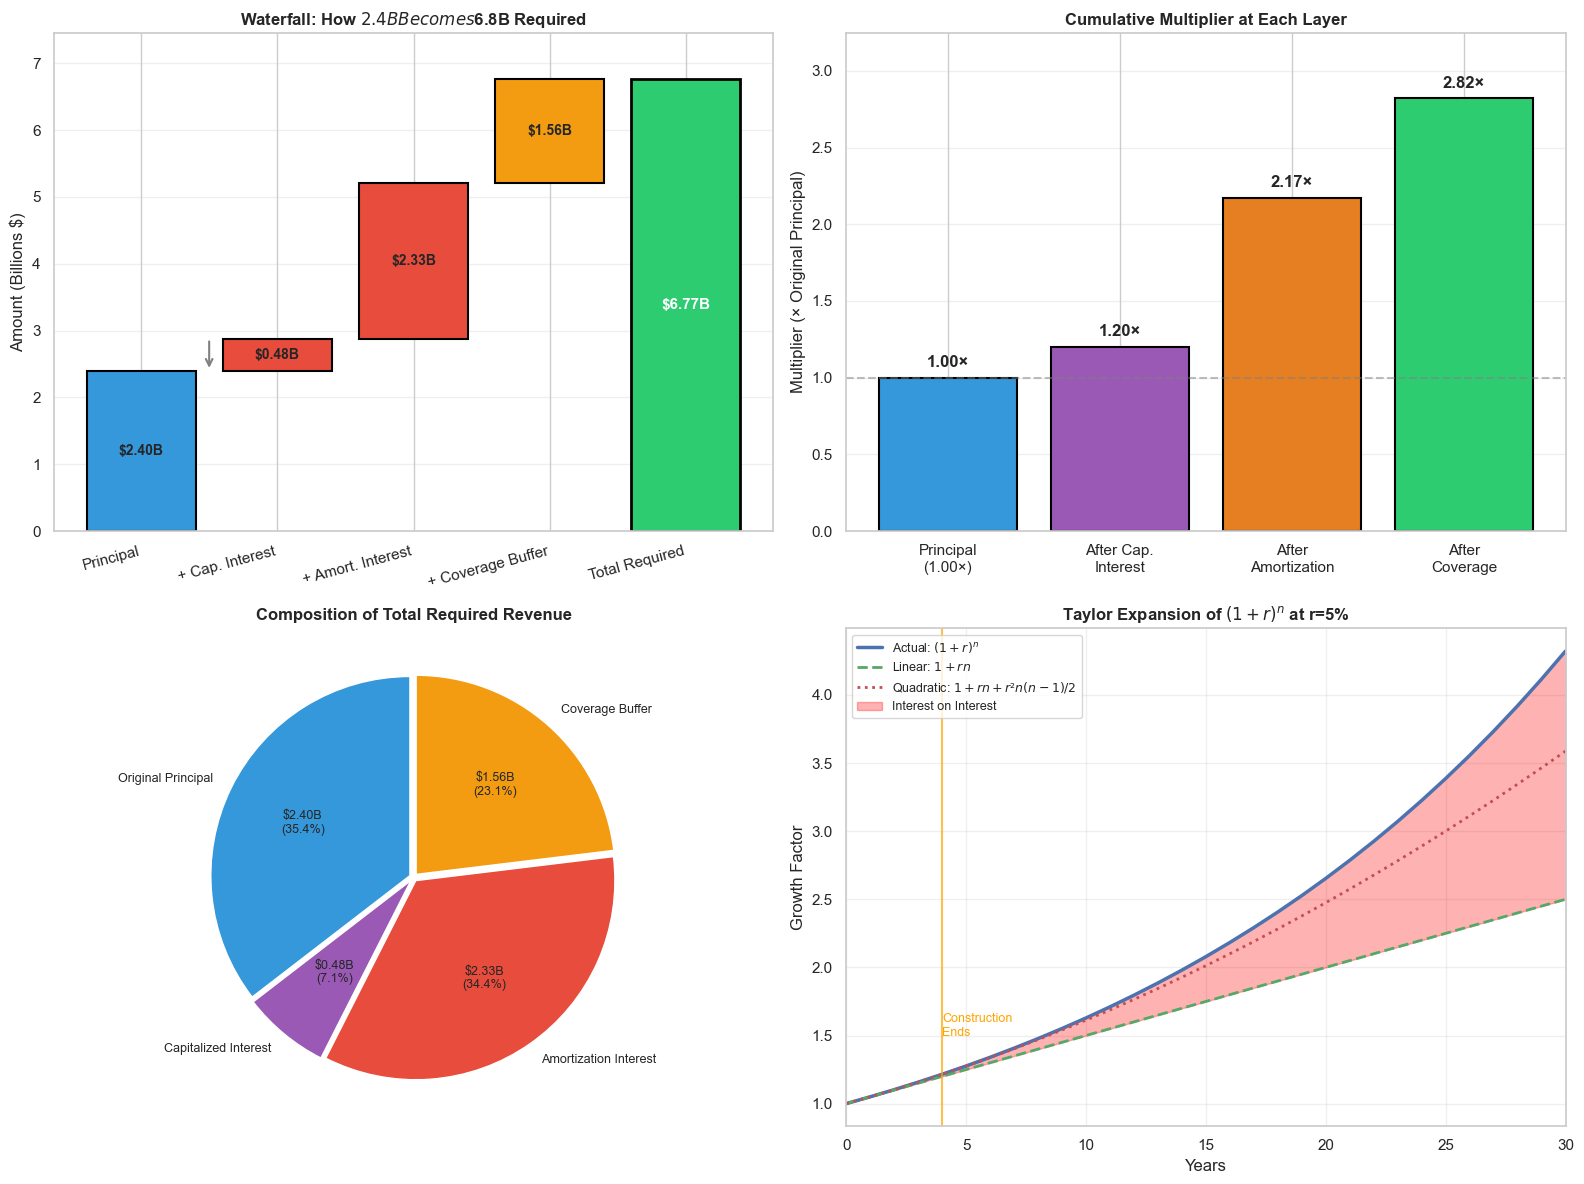


📁 Chart saved to: data/compounding_cascade.png


In [497]:
# =============================================================================
# VISUALIZE THE COMPOUNDING CASCADE
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Waterfall Chart - Layer by Layer Growth
ax1 = axes[0, 0]

# Values for waterfall
categories = ['Principal', '+ Cap. Interest', '+ Amort. Interest', '+ Coverage Buffer', 'Total Required']
values = [
    cascade['principal'] / 1e9,
    cascade['layer_1_cap_interest'] / 1e9,
    (cascade['layer_2_total_payments'] - cascade['layer_1_total']) / 1e9,
    (cascade['layer_3_total_required'] - cascade['layer_2_total_payments']) / 1e9,
    0  # Placeholder for total
]

# Calculate cumulative for waterfall
cumulative = [0]
for i, v in enumerate(values[:-1]):
    cumulative.append(cumulative[-1] + v)

# Colors
colors = ['#3498db', '#e74c3c', '#e74c3c', '#f39c12', '#2ecc71']

# Draw bars
for i, (cat, val) in enumerate(zip(categories[:-1], values[:-1])):
    if i == 0:
        ax1.bar(i, val, bottom=0, color=colors[i], edgecolor='black', linewidth=1.5)
    else:
        ax1.bar(i, val, bottom=cumulative[i], color=colors[i], edgecolor='black', linewidth=1.5)
    
    # Add value label
    mid_point = cumulative[i] + val/2 if i > 0 else val/2
    ax1.text(i, mid_point, f'${val:.2f}B', ha='center', va='center', fontsize=10, fontweight='bold')

# Total bar
total = cascade['layer_3_total_required'] / 1e9
ax1.bar(4, total, color=colors[4], edgecolor='black', linewidth=2)
ax1.text(4, total/2, f'${total:.2f}B', ha='center', va='center', fontsize=11, fontweight='bold', color='white')

ax1.set_xticks(range(5))
ax1.set_xticklabels(categories, rotation=15, ha='right')
ax1.set_ylabel('Amount (Billions $)')
ax1.set_title('Waterfall: How $2.4B Becomes $6.8B Required', fontsize=12, fontweight='bold')
ax1.set_ylim(0, total * 1.1)
ax1.grid(True, alpha=0.3, axis='y')

# Add multiplier annotations
ax1.annotate('', xy=(0.5, cascade['principal']/1e9), xytext=(0.5, cascade['layer_1_total']/1e9),
             arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

# 2. Multiplier Visualization
ax2 = axes[0, 1]

multipliers = [1.0, cascade['layer_1_multiplier'], cascade['layer_2_multiplier'], cascade['layer_3_multiplier']]
labels = ['Principal\n(1.00×)', 'After Cap.\nInterest', 'After\nAmortization', 'After\nCoverage']
colors_mult = ['#3498db', '#9b59b6', '#e67e22', '#2ecc71']

bars = ax2.bar(labels, multipliers, color=colors_mult, edgecolor='black', linewidth=1.5)

for bar, mult in zip(bars, multipliers):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
             f'{mult:.2f}×', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax2.set_ylabel('Multiplier (× Original Principal)')
ax2.set_title('Cumulative Multiplier at Each Layer', fontsize=12, fontweight='bold')
ax2.set_ylim(0, max(multipliers) * 1.15)
ax2.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
ax2.grid(True, alpha=0.3, axis='y')

# 3. Composition Breakdown
ax3 = axes[1, 0]

# Stack components
components = [
    ('Original Principal', cascade['principal'] / 1e9, '#3498db'),
    ('Capitalized Interest', cascade['layer_1_cap_interest'] / 1e9, '#9b59b6'),
    ('Amortization Interest', (cascade['layer_2_total_payments'] - cascade['layer_1_total']) / 1e9, '#e74c3c'),
    ('Coverage Buffer', (cascade['layer_3_total_required'] - cascade['layer_2_total_payments']) / 1e9, '#f39c12')
]

labels_comp = [c[0] for c in components]
values_comp = [c[1] for c in components]
colors_comp = [c[2] for c in components]

wedges, texts, autotexts = ax3.pie(values_comp, labels=labels_comp, colors=colors_comp,
                                    autopct=lambda pct: f'${pct/100*sum(values_comp):.2f}B\n({pct:.1f}%)',
                                    startangle=90, explode=(0.02, 0.02, 0.02, 0.02),
                                    textprops={'fontsize': 9})
ax3.set_title('Composition of Total Required Revenue', fontsize=12, fontweight='bold')

# 4. Taylor Series Illustration
ax4 = axes[1, 1]

# Show how (1+r)^n grows
years_range = np.arange(0, 31)
compound_growth = [(1 + BOND_RATE) ** y for y in years_range]
linear_approx = [1 + BOND_RATE * y for y in years_range]
quadratic_approx = [1 + BOND_RATE * y + (BOND_RATE**2 * y * (y-1) / 2) for y in years_range]

ax4.plot(years_range, compound_growth, 'b-', linewidth=2.5, label='Actual: $(1+r)^n$')
ax4.plot(years_range, linear_approx, 'g--', linewidth=2, label='Linear: $1 + rn$')
ax4.plot(years_range, quadratic_approx, 'r:', linewidth=2, label='Quadratic: $1 + rn + r²n(n-1)/2$')

ax4.fill_between(years_range, linear_approx, compound_growth, alpha=0.3, color='red',
                  label='Interest on Interest')

ax4.axvline(x=CONSTRUCTION_YEARS, color='orange', linestyle='-', alpha=0.7, linewidth=1.5)
ax4.annotate('Construction\nEnds', xy=(CONSTRUCTION_YEARS, 1.5), fontsize=9, color='orange')

ax4.set_xlabel('Years')
ax4.set_ylabel('Growth Factor')
ax4.set_title(f'Taylor Expansion of $(1+r)^n$ at r={BOND_RATE:.0%}', fontsize=12, fontweight='bold')
ax4.legend(loc='upper left', fontsize=9)
ax4.set_xlim(0, 30)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/compounding_cascade.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📁 Chart saved to: data/compounding_cascade.png")

In [498]:
# =============================================================================
# INTEREST-ON-INTEREST DECOMPOSITION
# =============================================================================

# Break down where the interest charges come from
principal = cascade['principal']
rate = cascade['rate']
construction_years = cascade['construction_years']
repayment_years = cascade['repayment_years']

# Component 1: Direct interest on original principal (if paid from day 1)
simple_interest_if_no_cap = principal * rate * (construction_years + repayment_years)

# Component 2: Capitalized interest
cap_interest = cascade['layer_1_cap_interest']

# Component 3: Interest on capitalized interest (the hidden cost)
# This is the amortization interest on the cap interest portion
total_debt = cascade['layer_1_total']
total_payments = cascade['layer_2_total_payments']
total_interest_paid = total_payments - principal

# Interest that would have been paid on just the principal
# Using amortization on principal only
pmt_principal_only = principal * (rate * (1 + rate)**repayment_years) / ((1 + rate)**repayment_years - 1)
interest_on_principal = pmt_principal_only * repayment_years - principal

# Interest on the capitalized interest
interest_on_cap_interest = total_interest_paid - interest_on_principal - cap_interest

print("=" * 80)
print("INTEREST-ON-INTEREST DECOMPOSITION")
print("=" * 80)
print(f"""
Where does all the interest come from?

┌─────────────────────────────────────────────────────────────────────────────┐
│ DECOMPOSITION OF TOTAL INTEREST: ${total_interest_paid/1e9:.2f}B                             │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  1. Interest on Original Principal           ${interest_on_principal/1e9:.2f}B  ({interest_on_principal/total_interest_paid*100:>5.1f}%)    │
│     (Amortized over {repayment_years} years at {rate:.0%})                                   │
│                                                                             │
│  2. Capitalized Interest (Construction)      ${cap_interest/1e9:.2f}B  ({cap_interest/total_interest_paid*100:>5.1f}%)    │
│     ({rate:.0%} × ${principal/1e9:.1f}B × {construction_years} years)                                       │
│                                                                             │
│  3. Interest on Capitalized Interest         ${interest_on_cap_interest/1e9:.2f}B  ({interest_on_cap_interest/total_interest_paid*100:>5.1f}%)    │
│     (The "hidden" cost - interest on interest)                              │
│                                                                             │
├─────────────────────────────────────────────────────────────────────────────┤
│  TOTAL INTEREST                              ${total_interest_paid/1e9:.2f}B  (100.0%)    │
└─────────────────────────────────────────────────────────────────────────────┘

The "interest on capitalized interest" (${interest_on_cap_interest/1e6:,.0f}M) represents the 
compounding effect - you're paying {rate:.0%} annually on the ${cap_interest/1e6:,.0f}M that accrued 
during construction, for {repayment_years} years of amortization.
""")

# Show the math
print("─" * 80)
print("THE TAYLOR SERIES CONNECTION")
print("─" * 80)
print(f"""
The compound growth factor (1 + r)^n can be expanded as:

  (1 + r)^n = 1 + nr + n(n-1)r²/2! + n(n-1)(n-2)r³/3! + ...

At r = {rate:.0%} and n = {repayment_years} years:

  Term 0 (Principal):     1.000  →  ${principal/1e9:.2f}B
  Term 1 (Linear):       +{repayment_years * rate:.3f}  →  ${principal * repayment_years * rate/1e9:.2f}B  (simple interest)
  Term 2 (Quadratic):    +{repayment_years * (repayment_years-1) * rate**2 / 2:.3f}  →  ${principal * repayment_years * (repayment_years-1) * rate**2 / 2 /1e9:.2f}B  (interest on interest)
  Higher terms:          +{((1+rate)**repayment_years - 1 - repayment_years*rate - repayment_years*(repayment_years-1)*rate**2/2):.3f}  →  ...

Each higher-order term represents another layer of compounding.
This is why small changes in rate or term have outsized effects.
""")

INTEREST-ON-INTEREST DECOMPOSITION

Where does all the interest come from?

┌─────────────────────────────────────────────────────────────────────────────┐
│ DECOMPOSITION OF TOTAL INTEREST: $2.81B                             │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  1. Interest on Original Principal           $1.94B  ( 69.1%)    │
│     (Amortized over 26 years at 5%)                                   │
│                                                                             │
│  2. Capitalized Interest (Construction)      $0.48B  ( 17.1%)    │
│     (5% × $2.4B × 4 years)                                       │
│                                                                             │
│  3. Interest on Capitalized Interest         $0.39B  ( 13.8%)    │
│     (The "hidden" cost - interest on interest)                              │
│                     

In [499]:
# =============================================================================
# EXPORT BOND ANALYSIS TO EXCEL
# =============================================================================

# Add bond analysis to the increment schedule export
with pd.ExcelWriter('data/star_bond_increment_schedule.xlsx', engine='openpyxl', mode='a', 
                    if_sheet_exists='replace') as writer:
    
    # Bond Parameters
    bond_params_df = pd.DataFrame({
        'Parameter': [
            'Total Project Cost', 'Public Share %', 'Bond Principal',
            'Bond Interest Rate', 'Total Term', 'Construction Period', 'Repayment Period',
            'Capitalized Interest', 'Total Debt', 'Annual Debt Service',
            'Coverage Ratio', 'Required Annual Revenue',
            'Total Payments (Life)', 'Total Interest Paid'
        ],
        'Value': [
            f'${TOTAL_PROJECT_COST/1e9:.2f}B', f'{PUBLIC_SHARE_PCT:.0%}', f'${BOND_PRINCIPAL/1e9:.2f}B',
            f'{BOND_RATE:.2%}', f'{BOND_TERM_YEARS} years', f'{CONSTRUCTION_YEARS} years', f'{REPAYMENT_YEARS} years',
            f'${bond["capitalized_interest"]/1e6:.0f}M', f'${bond["total_debt"]/1e9:.2f}B', 
            f'${bond["annual_debt_service"]/1e6:.1f}M',
            f'{COVERAGE_RATIO:.2f}x', f'${bond["required_annual_revenue"]/1e6:.1f}M',
            f'${bond["total_payments"]/1e9:.2f}B', f'${bond["total_interest"]/1e9:.2f}B'
        ]
    })
    bond_params_df.to_excel(writer, sheet_name='Bond Parameters', index=False)
    
    # Coverage Analysis
    coverage_export = coverage_analysis.copy()
    coverage_export['Total_Increment'] = coverage_export['Total_Increment'].apply(lambda x: f'${x/1e6:,.1f}M')
    coverage_export['Debt_Service'] = coverage_export['Debt_Service'].apply(lambda x: f'${x/1e6:,.1f}M')
    coverage_export['Required_Revenue'] = coverage_export['Required_Revenue'].apply(lambda x: f'${x/1e6:,.1f}M')
    coverage_export['Actual_Coverage'] = coverage_export['Actual_Coverage'].apply(
        lambda x: f'{x:.2f}x' if x < 100 else 'N/A')
    coverage_export['Surplus_Shortfall'] = coverage_export['Surplus_Shortfall'].apply(lambda x: f'${x/1e6:,.1f}M')
    coverage_export['Meets_Coverage'] = coverage_export['Meets_Coverage'].apply(lambda x: 'Yes' if x else 'No')
    coverage_export.to_excel(writer, sheet_name='Coverage Analysis', index=False)
    
    # Rate Sensitivity
    rate_sensitivity_df = pd.DataFrame([
        {
            'Interest Rate': f'{r["rate"]:.1%}',
            'Capitalized Interest': f'${r["capitalized_interest"]/1e6:,.0f}M',
            'Total Debt': f'${r["total_debt"]/1e9:.2f}B',
            'Annual Debt Service': f'${r["annual_debt_service"]/1e6:,.1f}M',
            'Required Revenue': f'${r["required_annual_revenue"]/1e6:,.1f}M',
            'Total Payments': f'${r["total_payments"]/1e9:.2f}B'
        }
        for r in rate_results
    ])
    rate_sensitivity_df.to_excel(writer, sheet_name='Rate Sensitivity', index=False)

print("=" * 70)
print("BOND ANALYSIS EXPORT COMPLETE")
print("=" * 70)
print(f"\n📁 Added to: data/star_bond_increment_schedule.xlsx")
print(f"\n   New sheets:")
print(f"   - Bond Parameters: Bond structure assumptions")
print(f"   - Coverage Analysis: Year-by-year coverage vs debt service")
print(f"   - Rate Sensitivity: Impact of different interest rates")

BOND ANALYSIS EXPORT COMPLETE

📁 Added to: data/star_bond_increment_schedule.xlsx

   New sheets:
   - Bond Parameters: Bond structure assumptions
   - Coverage Analysis: Year-by-year coverage vs debt service
   - Rate Sensitivity: Impact of different interest rates


In [500]:
# =============================================================================
# EXPORT SCHEDULE TO EXCEL
# =============================================================================

# Create export with formatted columns
export_df = schedule.copy()
export_df['Year'] = export_df['Year'].astype(int)

# Rename columns for clarity
export_df = export_df.rename(columns={
    'Sales+Use_Current': 'Sales+Use Current ($)',
    'Sales+Use_Increment': 'Sales+Use Increment ($)',
    'Sales+Use_Cumulative': 'Sales+Use Cumulative ($)',
    'Alcohol_Current': 'Alcohol Current ($)',
    'Alcohol_Increment': 'Alcohol Increment ($)',
    'Alcohol_Cumulative': 'Alcohol Cumulative ($)',
    'Gambling_Current': 'Gambling Current ($)',
    'Gambling_Increment': 'Gambling Increment ($)',
    'Gambling_Cumulative': 'Gambling Cumulative ($)',
    'Total_Increment': 'Total Increment ($)',
    'Total_Cumulative': 'Total Cumulative ($)'
})

# Export to Excel with parameters sheet
with pd.ExcelWriter('data/star_bond_increment_schedule.xlsx', engine='openpyxl') as writer:
    # Parameters
    params_df = pd.DataFrame({
        'Parameter': [
            'CPI - Sales+Use Tax', 'CPI - Alcohol', 'CPI - Gambling',
            'Base - Sales Tax', 'Base - Use Tax', 'Base - Sales+Use Total',
            'Base - LET', 'Base - Drink Tax', 'Base - Alcohol Total',
            'Base - APSK Total', 'APSK Pledge %', 'Base - Gambling (pledged)',
            'Bond Term (years)'
        ],
        'Value': [
            f'{CPI_SALES_USE:.1%}', f'{CPI_ALCOHOL:.1%}', f'{CPI_GAMBLING:.1%}',
            f'${BASE_SALES_TAX:,.0f}', f'${BASE_USE_TAX:,.0f}', f'${BASE_SALES_USE_TOTAL:,.0f}',
            f'${BASE_LET:,.0f}', f'${BASE_DRINK_TAX:,.0f}', f'${BASE_ALCOHOL_TOTAL:,.0f}',
            f'${BASE_APSK_TOTAL:,.0f}', f'{APSK_STAR_PLEDGE_PCT:.0%}', f'${BASE_GAMBLING:,.0f}',
            f'{BOND_TERM_YEARS}'
        ]
    })
    params_df.to_excel(writer, sheet_name='Parameters', index=False)
    
    # Main schedule
    export_df.to_excel(writer, sheet_name='Increment Schedule', index=False)
    
    # Scenario comparison
    scenario_summary = pd.DataFrame([
        {
            'Scenario': name,
            'CPI (Sales+Use)': f"{params['cpi_sales_use']:.1%}",
            'Sales+Use Cumulative': f"${result['sales_use']/1e9:.2f}B",
            'Alcohol Cumulative': f"${result['alcohol']/1e6:.0f}M",
            'Gambling Cumulative': f"${result['gambling']/1e6:.0f}M",
            'Total Cumulative': f"${result['total']/1e9:.2f}B"
        }
        for (name, params), result in zip(scenarios.items(), scenario_results.values())
    ])
    scenario_summary.to_excel(writer, sheet_name='Scenario Comparison', index=False)

print("=" * 70)
print("EXPORT COMPLETE")
print("=" * 70)
print(f"\n📁 File: data/star_bond_increment_schedule.xlsx")
print(f"\n   Sheets:")
print(f"   - Parameters: Model input assumptions")
print(f"   - Increment Schedule: Year-by-year projections")
print(f"   - Scenario Comparison: Multiple CPI scenarios")

EXPORT COMPLETE

📁 File: data/star_bond_increment_schedule.xlsx

   Sheets:
   - Parameters: Model input assumptions
   - Increment Schedule: Year-by-year projections
   - Scenario Comparison: Multiple CPI scenarios


In [501]:
"""
Chiefs Stadium Sales Tax Increment Financing Model
===================================================

ALTERNATIVE MODEL: Capitalized Interest During Ramp-Up
------------------------------------------------------
This models a different bond structure than the "immediate debt service" model
in earlier cells. Here, during the ramp-up period when increment < required 
coverage, interest accrues and is added to principal. Debt service begins
only when increment can meet coverage requirements.

Key TIF mechanics:
- Base year revenue is FROZEN and continues to general fund
- Only the INCREMENT (growth above frozen base) goes to debt service
- Year 1 increment is small (just one year of growth)
- Increment grows as gap between frozen base and actual revenue widens
- During capitalization period: increment < required debt service coverage
  - Available increment pays PARTIAL interest (reduces capitalization)
  - Only the SHORTFALL (interest - increment) is capitalized
- Once increment meets coverage, level amortization begins

Compare with earlier cells which model immediate debt service funded from
gross bond proceeds during construction.
"""

import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import Tuple, List
import warnings


@dataclass
class BondParameters:
    """Core bond structure parameters"""
    initial_principal: float  # Initial bond amount ($2.4B)
    interest_rate: float      # Annual interest rate (e.g., 0.05 for 5%)
    term_years: int           # Total bond term (typically 30)
    coverage_ratio: float     # Required coverage before stopping capitalization (e.g., 1.25)


@dataclass
class TIFParameters:
    """Tax Increment Financing structure"""
    frozen_base: float        # Frozen base year revenue (goes to general fund)
    growth_rate: float        # Annual growth rate of total revenue
    growth_type: str = 'geometric'  # 'geometric', 'linear', or 'scurve'
    scurve_midpoint: int = 10
    scurve_steepness: float = 0.5


def calculate_tif_increment(tif: TIFParameters, years: int) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Calculate the tax increment available for debt service each year.
    
    TIF Mechanics:
    - Base year revenue is "frozen" and continues to general fund
    - Only the INCREMENT (growth above base) goes to the TIF district
    - Year 1 increment = Base * growth_rate (just one year of growth)
    - Year N increment = Total_Revenue(N) - Frozen_Base
    
    Returns:
        - total_revenue: Total revenue in the district each year
        - frozen_base: The frozen base (constant)
        - increment: Available increment for debt service (total - base)
    """
    t = np.arange(1, years + 1)
    
    if tif.growth_type == 'geometric':
        # Total revenue grows geometrically from the frozen base
        total_revenue = tif.frozen_base * (1 + tif.growth_rate) ** t
        
    elif tif.growth_type == 'linear':
        # Linear growth
        annual_increase = tif.frozen_base * tif.growth_rate
        total_revenue = tif.frozen_base + annual_increase * t
        
    elif tif.growth_type == 'scurve':
        # S-curve growth
        L = tif.frozen_base * (1 + tif.growth_rate) ** years
        k = tif.scurve_steepness
        t0 = tif.scurve_midpoint
        total_revenue = L / (1 + np.exp(-k * (t - t0)))
    else:
        raise ValueError(f"Unknown growth type: {tif.growth_type}")
    
    frozen_base = np.full(years, tif.frozen_base)
    increment = total_revenue - frozen_base
    
    return total_revenue, frozen_base, increment


def calculate_level_debt_service(principal: float, rate: float, periods: int) -> float:
    """
    Calculate level annual debt service (principal + interest) for amortizing loan.
    """
    if rate == 0:
        return principal / periods
    return principal * (rate * (1 + rate) ** periods) / ((1 + rate) ** periods - 1)


def print_increment_schedule(tif: TIFParameters, years: int = 30) -> pd.DataFrame:
    """
    Generate and display the increment schedule.
    """
    total, base, increment = calculate_tif_increment(tif, years)
    
    df = pd.DataFrame({
        'year': np.arange(1, years + 1),
        'total_revenue': total,
        'frozen_base': base,
        'increment': increment,
        'increment_pct_of_total': increment / total * 100,
        'cumulative_increment': np.cumsum(increment)
    })
    
    return df


def simulate_financing_tif(
    bond: BondParameters,
    tif: TIFParameters,
    max_cap_years: int = 20,
    max_iterations: int = 50,
    tolerance: float = 1000
) -> Tuple[pd.DataFrame, dict]:
    """
    Simulate financing using TIF increment (not total revenue).
    
    This is the core TIF model where only the increment above the frozen
    base is available for debt service.
    """
    # Calculate increment schedule
    total_revenue, frozen_base, increments = calculate_tif_increment(tif, bond.term_years)
    
    # Initial guess for debt service
    amort_years = bond.term_years
    debt_service = calculate_level_debt_service(
        bond.initial_principal, bond.interest_rate, amort_years
    )
    
    prev_final_principal = 0
    
    for iteration in range(max_iterations):
        principal = bond.initial_principal
        cap_years = 0
        
        for year in range(bond.term_years):
            interest_due = principal * bond.interest_rate
            increment_available = increments[year]
            
            required_increment = debt_service * bond.coverage_ratio
            
            if year < max_cap_years and increment_available < required_increment:
                # Use available increment to pay what we can, capitalize the shortfall
                interest_paid_from_increment = min(increment_available, interest_due)
                interest_shortfall = interest_due - interest_paid_from_increment
                principal += interest_shortfall  # Only capitalize the shortfall
                cap_years = year + 1
            else:
                break
        
        final_principal = principal
        
        if abs(final_principal - prev_final_principal) < tolerance:
            break
            
        prev_final_principal = final_principal
        
        remaining_years = bond.term_years - cap_years
        if remaining_years <= 0:
            warnings.warn("Capitalization exceeds bond term - project not viable")
            remaining_years = 1
            
        debt_service = calculate_level_debt_service(
            final_principal, bond.interest_rate, remaining_years
        )
    
    # Final simulation with converged parameters
    results = []
    principal = bond.initial_principal
    cumulative_interest_paid = 0
    capitalized_interest = 0
    
    for year in range(bond.term_years):
        interest_due = principal * bond.interest_rate
        increment_available = increments[year]
        total_rev = total_revenue[year]
        
        if year < cap_years:
            # During cap period: use available increment, capitalize shortfall
            interest_paid_from_increment = min(increment_available, interest_due)
            interest_capitalized = interest_due - interest_paid_from_increment
            interest_paid = interest_paid_from_increment
            principal_paid = 0
            principal += interest_capitalized
            capitalized_interest += interest_capitalized
            ending_principal = principal
            actual_ds = interest_paid_from_increment  # Partial debt service from increment
        else:
            interest_paid = principal * bond.interest_rate
            principal_paid = debt_service - interest_paid
            interest_capitalized = 0
            principal -= principal_paid
            ending_principal = max(0, principal)
            cumulative_interest_paid += interest_paid
            actual_ds = debt_service
        
        coverage = increment_available / debt_service if debt_service > 0 else float('inf')
        
        results.append({
            'year': year + 1,
            'total_revenue': total_rev,
            'frozen_base': tif.frozen_base,
            'increment': increment_available,
            'interest_due': interest_due if year < cap_years else interest_paid,
            'interest_paid': interest_paid,
            'interest_capitalized': interest_capitalized,
            'principal_paid': principal_paid,
            'debt_service': actual_ds,
            'ending_principal': ending_principal,
            'coverage_ratio': coverage,
            'in_cap_period': year < cap_years
        })
    
    df = pd.DataFrame(results)
    
    total_interest_paid = df['interest_paid'].sum()
    total_interest = capitalized_interest + total_interest_paid
    
    summary = {
        'frozen_base': tif.frozen_base,
        'growth_rate': tif.growth_rate,
        'year_1_increment': increments[0],
        'year_30_increment': increments[-1] if len(increments) >= 30 else increments[-1],
        'total_increment_collected': df['increment'].sum(),
        'initial_principal': bond.initial_principal,
        'final_principal_after_cap': bond.initial_principal + capitalized_interest,
        'capitalization_years': cap_years,
        'amortization_years': bond.term_years - cap_years,
        'level_debt_service': debt_service,
        'total_interest_capitalized': capitalized_interest,
        'total_interest_paid': total_interest_paid,
        'total_interest_cost': total_interest,
        'interest_as_pct_of_principal': total_interest / bond.initial_principal * 100,
        'iterations_to_converge': iteration + 1,
        'year_1_coverage': df.loc[df['in_cap_period'] == False, 'coverage_ratio'].iloc[0] if cap_years < bond.term_years else 0
    }
    
    return df, summary


def simulate_financing_tif_fixed_cap(
    bond: BondParameters,
    tif: TIFParameters,
    fixed_cap_years: int
) -> Tuple[pd.DataFrame, dict]:
    """
    Simulate TIF financing with a FIXED/MANDATORY capitalization period.
    """
    total_revenue, frozen_base_arr, increments = calculate_tif_increment(tif, bond.term_years)
    
    principal_after_cap = bond.initial_principal * (1 + bond.interest_rate) ** fixed_cap_years
    capitalized_interest = principal_after_cap - bond.initial_principal
    
    amort_years = bond.term_years - fixed_cap_years
    if amort_years <= 0:
        raise ValueError(f"Fixed cap years ({fixed_cap_years}) >= bond term ({bond.term_years})")
    
    debt_service = calculate_level_debt_service(
        principal_after_cap, bond.interest_rate, amort_years
    )
    
    results = []
    principal = bond.initial_principal
    cumulative_interest_paid = 0
    
    for year in range(bond.term_years):
        increment_available = increments[year]
        total_rev = total_revenue[year]
        
        if year < fixed_cap_years:
            interest_due = principal * bond.interest_rate
            # Use available increment to pay what we can, capitalize the shortfall
            interest_paid_from_increment = min(increment_available, interest_due)
            interest_capitalized = interest_due - interest_paid_from_increment
            interest_paid = interest_paid_from_increment
            principal_paid = 0
            principal += interest_capitalized
            ending_principal = principal
            actual_debt_service = interest_paid_from_increment
            cumulative_interest_paid += interest_paid
        else:
            interest_paid = principal * bond.interest_rate
            principal_paid = debt_service - interest_paid
            interest_capitalized = 0
            principal -= principal_paid
            ending_principal = max(0, principal)
            cumulative_interest_paid += interest_paid
            actual_debt_service = debt_service
        
        coverage = increment_available / debt_service if debt_service > 0 else float('inf')
        
        results.append({
            'year': year + 1,
            'total_revenue': total_rev,
            'frozen_base': tif.frozen_base,
            'increment': increment_available,
            'interest_paid': interest_paid,
            'interest_capitalized': interest_capitalized,
            'principal_paid': principal_paid,
            'debt_service': actual_debt_service,
            'ending_principal': ending_principal,
            'coverage_ratio': coverage,
            'in_cap_period': year < fixed_cap_years,
            'coverage_met': increment_available >= debt_service * bond.coverage_ratio
        })
    
    df = pd.DataFrame(results)
    
    total_interest_paid = df['interest_paid'].sum()
    
    amort_df = df[df['in_cap_period'] == False]
    years_below_coverage = (amort_df['coverage_ratio'] < bond.coverage_ratio).sum()
    first_year_coverage = amort_df['coverage_ratio'].iloc[0] if len(amort_df) > 0 else 0
    
    summary = {
        'frozen_base': tif.frozen_base,
        'growth_rate': tif.growth_rate,
        'year_1_increment': increments[0],
        'initial_principal': bond.initial_principal,
        'final_principal_after_cap': principal_after_cap,
        'capitalization_years': fixed_cap_years,
        'amortization_years': amort_years,
        'level_debt_service': debt_service,
        'total_interest_capitalized': capitalized_interest,
        'total_interest_paid': total_interest_paid,
        'total_interest_cost': capitalized_interest + total_interest_paid,
        'interest_as_pct_of_principal': (capitalized_interest + total_interest_paid) / bond.initial_principal * 100,
        'total_increment_collected': df['increment'].sum(),
        'year_1_amort_coverage': first_year_coverage,
        'years_below_coverage': years_below_coverage,
        'viable': years_below_coverage == 0
    }
    
    return df, summary


def solve_minimum_frozen_base_for_tif(
    bond: BondParameters,
    growth_rate: float,
    target_cap_years: int = 10
) -> Tuple[float, dict]:
    """
    Solve for the minimum frozen base such that the TIF increment
    can meet coverage requirements after target_cap_years.
    
    Returns:
        - Minimum frozen base required
        - Summary dict from simulation
    """
    principal_at_T = bond.initial_principal * (1 + bond.interest_rate) ** target_cap_years
    remaining_years = bond.term_years - target_cap_years
    
    if remaining_years <= 0:
        raise ValueError(f"Target cap years {target_cap_years} >= bond term {bond.term_years}")
    
    debt_service = calculate_level_debt_service(
        principal_at_T, bond.interest_rate, remaining_years
    )
    
    required_increment_at_T = debt_service * bond.coverage_ratio
    
    # Increment at year T = Base * [(1+g)^T - 1]
    increment_multiplier = (1 + growth_rate) ** target_cap_years - 1
    
    if increment_multiplier <= 0:
        raise ValueError("Growth rate must be positive for TIF to work")
    
    frozen_base_needed = required_increment_at_T / increment_multiplier
    
    # Verify with simulation
    tif = TIFParameters(
        frozen_base=frozen_base_needed,
        growth_rate=growth_rate
    )
    
    _, summary = simulate_financing_tif(bond, tif, max_cap_years=target_cap_years + 5)
    
    return frozen_base_needed, summary


def tif_sensitivity_analysis(
    initial_principal: float,
    frozen_base: float,
    interest_rates: List[float],
    growth_rates: List[float],
    coverage_ratio: float = 1.25,
    term_years: int = 30,
    max_cap_years: int = 20
) -> pd.DataFrame:
    """
    Run sensitivity analysis for TIF financing across interest rates and growth rates.
    """
    results = []
    
    for rate in interest_rates:
        for growth in growth_rates:
            bond = BondParameters(
                initial_principal=initial_principal,
                interest_rate=rate,
                term_years=term_years,
                coverage_ratio=coverage_ratio
            )
            
            tif = TIFParameters(
                frozen_base=frozen_base,
                growth_rate=growth
            )
            
            try:
                _, summary = simulate_financing_tif(bond, tif, max_cap_years=max_cap_years)
                
                results.append({
                    'interest_rate': rate,
                    'growth_rate': growth,
                    'year_1_increment_M': summary['year_1_increment'] / 1e6,
                    'cap_years': summary['capitalization_years'],
                    'final_principal_B': summary['final_principal_after_cap'] / 1e9,
                    'debt_service_M': summary['level_debt_service'] / 1e6,
                    'total_interest_B': summary['total_interest_cost'] / 1e9,
                    'interest_pct': summary['interest_as_pct_of_principal'],
                    'viable': summary['capitalization_years'] < max_cap_years
                })
            except Exception as e:
                results.append({
                    'interest_rate': rate,
                    'growth_rate': growth,
                    'year_1_increment_M': None,
                    'cap_years': None,
                    'final_principal_B': None,
                    'debt_service_M': None,
                    'total_interest_B': None,
                    'interest_pct': None,
                    'viable': False,
                    'error': str(e)
                })
    
    return pd.DataFrame(results)


# =============================================================================
# EXAMPLE USAGE - Customize these parameters for your analysis
# =============================================================================

if __name__ == "__main__":
    
    # =========================================================================
    # MODIFY THESE PARAMETERS
    # =========================================================================
    
    # Try to use variables from earlier cells, with fallbacks
    try:
        INITIAL_PRINCIPAL = NET_CONSTRUCTION_FUNDING  # From cell 38
    except NameError:
        INITIAL_PRINCIPAL = 2_400_000_000  # $2.4B fallback
    
    # TIF Parameters - THIS IS THE KEY INPUT
    # The frozen base is the current revenue in the district
    # Only growth ABOVE this base goes to debt service
    try:
        FROZEN_BASE = STATE_SALES_TAX_BASE + STATE_USE_TAX_BASE  # From earlier cells
    except NameError:
        FROZEN_BASE = 668_000_000  # $668M fallback ($495M sales + $173M use)
    
    # Growth and rate assumptions - try to inherit from earlier cells
    try:
        INTEREST_RATE = BOND_RATE  # From cell 38
    except NameError:
        INTEREST_RATE = 0.05  # 5% fallback
    
    GROWTH_RATE = 0.025       # 2.5% annual revenue growth (adjust as needed)
    
    try:
        COVERAGE_RATIO = COVERAGE_RATIO  # From cell 38
    except NameError:
        COVERAGE_RATIO = 1.30  # 1.30x coverage required
    
    try:
        TERM_YEARS = BOND_TERM_YEARS  # From cell 38
    except NameError:
        TERM_YEARS = 30
    
    MAX_CAP_YEARS = 20        # Maximum capitalization period to consider
    
    # =========================================================================
    # END PARAMETERS
    # =========================================================================
    
    bond = BondParameters(
        initial_principal=INITIAL_PRINCIPAL,
        interest_rate=INTEREST_RATE,
        term_years=TERM_YEARS,
        coverage_ratio=COVERAGE_RATIO
    )
    
    tif = TIFParameters(
        frozen_base=FROZEN_BASE,
        growth_rate=GROWTH_RATE
    )
    
    # =========================================================================
    # PART 1: INCREMENT SCHEDULE
    # =========================================================================
    print("\n" + "=" * 80)
    print("TAX INCREMENT SCHEDULE")
    print("=" * 80)
    print(f"\nFrozen Base Revenue: ${FROZEN_BASE:,.0f}")
    print(f"Annual Growth Rate:  {GROWTH_RATE:.1%}")
    print(f"\nThis is what's available to service debt each year:\n")
    
    increment_df = print_increment_schedule(tif, TERM_YEARS)
    print(increment_df.head(15).to_string(index=False,
        formatters={
            'total_revenue': '${:,.0f}'.format,
            'frozen_base': '${:,.0f}'.format,
            'increment': '${:,.0f}'.format,
            'increment_pct_of_total': '{:.1f}%'.format,
            'cumulative_increment': '${:,.0f}'.format
        }))
    
    print(f"\n... (years 16-30 omitted)")
    print(f"\nYear 30 increment: ${increment_df.loc[29, 'increment']:,.0f}")
    print(f"Total 30-year increment: ${increment_df['increment'].sum():,.0f}")
    
    # =========================================================================
    # PART 2: MINIMUM FROZEN BASE REQUIREMENTS
    # =========================================================================
    print("\n" + "=" * 80)
    print("MINIMUM FROZEN BASE REQUIREMENTS")
    print("=" * 80)
    print(f"\nFor ${INITIAL_PRINCIPAL/1e9:.1f}B principal at {INTEREST_RATE:.1%} over {TERM_YEARS} years")
    print(f"with {COVERAGE_RATIO:.2f}x coverage requirement and {GROWTH_RATE:.1%} annual growth:\n")
    print("What frozen base (current district revenue) do you need?\n")
    
    for target_cap in [5, 7, 10, 12, 15]:
        try:
            min_base, summ = solve_minimum_frozen_base_for_tif(
                bond, 
                growth_rate=GROWTH_RATE, 
                target_cap_years=target_cap
            )
            print(f"  {target_cap:2d} years capitalization:")
            print(f"      Frozen base needed:     ${min_base/1e9:.2f}B")
            print(f"      Year 1 increment:       ${summ['year_1_increment']/1e6:,.0f}M")
            print(f"      Principal after cap:    ${summ['final_principal_after_cap']/1e9:.2f}B")
            print(f"      Annual debt service:    ${summ['level_debt_service']/1e6:,.0f}M")
            print(f"      Total interest:         ${summ['total_interest_cost']/1e9:.2f}B ({summ['interest_as_pct_of_principal']:.0f}%)")
            print()
        except Exception as e:
            print(f"  {target_cap:2d} years capitalization: NOT ACHIEVABLE - {e}\n")
    
    # =========================================================================
    # PART 3: YOUR SCENARIO - TIF ANALYSIS
    # =========================================================================
    print("\n" + "=" * 80)
    print(f"YOUR SCENARIO: ${FROZEN_BASE/1e9:.1f}B FROZEN BASE")
    print("=" * 80)
    
    df_tif, summary_tif = simulate_financing_tif(bond, tif, max_cap_years=MAX_CAP_YEARS)
    
    print(f"""
TIF FINANCING SUMMARY
---------------------
Frozen Base:              ${summary_tif['frozen_base']:,.0f}
Growth Rate:              {summary_tif['growth_rate']:.1%}
Year 1 Increment:         ${summary_tif['year_1_increment']:,.0f}
Year 30 Increment:        ${summary_tif['year_30_increment']:,.0f}

Bond Parameters:
  Initial Principal:      ${summary_tif['initial_principal']:,.0f}
  Interest Rate:          {INTEREST_RATE:.1%}
  Term:                   {TERM_YEARS} years
  Coverage Requirement:   {COVERAGE_RATIO:.2f}x

Results:
  Capitalization Years:   {summary_tif['capitalization_years']}
  Principal After Cap:    ${summary_tif['final_principal_after_cap']:,.0f}
  Annual Debt Service:    ${summary_tif['level_debt_service']:,.0f}
  
Interest Costs:
  Capitalized Interest:   ${summary_tif['total_interest_capitalized']:,.0f}
  Interest Paid:          ${summary_tif['total_interest_paid']:,.0f}
  TOTAL INTEREST:         ${summary_tif['total_interest_cost']:,.0f}
  Interest as % of P:     {summary_tif['interest_as_pct_of_principal']:.1f}%
""")
    
    if summary_tif['capitalization_years'] >= MAX_CAP_YEARS:
        print(f"⚠️  WARNING: Project hits max cap period ({MAX_CAP_YEARS} years)")
        print(f"    Increment never catches debt service requirement")
        print(f"    This financing structure is NOT VIABLE at {GROWTH_RATE:.1%} growth")
    else:
        print(f"✓ Viable: Increment meets coverage in Year {summary_tif['capitalization_years'] + 1}")
    
    print("\nYEAR-BY-YEAR CASH FLOWS:")
    print("-" * 80)
    display_cols = ['year', 'total_revenue', 'increment', 'debt_service', 
                    'interest_capitalized', 'ending_principal', 'coverage_ratio', 'in_cap_period']
    print(df_tif[display_cols].head(20).to_string(index=False, 
        formatters={
            'total_revenue': '${:,.0f}'.format,
            'increment': '${:,.0f}'.format,
            'debt_service': '${:,.0f}'.format,
            'interest_capitalized': '${:,.0f}'.format,
            'ending_principal': '${:,.0f}'.format,
            'coverage_ratio': '{:.2f}'.format
        }))
    
    # =========================================================================
    # PART 4: FIXED CAP PERIOD ANALYSIS (TIF)
    # =========================================================================
    print("\n" + "=" * 80)
    print("FIXED CAPITALIZATION PERIOD ANALYSIS (TIF)")
    print("=" * 80)
    print(f"\nWhat if bonds are structured with a fixed cap period?")
    print(f"(Using ${FROZEN_BASE/1e9:.1f}B frozen base, {GROWTH_RATE:.1%} growth)\n")
    
    for fixed_cap in [5, 7, 10, 12, 15]:
        try:
            df_fixed, summ_fixed = simulate_financing_tif_fixed_cap(bond, tif, fixed_cap)
            viable = "✓ VIABLE" if summ_fixed['viable'] else f"⚠️ {summ_fixed['years_below_coverage']} years below coverage"
            print(f"  {fixed_cap:2d} years capitalization:")
            print(f"      Increment at start of amort: ${df_fixed.loc[fixed_cap, 'increment']:,.0f}")
            print(f"      Principal after cap:         ${summ_fixed['final_principal_after_cap']/1e9:.2f}B")
            print(f"      Annual debt service:         ${summ_fixed['level_debt_service']/1e6:,.0f}M")
            print(f"      Year 1 coverage:             {summ_fixed['year_1_amort_coverage']:.2f}x  {viable}")
            print(f"      Total interest:              ${summ_fixed['total_interest_cost']/1e9:.2f}B ({summ_fixed['interest_as_pct_of_principal']:.0f}%)")
            print()
        except Exception as e:
            print(f"  {fixed_cap:2d} years capitalization: ERROR - {e}\n")
    
    # =========================================================================
    # PART 5: SENSITIVITY ANALYSIS (TIF)
    # =========================================================================
    print("\n" + "=" * 80)
    print("TIF SENSITIVITY ANALYSIS")
    print("=" * 80)
    
    interest_rates = [0.04, 0.045, 0.05, 0.055, 0.06]
    growth_rates = [0.02, 0.025, 0.03, 0.035, 0.04, 0.05]
    
    sens_tif = tif_sensitivity_analysis(
        initial_principal=INITIAL_PRINCIPAL,
        frozen_base=FROZEN_BASE,
        interest_rates=interest_rates,
        growth_rates=growth_rates,
        coverage_ratio=COVERAGE_RATIO,
        term_years=TERM_YEARS,
        max_cap_years=MAX_CAP_YEARS
    )
    
    print("\nCapitalization Years by Interest Rate and Growth Rate:")
    print("(Higher growth = faster increment buildup = shorter cap period)")
    print("-" * 80)
    pivot_cap = sens_tif.pivot(index='interest_rate', columns='growth_rate', values='cap_years')
    print(pivot_cap.to_string())
    
    print("\nTotal Interest Cost ($B) by Interest Rate and Growth Rate:")
    print("-" * 80)
    pivot_interest = sens_tif.pivot(index='interest_rate', columns='growth_rate', values='total_interest_B')
    print(pivot_interest.round(2).to_string())
    
    print("\nAnnual Debt Service ($M) by Interest Rate and Growth Rate:")
    print("-" * 80)
    pivot_ds = sens_tif.pivot(index='interest_rate', columns='growth_rate', values='debt_service_M')
    print(pivot_ds.round(0).to_string())
    
    # =========================================================================
    # PART 6: MINIMUM FROZEN BASE SENSITIVITY MATRIX
    # =========================================================================
    print("\n" + "=" * 80)
    print("MINIMUM FROZEN BASE REQUIRED ($B)")
    print("For 10-year capitalization period")
    print("=" * 80)
    print("\nRows = Interest Rate, Columns = Annual Growth Rate")
    print("Higher growth → smaller base needed (increment builds faster)\n")
    
    min_base_results = []
    for rate in interest_rates:
        for growth in growth_rates:
            test_bond = BondParameters(
                initial_principal=INITIAL_PRINCIPAL,
                interest_rate=rate,
                term_years=TERM_YEARS,
                coverage_ratio=COVERAGE_RATIO
            )
            try:
                min_base, _ = solve_minimum_frozen_base_for_tif(test_bond, growth, target_cap_years=10)
                min_base_results.append({
                    'interest_rate': rate,
                    'growth_rate': growth,
                    'min_base_B': min_base / 1e9
                })
            except:
                min_base_results.append({
                    'interest_rate': rate,
                    'growth_rate': growth,
                    'min_base_B': None
                })
    
    min_base_df = pd.DataFrame(min_base_results)
    pivot_minbase = min_base_df.pivot(index='interest_rate', columns='growth_rate', values='min_base_B')
    print(pivot_minbase.round(2).to_string())
    
    # Save detailed results
    df_tif.to_csv('data/tif_cash_flows.csv', index=False)
    sens_tif.to_csv('data/tif_sensitivity_analysis.csv', index=False)
    increment_df.to_csv('data/increment_schedule.csv', index=False)
    
    print("\n\nDetailed results saved to:")
    print("  - data/tif_cash_flows.csv")
    print("  - data/tif_sensitivity_analysis.csv")
    print("  - data/increment_schedule.csv")


TAX INCREMENT SCHEDULE

Frozen Base Revenue: $668,000,000
Annual Growth Rate:  2.5%

This is what's available to service debt each year:

 year total_revenue  frozen_base    increment increment_pct_of_total cumulative_increment
    1  $684,700,000 $668,000,000  $16,700,000                   2.4%          $16,700,000
    2  $701,817,500 $668,000,000  $33,817,500                   4.8%          $50,517,500
    3  $719,362,937 $668,000,000  $51,362,937                   7.1%         $101,880,437
    4  $737,347,011 $668,000,000  $69,347,011                   9.4%         $171,227,448
    5  $755,780,686 $668,000,000  $87,780,686                  11.6%         $259,008,135
    6  $774,675,203 $668,000,000 $106,675,203                  13.8%         $365,683,338
    7  $794,042,083 $668,000,000 $126,042,083                  15.9%         $491,725,421
    8  $813,893,136 $668,000,000 $145,893,136                  17.9%         $637,618,557
    9  $834,240,464 $668,000,000 $166,240,464      

In [502]:
"""
Chiefs Stadium Sales Tax Increment Financing Model
===================================================

ALTERNATIVE MODEL: Capitalized Interest During Ramp-Up
------------------------------------------------------
This models a different bond structure than the "immediate debt service" model
in earlier cells. Here, during the ramp-up period when increment < required 
coverage, interest accrues and is added to principal. Debt service begins
only when increment can meet coverage requirements.

Key TIF mechanics:
- Base year revenue is FROZEN and continues to general fund
- Only the INCREMENT (growth above frozen base) goes to debt service
- Year 1 increment is small (just one year of growth)
- Increment grows as gap between frozen base and actual revenue widens
- During capitalization period: increment < required debt service coverage
  - Available increment pays PARTIAL interest (reduces capitalization)
  - Only the SHORTFALL (interest - increment) is capitalized
- Once increment meets coverage, level amortization begins

Compare with earlier cells which model immediate debt service funded from
gross bond proceeds during construction.
"""

import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import Tuple, List
import warnings


@dataclass
class BondParameters:
    """Core bond structure parameters"""
    initial_principal: float
    interest_rate: float
    term_years: int
    coverage_ratio: float


@dataclass
class TIFParameters:
    """Tax Increment Financing structure"""
    frozen_base: float
    growth_rate: float
    growth_type: str = 'geometric'


def calculate_tif_increment(tif: TIFParameters, years: int) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Calculate the tax increment available for debt service each year."""
    t = np.arange(1, years + 1)
    
    if tif.growth_type == 'geometric':
        total_revenue = tif.frozen_base * (1 + tif.growth_rate) ** t
    elif tif.growth_type == 'linear':
        annual_increase = tif.frozen_base * tif.growth_rate
        total_revenue = tif.frozen_base + annual_increase * t
    else:
        total_revenue = tif.frozen_base * (1 + tif.growth_rate) ** t
    
    frozen_base = np.full(years, tif.frozen_base)
    increment = total_revenue - frozen_base
    
    return total_revenue, frozen_base, increment


def calculate_level_debt_service(principal: float, rate: float, periods: int) -> float:
    """Calculate level annual debt service for amortizing loan."""
    if rate == 0:
        return principal / periods
    return principal * (rate * (1 + rate) ** periods) / ((1 + rate) ** periods - 1)


def print_increment_schedule(tif: TIFParameters, years: int = 30) -> pd.DataFrame:
    """Generate the increment schedule."""
    total, base, increment = calculate_tif_increment(tif, years)
    
    df = pd.DataFrame({
        'year': np.arange(1, years + 1),
        'total_revenue': total,
        'frozen_base': base,
        'increment': increment,
        'increment_pct_of_total': increment / total * 100,
        'cumulative_increment': np.cumsum(increment)
    })
    
    return df


def simulate_financing_tif(
    bond: BondParameters,
    tif: TIFParameters,
    max_cap_years: int = 20,
    max_iterations: int = 50,
    tolerance: float = 1000
) -> Tuple[pd.DataFrame, dict]:
    """Simulate financing using TIF increment with partial interest payments."""
    total_revenue, frozen_base, increments = calculate_tif_increment(tif, bond.term_years)
    
    amort_years = bond.term_years
    debt_service = calculate_level_debt_service(bond.initial_principal, bond.interest_rate, amort_years)
    
    prev_final_principal = 0
    
    for iteration in range(max_iterations):
        principal = bond.initial_principal
        cap_years = 0
        
        for year in range(bond.term_years):
            interest_due = principal * bond.interest_rate
            increment_available = increments[year]
            required_increment = debt_service * bond.coverage_ratio
            
            if year < max_cap_years and increment_available < required_increment:
                # Use available increment to pay what we can, capitalize the shortfall
                interest_paid_from_increment = min(increment_available, interest_due)
                interest_shortfall = interest_due - interest_paid_from_increment
                principal += interest_shortfall
                cap_years = year + 1
            else:
                break
        
        final_principal = principal
        
        if abs(final_principal - prev_final_principal) < tolerance:
            break
            
        prev_final_principal = final_principal
        
        remaining_years = bond.term_years - cap_years
        if remaining_years <= 0:
            warnings.warn("Capitalization exceeds bond term - project not viable")
            remaining_years = 1
            
        debt_service = calculate_level_debt_service(final_principal, bond.interest_rate, remaining_years)
    
    # Final simulation with converged parameters
    results = []
    principal = bond.initial_principal
    cumulative_interest_paid = 0
    capitalized_interest = 0
    
    for year in range(bond.term_years):
        interest_due = principal * bond.interest_rate
        increment_available = increments[year]
        total_rev = total_revenue[year]
        
        if year < cap_years:
            # During cap period: use available increment, capitalize shortfall
            interest_paid_from_increment = min(increment_available, interest_due)
            interest_capitalized = interest_due - interest_paid_from_increment
            interest_paid = interest_paid_from_increment
            principal_paid = 0
            principal += interest_capitalized
            capitalized_interest += interest_capitalized
            ending_principal = principal
            actual_ds = interest_paid_from_increment
        else:
            interest_paid = principal * bond.interest_rate
            principal_paid = debt_service - interest_paid
            interest_capitalized = 0
            principal -= principal_paid
            ending_principal = max(0, principal)
            cumulative_interest_paid += interest_paid
            actual_ds = debt_service
        
        coverage = increment_available / debt_service if debt_service > 0 else float('inf')
        
        results.append({
            'year': year + 1,
            'total_revenue': total_rev,
            'frozen_base': tif.frozen_base,
            'increment': increment_available,
            'interest_due': interest_due if year < cap_years else interest_paid,
            'interest_paid': interest_paid,
            'interest_capitalized': interest_capitalized,
            'principal_paid': principal_paid,
            'debt_service': actual_ds,
            'ending_principal': ending_principal,
            'coverage_ratio': coverage,
            'in_cap_period': year < cap_years
        })
    
    df = pd.DataFrame(results)
    
    total_interest_paid = df['interest_paid'].sum()
    total_interest = capitalized_interest + total_interest_paid
    
    summary = {
        'frozen_base': tif.frozen_base,
        'growth_rate': tif.growth_rate,
        'year_1_increment': increments[0],
        'year_30_increment': increments[-1] if len(increments) >= 30 else increments[-1],
        'total_increment_collected': df['increment'].sum(),
        'initial_principal': bond.initial_principal,
        'final_principal_after_cap': bond.initial_principal + capitalized_interest,
        'capitalization_years': cap_years,
        'amortization_years': bond.term_years - cap_years,
        'level_debt_service': debt_service,
        'total_interest_capitalized': capitalized_interest,
        'total_interest_paid': total_interest_paid,
        'total_interest_cost': total_interest,
        'interest_as_pct_of_principal': total_interest / bond.initial_principal * 100,
        'iterations_to_converge': iteration + 1,
        'year_1_coverage': df.loc[df['in_cap_period'] == False, 'coverage_ratio'].iloc[0] if cap_years < bond.term_years else 0,
        'coverage_ratio': bond.coverage_ratio
    }
    
    return df, summary


def tif_sensitivity_analysis(
    initial_principal: float,
    frozen_base: float,
    interest_rates: List[float],
    growth_rates: List[float],
    coverage_ratio: float = 1.25,
    term_years: int = 30,
    max_cap_years: int = 20
) -> pd.DataFrame:
    """Run sensitivity analysis across interest rates and growth rates."""
    results = []
    
    for rate in interest_rates:
        for growth in growth_rates:
            bond = BondParameters(
                initial_principal=initial_principal,
                interest_rate=rate,
                term_years=term_years,
                coverage_ratio=coverage_ratio
            )
            
            tif = TIFParameters(frozen_base=frozen_base, growth_rate=growth)
            
            try:
                _, summary = simulate_financing_tif(bond, tif, max_cap_years=max_cap_years)
                
                # Check if viable
                if summary['capitalization_years'] >= max_cap_years:
                    results.append({
                        'interest_rate': rate, 'growth_rate': growth,
                        'cap_years': np.nan,
                        'final_principal_B': np.nan,
                        'debt_service_M': np.nan,
                        'total_interest_B': np.nan,
                        'viable': False
                    })
                else:
                    results.append({
                        'interest_rate': rate, 'growth_rate': growth,
                        'cap_years': summary['capitalization_years'],
                        'final_principal_B': summary['final_principal_after_cap'] / 1e9,
                        'debt_service_M': summary['level_debt_service'] / 1e6,
                        'total_interest_B': summary['total_interest_cost'] / 1e9,
                        'viable': True
                    })
            except Exception as e:
                results.append({
                    'interest_rate': rate, 'growth_rate': growth,
                    'cap_years': np.nan, 'debt_service_M': np.nan,
                    'total_interest_B': np.nan, 'viable': False
                })
    
    return pd.DataFrame(results)


# =============================================================================
# RUN THE MODEL
# =============================================================================

# Parameters - try to use variables from earlier cells with fallbacks
try:
    INITIAL_PRINCIPAL = NET_CONSTRUCTION_FUNDING
except NameError:
    INITIAL_PRINCIPAL = 1_800_000_000

try:
    FROZEN_BASE = STATE_SALES_TAX_BASE + STATE_USE_TAX_BASE
except NameError:
    FROZEN_BASE = 668_000_000

try:
    INTEREST_RATE = BOND_RATE
except NameError:
    INTEREST_RATE = 0.05

GROWTH_RATE = 0.025
COVERAGE_RATIO = 1.30
TERM_YEARS = 30
MAX_CAP_YEARS = 20

# Create bond and TIF objects
bond = BondParameters(
    initial_principal=INITIAL_PRINCIPAL,
    interest_rate=INTEREST_RATE,
    term_years=TERM_YEARS,
    coverage_ratio=COVERAGE_RATIO
)

tif = TIFParameters(frozen_base=FROZEN_BASE, growth_rate=GROWTH_RATE)

# Run increment schedule
increment_df = print_increment_schedule(tif, TERM_YEARS)

# Run main simulation
df_tif, summary_tif = simulate_financing_tif(bond, tif, max_cap_years=MAX_CAP_YEARS)

# Run sensitivity analysis (including pessimistic 1.0% and 1.5% scenarios)
interest_rates = [0.04, 0.045, 0.05, 0.055, 0.06]
growth_rates = [0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.05]

sens_tif = tif_sensitivity_analysis(
    initial_principal=INITIAL_PRINCIPAL,
    frozen_base=FROZEN_BASE,
    interest_rates=interest_rates,
    growth_rates=growth_rates,
    coverage_ratio=COVERAGE_RATIO,
    term_years=TERM_YEARS,
    max_cap_years=MAX_CAP_YEARS
)

# =============================================================================
# PRINT RESULTS
# =============================================================================

print("=" * 80)
print("TIF FINANCING MODEL RESULTS")
print("=" * 80)

print(f"""
PARAMETERS
----------
Frozen Base:         ${FROZEN_BASE:,.0f}
Growth Rate:         {GROWTH_RATE:.1%}
Initial Principal:   ${INITIAL_PRINCIPAL:,.0f}
Interest Rate:       {INTEREST_RATE:.1%}
Coverage Ratio:      {COVERAGE_RATIO:.2f}x
Max Cap Years:       {MAX_CAP_YEARS}

RESULTS
-------
Capitalization Years:    {summary_tif['capitalization_years']}
Principal After Cap:     ${summary_tif['final_principal_after_cap']:,.0f}
Annual Debt Service:     ${summary_tif['level_debt_service']:,.0f}
Total Interest Cost:     ${summary_tif['total_interest_cost']:,.0f}
Interest as % of P:      {summary_tif['interest_as_pct_of_principal']:.1f}%
""")

if summary_tif['capitalization_years'] >= MAX_CAP_YEARS:
    print(f"⚠️  WARNING: Capitalization exceeds {MAX_CAP_YEARS} years - NOT VIABLE")
else:
    print(f"✓ Viable: Coverage met in Year {summary_tif['capitalization_years'] + 1}")

# Print sensitivity summary
print("\n" + "=" * 80)
print("SENSITIVITY ANALYSIS (including pessimistic 1.0% and 1.5% growth)")
print("=" * 80)

print("\nCapitalization Years (N/A = Not Viable):")
pivot_cap = sens_tif.pivot(index='interest_rate', columns='growth_rate', values='cap_years')
formatted = pivot_cap.copy()
for col in formatted.columns:
    formatted[col] = formatted[col].apply(lambda x: 'N/A' if pd.isna(x) else f'{x:.0f}')
print(formatted.to_string())

# Count non-viable
non_viable = sens_tif[sens_tif['viable'] == False]
print(f"\n⚠️  Non-viable scenarios: {len(non_viable)} of {len(sens_tif)}")

# Save results
df_tif.to_csv('data/tif_cash_flows.csv', index=False)
sens_tif.to_csv('data/tif_sensitivity_analysis.csv', index=False)
increment_df.to_csv('data/increment_schedule.csv', index=False)
print("\nResults saved to data/ directory")


TIF FINANCING MODEL RESULTS

PARAMETERS
----------
Frozen Base:         $668,000,000
Growth Rate:         2.5%
Initial Principal:   $1,800,000,000
Interest Rate:       5.0%
Coverage Ratio:      1.30x
Max Cap Years:       20

RESULTS
-------
Capitalization Years:    10
Principal After Cap:     $2,020,637,188
Annual Debt Service:     $153,508,835
Total Interest Cost:     $2,319,780,057
Interest as % of P:      128.9%

✓ Viable: Coverage met in Year 11

SENSITIVITY ANALYSIS (including pessimistic 1.0% and 1.5% growth)

Capitalization Years (N/A = Not Viable):
growth_rate   0.010 0.015 0.020 0.025 0.030 0.035 0.040 0.050
interest_rate                                                
0.040           N/A    18    12     9     7     6     5     4
0.045           N/A   N/A    13     9     7     6     5     4
0.050           N/A   N/A    14    10     8     6     5     4
0.055           N/A   N/A    15    11     8     7     6     4
0.060           N/A   N/A    17    12     9     7     6     5

⚠️

In [503]:
"""Chiefs Stadium Sales Tax Increment Financing Model===================================================ALTERNATIVE MODEL: Capitalized Interest During Ramp-Up------------------------------------------------------This models TIF financing where during the ramp-up period when increment < required coverage, interest accrues and is added to principal. Debt service beginsonly when increment can meet coverage requirements.REVENUE STREAMS INCLUDED:1. Sales + Use Tax Increment (primary - state taxes ~90% of revenues)2. Liquor Enforcement Tax (LET) - 8% on retail liquor sales3. Liquor Drink Tax - 10% state portion on drinks4. Sports Wagering (APSK) - 75% of state's 10% privilege fee5. LOCAL ADD-INS (optional):   - Olathe Local Sales + Use Tax Increment   - Wyandotte UG (County + KCK) Local Sales + Use Tax IncrementKey TIF mechanics:- Base year revenue is FROZEN and continues to general fund- Only the INCREMENT (growth above frozen base) goes to debt service- During capitalization period: available increment pays partial interest- Only the SHORTFALL (interest - available revenue) is capitalized- Once total revenue meets coverage, level amortization begins"""import numpy as npimport pandas as pdfrom dataclasses import dataclassfrom typing import Tuple, Listimport warnings@dataclassclass BondParameters:    """Core bond structure parameters"""    initial_principal: float    interest_rate: float    term_years: int    coverage_ratio: float@dataclass class TIFParameters:    """Tax Increment Financing structure"""    frozen_base: float        # Sales + Use tax frozen base    growth_rate: float        # Annual growth rate    growth_type: str = 'geometric'@dataclassclass AlcoholGamingParameters:    """Alcohol and gaming revenue streams"""    let_base: float = 17_400_000           # Liquor Enforcement Tax (district portion)    liquor_drink_tax_base: float = 8_200_000  # Liquor Drink Tax (state portion)    apsk_base: float = 8_700_000           # Sports wagering state intake    apsk_pledge_pct: float = 0.75          # Percentage of APSK pledged (75% cap)    growth_rate: float = 0.02              # Growth rate for alcohol/gaming@dataclassclass LocalAddInParameters:    """Local tax add-ins (optional pledges from local jurisdictions)"""    include: bool = True                   # Set to False to exclude local add-ins        # Olathe (Johnson County)    olathe_sales_tax: float = 49_703_253   # 2024 local sales tax    olathe_use_tax: float = 16_186_226     # 2024 local use tax    olathe_growth: float = 0.035           # CAGR ~4.1% sales, ~14% use        # Wyandotte County portion    wyandotte_sales_tax: float = 32_676_896    wyandotte_use_tax: float = 10_729_258        # Kansas City, KS portion    kck_sales_tax: float = 48_143_866    kck_use_tax: float = 15_518_457    ug_growth: float = 0.035               # CAGR ~3.6% sales, ~14.6% use        @property    def olathe_combined(self) -> float:        return self.olathe_sales_tax + self.olathe_use_tax        @property    def ug_combined(self) -> float:        return (self.wyandotte_sales_tax + self.wyandotte_use_tax +                 self.kck_sales_tax + self.kck_use_tax)        @property    def total_local(self) -> float:        return self.olathe_combined + self.ug_combineddef calculate_tif_increment(tif: TIFParameters, years: int) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:    """Calculate the sales+use tax increment available each year."""    t = np.arange(1, years + 1)        if tif.growth_type == 'geometric':        total_revenue = tif.frozen_base * (1 + tif.growth_rate) ** t    elif tif.growth_type == 'linear':        annual_increase = tif.frozen_base * tif.growth_rate        total_revenue = tif.frozen_base + annual_increase * t    else:        total_revenue = tif.frozen_base * (1 + tif.growth_rate) ** t        frozen_base = np.full(years, tif.frozen_base)    increment = total_revenue - frozen_base        return total_revenue, frozen_base, incrementdef calculate_alcohol_gaming_revenue(alc: AlcoholGamingParameters, years: int) -> np.ndarray:    """Calculate alcohol and gaming revenues available each year."""    t = np.arange(1, years + 1)        let_revenue = alc.let_base * (1 + alc.growth_rate) ** t    ldt_revenue = alc.liquor_drink_tax_base * (1 + alc.growth_rate) ** t    apsk_pledged = alc.apsk_base * alc.apsk_pledge_pct * (1 + alc.growth_rate) ** t        total_alc_gaming = let_revenue + ldt_revenue + apsk_pledged        return total_alc_gaming, let_revenue, ldt_revenue, apsk_pledgeddef calculate_local_add_in_increment(local: LocalAddInParameters, years: int) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:    """Calculate local tax add-in increments (TIF - only growth above frozen base)."""    if not local.include:        zeros = np.zeros(years)        return zeros, zeros, zeros        t = np.arange(1, years + 1)        # Olathe increment    olathe_total = local.olathe_combined * (1 + local.olathe_growth) ** t    olathe_increment = olathe_total - local.olathe_combined        # Wyandotte UG increment    ug_total = local.ug_combined * (1 + local.ug_growth) ** t    ug_increment = ug_total - local.ug_combined        total_local_increment = olathe_increment + ug_increment        return total_local_increment, olathe_increment, ug_incrementdef calculate_level_debt_service(principal: float, rate: float, periods: int) -> float:    """Calculate level annual debt service for amortizing loan."""    if rate == 0:        return principal / periods    return principal * (rate * (1 + rate) ** periods) / ((1 + rate) ** periods - 1)def print_increment_schedule(tif: TIFParameters, alc: AlcoholGamingParameters,                               local: LocalAddInParameters, years: int = 30) -> pd.DataFrame:    """Generate the full revenue schedule including all streams."""    total_rev, base, increment = calculate_tif_increment(tif, years)    alc_total, let, ldt, apsk = calculate_alcohol_gaming_revenue(alc, years)    local_total, olathe_inc, ug_inc = calculate_local_add_in_increment(local, years)        total_available = increment + alc_total + local_total        df = pd.DataFrame({        'year': np.arange(1, years + 1),        'sales_use_total': total_rev,        'frozen_base': base,        'sales_use_increment': increment,        'let_revenue': let,        'liquor_drink_tax': ldt,        'apsk_pledged': apsk,        'alcohol_gaming_total': alc_total,        'olathe_increment': olathe_inc,        'wyandotte_ug_increment': ug_inc,        'local_add_in_total': local_total,        'total_available': total_available,        'cumulative_available': np.cumsum(total_available)    })        return dfdef simulate_financing_tif_with_all_streams(    bond: BondParameters,    tif: TIFParameters,    alc: AlcoholGamingParameters,    local: LocalAddInParameters,    max_cap_years: int = 20,    max_iterations: int = 50,    tolerance: float = 1000) -> Tuple[pd.DataFrame, dict]:    """Simulate financing using all revenue streams."""        # Calculate all revenue streams    total_revenue, frozen_base, increments = calculate_tif_increment(tif, bond.term_years)    alc_total, let_rev, ldt_rev, apsk_rev = calculate_alcohol_gaming_revenue(alc, bond.term_years)    local_total, olathe_inc, ug_inc = calculate_local_add_in_increment(local, bond.term_years)        # Total available = sales/use increment + alcohol/gaming + local add-ins    total_available = increments + alc_total + local_total        amort_years = bond.term_years    debt_service = calculate_level_debt_service(bond.initial_principal, bond.interest_rate, amort_years)        prev_final_principal = 0        for iteration in range(max_iterations):        principal = bond.initial_principal        cap_years = 0                for year in range(bond.term_years):            interest_due = principal * bond.interest_rate            available = total_available[year]            required_revenue = debt_service * bond.coverage_ratio                        if year < max_cap_years and available < required_revenue:                interest_paid_from_revenue = min(available, interest_due)                interest_shortfall = interest_due - interest_paid_from_revenue                principal += interest_shortfall                cap_years = year + 1            else:                break                final_principal = principal                if abs(final_principal - prev_final_principal) < tolerance:            break                    prev_final_principal = final_principal                remaining_years = bond.term_years - cap_years        if remaining_years <= 0:            warnings.warn("Capitalization exceeds bond term - project not viable")            remaining_years = 1                    debt_service = calculate_level_debt_service(final_principal, bond.interest_rate, remaining_years)        # Final simulation with converged parameters    results = []    principal = bond.initial_principal    cumulative_interest_paid = 0    capitalized_interest = 0        for year in range(bond.term_years):        interest_due = principal * bond.interest_rate        increment_available = increments[year]        alc_available = alc_total[year]        local_available = local_total[year]        total_avail = increment_available + alc_available + local_available        total_rev = total_revenue[year]                if year < cap_years:            interest_paid_from_revenue = min(total_avail, interest_due)            interest_capitalized = interest_due - interest_paid_from_revenue            interest_paid = interest_paid_from_revenue            principal_paid = 0            principal += interest_capitalized            capitalized_interest += interest_capitalized            ending_principal = principal            actual_ds = interest_paid_from_revenue        else:            interest_paid = principal * bond.interest_rate            principal_paid = debt_service - interest_paid            interest_capitalized = 0            principal -= principal_paid            ending_principal = max(0, principal)            cumulative_interest_paid += interest_paid            actual_ds = debt_service                coverage = total_avail / debt_service if debt_service > 0 else float('inf')                results.append({            'year': year + 1,            'sales_use_total': total_rev,            'frozen_base': tif.frozen_base,            'sales_use_increment': increment_available,            'alcohol_gaming': alc_available,            'local_add_in': local_available,            'total_available': total_avail,            'interest_paid': interest_paid,            'interest_capitalized': interest_capitalized,            'principal_paid': principal_paid,            'debt_service': actual_ds,            'ending_principal': ending_principal,            'coverage_ratio': coverage,            'in_cap_period': year < cap_years        })        df = pd.DataFrame(results)        total_interest_paid = df['interest_paid'].sum()    total_interest = capitalized_interest + total_interest_paid        # Calculate revenue contributions    total_alc_gaming_30yr = alc_total.sum()    total_local_30yr = local_total.sum()    total_increment_30yr = increments.sum()    grand_total_30yr = total_alc_gaming_30yr + total_local_30yr + total_increment_30yr        summary = {        'frozen_base': tif.frozen_base,        'growth_rate': tif.growth_rate,        'alc_gaming_base': alc.let_base + alc.liquor_drink_tax_base + alc.apsk_base * alc.apsk_pledge_pct,        'local_add_in_base': local.total_local if local.include else 0,        'year_1_increment': increments[0],        'year_1_alc_gaming': alc_total[0],        'year_1_local': local_total[0],        'year_1_total': increments[0] + alc_total[0] + local_total[0],        'year_30_increment': increments[-1],        'year_30_alc_gaming': alc_total[-1],        'year_30_local': local_total[-1],        'year_30_total': increments[-1] + alc_total[-1] + local_total[-1],        'total_increment_30yr': total_increment_30yr,        'total_alc_gaming_30yr': total_alc_gaming_30yr,        'total_local_30yr': total_local_30yr,        'grand_total_30yr': grand_total_30yr,        'alc_gaming_pct': total_alc_gaming_30yr / grand_total_30yr * 100,        'local_add_in_pct': total_local_30yr / grand_total_30yr * 100,        'initial_principal': bond.initial_principal,        'final_principal_after_cap': bond.initial_principal + capitalized_interest,        'capitalization_years': cap_years,        'amortization_years': bond.term_years - cap_years,        'level_debt_service': debt_service,        'total_interest_capitalized': capitalized_interest,        'total_interest_paid': total_interest_paid,        'total_interest_cost': total_interest,        'interest_as_pct_of_principal': total_interest / bond.initial_principal * 100,        'iterations_to_converge': iteration + 1,        'coverage_ratio': bond.coverage_ratio,        'include_local_add_ins': local.include    }        return df, summarydef tif_sensitivity_analysis_all_streams(    initial_principal: float,    frozen_base: float,    alc: AlcoholGamingParameters,    local: LocalAddInParameters,    interest_rates: List[float],    growth_rates: List[float],    coverage_ratio: float = 1.25,    term_years: int = 30,    max_cap_years: int = 20) -> pd.DataFrame:    """Run sensitivity analysis with all revenue streams."""    results = []        for rate in interest_rates:        for growth in growth_rates:            bond = BondParameters(                initial_principal=initial_principal,                interest_rate=rate,                term_years=term_years,                coverage_ratio=coverage_ratio            )                        tif = TIFParameters(frozen_base=frozen_base, growth_rate=growth)                        # Scale growth rates proportionally            alc_scaled = AlcoholGamingParameters(                let_base=alc.let_base,                liquor_drink_tax_base=alc.liquor_drink_tax_base,                apsk_base=alc.apsk_base,                apsk_pledge_pct=alc.apsk_pledge_pct,                growth_rate=max(0.01, growth - 0.005)            )                        local_scaled = LocalAddInParameters(                include=local.include,                olathe_sales_tax=local.olathe_sales_tax,                olathe_use_tax=local.olathe_use_tax,                olathe_growth=growth,  # Scale with main growth                wyandotte_sales_tax=local.wyandotte_sales_tax,                wyandotte_use_tax=local.wyandotte_use_tax,                kck_sales_tax=local.kck_sales_tax,                kck_use_tax=local.kck_use_tax,                ug_growth=growth            )                        try:                _, summary = simulate_financing_tif_with_all_streams(                    bond, tif, alc_scaled, local_scaled, max_cap_years=max_cap_years                )                                if summary['capitalization_years'] >= max_cap_years:                    results.append({                        'interest_rate': rate, 'growth_rate': growth,                        'cap_years': np.nan,                        'final_principal_B': np.nan,                        'debt_service_M': np.nan,                        'total_interest_B': np.nan,                        'local_add_in_pct': np.nan,                        'viable': False                    })                else:                    results.append({                        'interest_rate': rate, 'growth_rate': growth,                        'cap_years': summary['capitalization_years'],                        'final_principal_B': summary['final_principal_after_cap'] / 1e9,                        'debt_service_M': summary['level_debt_service'] / 1e6,                        'total_interest_B': summary['total_interest_cost'] / 1e9,                        'local_add_in_pct': summary['local_add_in_pct'],                        'viable': True                    })            except Exception as e:                results.append({                    'interest_rate': rate, 'growth_rate': growth,                    'cap_years': np.nan, 'debt_service_M': np.nan,                    'total_interest_B': np.nan, 'viable': False                })        return pd.DataFrame(results)# =============================================================================# RUN THE MODEL# =============================================================================# Sales + Use Tax Parameterstry:    INITIAL_PRINCIPAL = NET_CONSTRUCTION_FUNDINGexcept NameError:    INITIAL_PRINCIPAL = 1_800_000_000try:    FROZEN_BASE = STATE_SALES_TAX_BASE + STATE_USE_TAX_BASEexcept NameError:    FROZEN_BASE = 668_000_000try:    INTEREST_RATE = BOND_RATEexcept NameError:    INTEREST_RATE = 0.05GROWTH_RATE = 0.025COVERAGE_RATIO = 1.30TERM_YEARS = 30MAX_CAP_YEARS = 20# Alcohol and Gaming Parametersalc_params = AlcoholGamingParameters(    let_base=17_400_000,    liquor_drink_tax_base=8_200_000,    apsk_base=8_700_000,    apsk_pledge_pct=0.75,    growth_rate=0.02)# Local Add-In Parameters (Olathe + Wyandotte UG)local_params = LocalAddInParameters(    include=True,  # Set to False to exclude local add-ins    olathe_sales_tax=49_703_253,    olathe_use_tax=16_186_226,    olathe_growth=0.035,    wyandotte_sales_tax=32_676_896,    wyandotte_use_tax=10_729_258,    kck_sales_tax=48_143_866,    kck_use_tax=15_518_457,    ug_growth=0.035)# Create bond and TIF objectsbond = BondParameters(    initial_principal=INITIAL_PRINCIPAL,    interest_rate=INTEREST_RATE,    term_years=TERM_YEARS,    coverage_ratio=COVERAGE_RATIO)tif = TIFParameters(frozen_base=FROZEN_BASE, growth_rate=GROWTH_RATE)# Run increment schedule with all streamsincrement_df = print_increment_schedule(tif, alc_params, local_params, TERM_YEARS)# Run main simulation with all streamsdf_tif, summary_tif = simulate_financing_tif_with_all_streams(    bond, tif, alc_params, local_params, max_cap_years=MAX_CAP_YEARS)# Run sensitivity analysisinterest_rates = [0.04, 0.045, 0.05, 0.055, 0.06]growth_rates = [0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.05]sens_tif = tif_sensitivity_analysis_all_streams(    initial_principal=INITIAL_PRINCIPAL,    frozen_base=FROZEN_BASE,    alc=alc_params,    local=local_params,    interest_rates=interest_rates,    growth_rates=growth_rates,    coverage_ratio=COVERAGE_RATIO,    term_years=TERM_YEARS,    max_cap_years=MAX_CAP_YEARS)# =============================================================================# PRINT RESULTS# =============================================================================print("=" * 80)print("TIF FINANCING MODEL WITH ALL REVENUE STREAMS")print("(State Sales/Use + Alcohol/Gaming + Local Add-Ins)")print("=" * 80)alc_base_total = alc_params.let_base + alc_params.liquor_drink_tax_base + alc_params.apsk_base * alc_params.apsk_pledge_pctprint(f"""REVENUE PARAMETERS------------------Sales + Use Tax Frozen Base:  ${FROZEN_BASE:,.0f}Sales + Use Tax Growth Rate:  {GROWTH_RATE:.1%}Alcohol & Gaming (Year 1):  - LET (district):           ${alc_params.let_base:,.0f}  - Liquor Drink Tax (state): ${alc_params.liquor_drink_tax_base:,.0f}  - APSK ({alc_params.apsk_pledge_pct:.0%} pledged):       ${alc_params.apsk_base * alc_params.apsk_pledge_pct:,.0f}  - TOTAL:                    ${alc_base_total:,.0f}  - Growth Rate:              {alc_params.growth_rate:.1%}Local Add-Ins ({"INCLUDED" if local_params.include else "EXCLUDED"}):  - Olathe Combined:          ${local_params.olathe_combined:,.0f}  - Wyandotte UG Combined:    ${local_params.ug_combined:,.0f}  - TOTAL:                    ${local_params.total_local:,.0f}  - Growth Rate:              {local_params.olathe_growth:.1%}BOND PARAMETERS---------------Initial Principal:   ${INITIAL_PRINCIPAL:,.0f}Interest Rate:       {INTEREST_RATE:.1%}Coverage Ratio:      {COVERAGE_RATIO:.2f}xYEAR 1 AVAILABLE REVENUE------------------------Sales + Use Increment:  ${summary_tif['year_1_increment']:,.0f}Alcohol + Gaming:       ${summary_tif['year_1_alc_gaming']:,.0f}Local Add-Ins:          ${summary_tif['year_1_local']:,.0f}TOTAL YEAR 1:           ${summary_tif['year_1_total']:,.0f}YEAR 30 AVAILABLE REVENUE-------------------------Sales + Use Increment:  ${summary_tif['year_30_increment']:,.0f}Alcohol + Gaming:       ${summary_tif['year_30_alc_gaming']:,.0f}Local Add-Ins:          ${summary_tif['year_30_local']:,.0f}TOTAL YEAR 30:          ${summary_tif['year_30_total']:,.0f}30-YEAR TOTALS--------------Sales + Use Increment:  ${summary_tif['total_increment_30yr']:,.0f}Alcohol + Gaming:       ${summary_tif['total_alc_gaming_30yr']:,.0f}Local Add-Ins:          ${summary_tif['total_local_30yr']:,.0f}GRAND TOTAL:            ${summary_tif['grand_total_30yr']:,.0f}Revenue Composition:  - State Increment:    {100 - summary_tif['alc_gaming_pct'] - summary_tif['local_add_in_pct']:.1f}%  - Alc/Gaming:         {summary_tif['alc_gaming_pct']:.1f}%  - Local Add-Ins:      {summary_tif['local_add_in_pct']:.1f}%FINANCING RESULTS-----------------Capitalization Years:    {summary_tif['capitalization_years']}Principal After Cap:     ${summary_tif['final_principal_after_cap']:,.0f}Annual Debt Service:     ${summary_tif['level_debt_service']:,.0f}Total Interest Cost:     ${summary_tif['total_interest_cost']:,.0f}Interest as % of P:      {summary_tif['interest_as_pct_of_principal']:.1f}%""")if summary_tif['capitalization_years'] >= MAX_CAP_YEARS:    print(f"⚠️  WARNING: Capitalization exceeds {MAX_CAP_YEARS} years - NOT VIABLE")else:    print(f"✓ Viable: Coverage met in Year {summary_tif['capitalization_years'] + 1}")# Print sensitivity summaryprint("\n" + "=" * 80)print("SENSITIVITY ANALYSIS (with All Revenue Streams)")print("=" * 80)print("\nCapitalization Years (N/A = Not Viable):")pivot_cap = sens_tif.pivot(index='interest_rate', columns='growth_rate', values='cap_years')formatted = pivot_cap.copy()for col in formatted.columns:    formatted[col] = formatted[col].apply(lambda x: 'N/A' if pd.isna(x) else f'{x:.0f}')print(formatted.to_string())# Count non-viablenon_viable = sens_tif[sens_tif['viable'] == False]print(f"\n⚠️  Non-viable scenarios: {len(non_viable)} of {len(sens_tif)}")if len(non_viable) > 0:    print("\nNon-viable combinations:")    for _, row in non_viable.iterrows():        print(f"   {row['interest_rate']:.1%} interest + {row['growth_rate']:.1%} growth")# Save resultsdf_tif.to_csv('data/tif_cash_flows.csv', index=False)sens_tif.to_csv('data/tif_sensitivity_analysis.csv', index=False)increment_df.to_csv('data/increment_schedule.csv', index=False)print("\nResults saved to data/ directory")

TIF FINANCING MODEL WITH ALCOHOL & GAMING REVENUES

REVENUE PARAMETERS
------------------
Sales + Use Tax Frozen Base:  $668,000,000
Sales + Use Tax Growth Rate:  2.5%

Alcohol & Gaming (Year 1):
  - LET (district):           $17,400,000
  - Liquor Drink Tax (state): $8,200,000
  - APSK (75% pledged):       $6,525,000
  - TOTAL:                    $32,125,000
  - Growth Rate:              2.0%

BOND PARAMETERS
---------------
Initial Principal:   $2,400,000,000
Interest Rate:       5.0%
Coverage Ratio:      1.30x

YEAR 1 AVAILABLE REVENUE
------------------------
Sales + Use Increment:  $16,700,000
Alcohol + Gaming:       $32,767,500
TOTAL YEAR 1:           $49,467,500

YEAR 30 AVAILABLE REVENUE
-------------------------
Sales + Use Increment:  $733,175,143
Alcohol + Gaming:       $58,189,991
TOTAL YEAR 30:          $791,365,134

30-YEAR TOTALS
--------------
Sales + Use Increment:  $10,020,180,856
Alcohol + Gaming:       $1,329,314,535
Alc/Gaming as % of Total: 11.7%

FINANCING RESULT

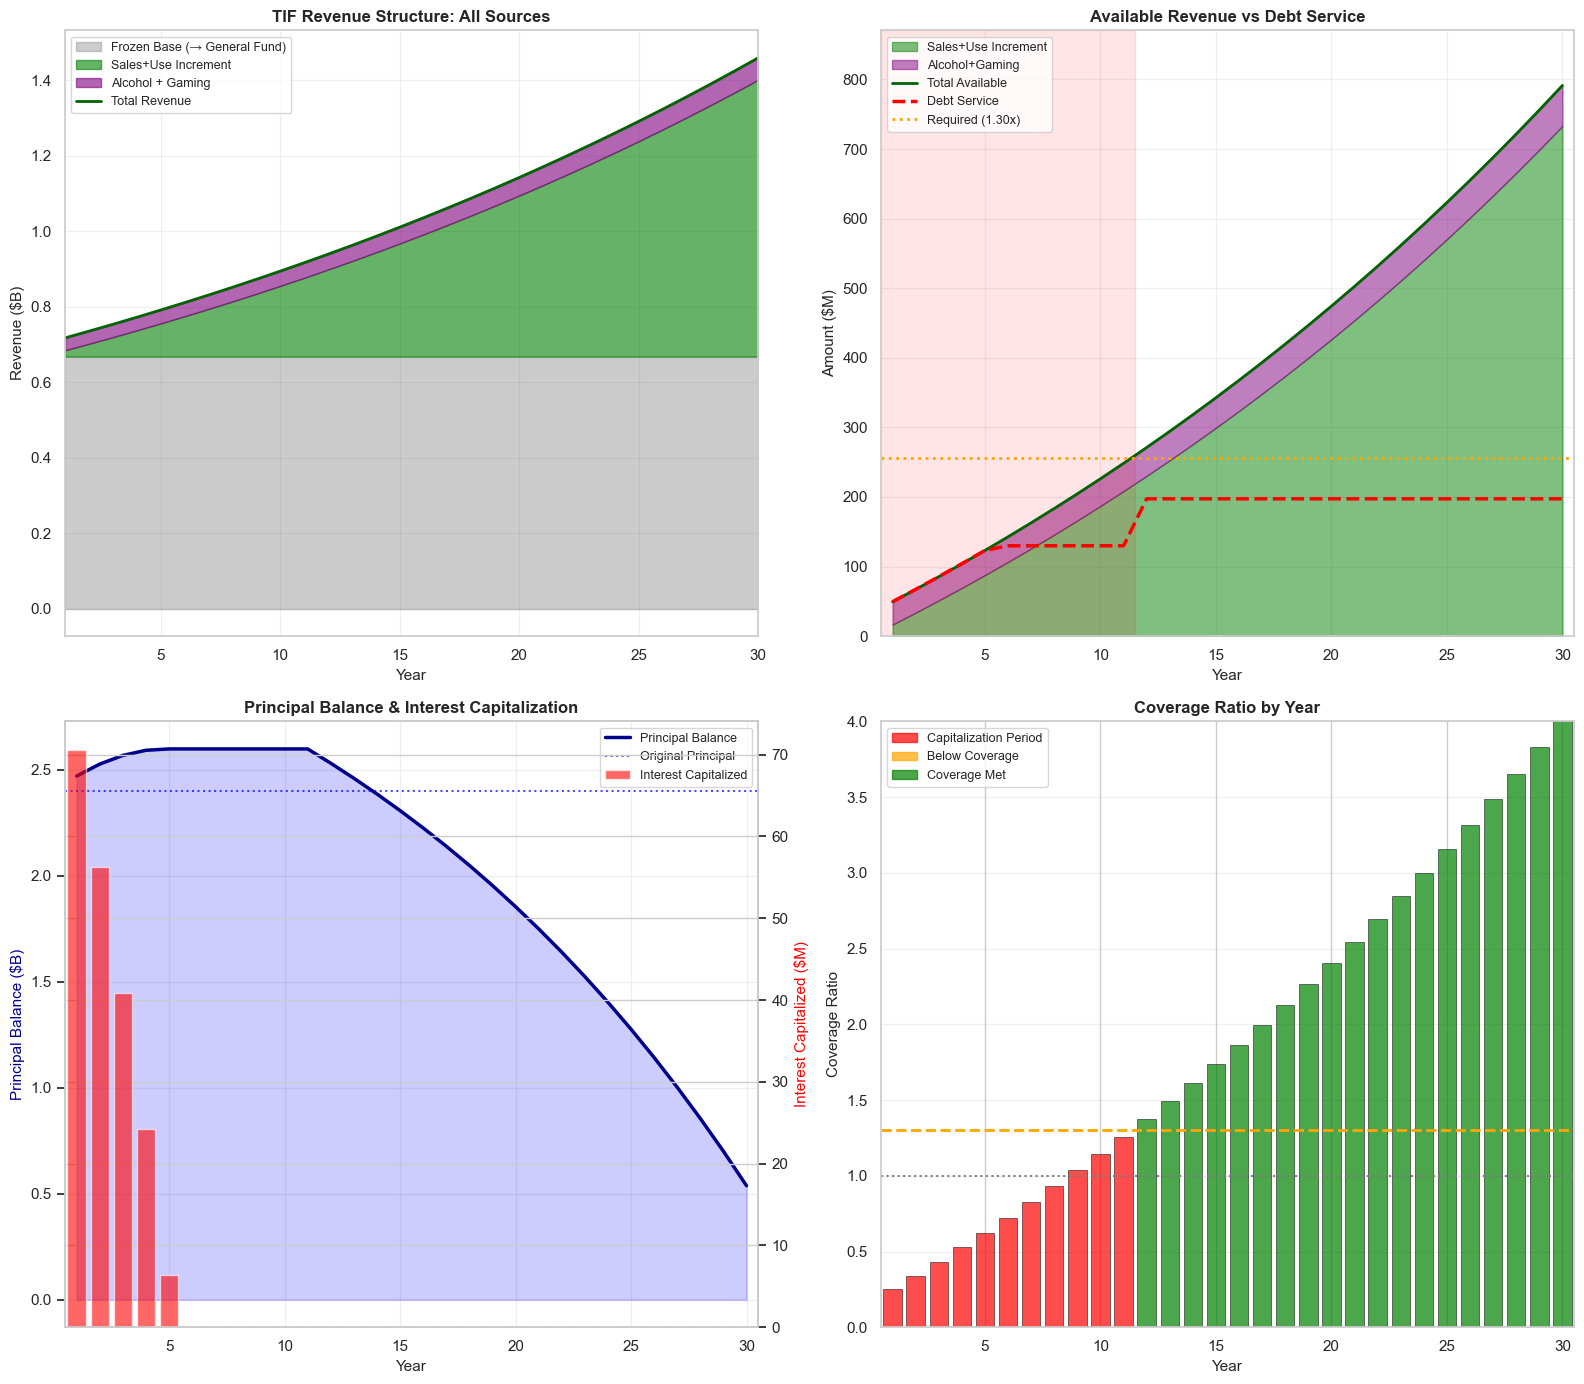

MAIN VISUALIZATION SAVED: data/tif_model_visualization.png


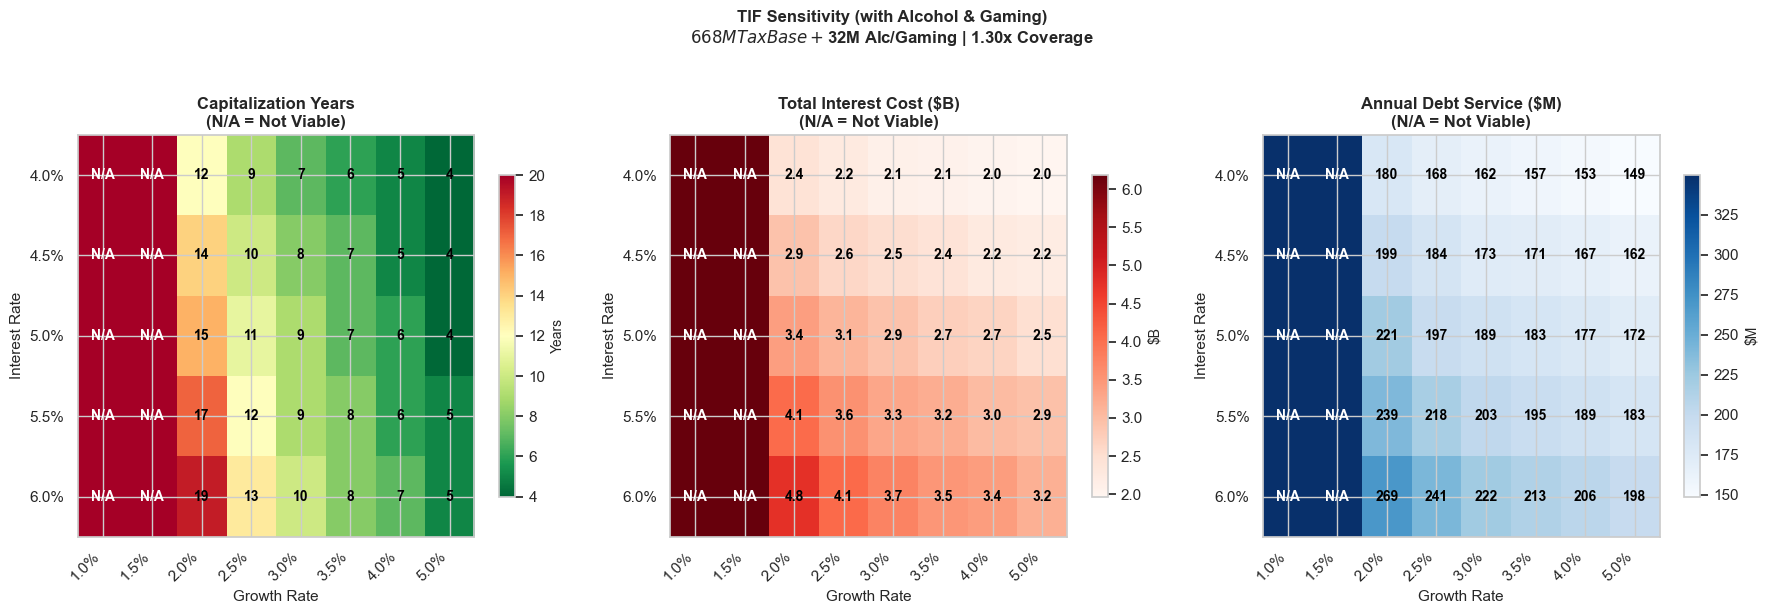

SENSITIVITY HEATMAPS SAVED: data/tif_sensitivity_heatmaps.png

⚠️  Non-viable scenarios: 10 of 40


In [504]:
# =============================================================================# TIF MODEL VISUALIZATIONS (with All Revenue Streams)# =============================================================================import matplotlib.pyplot as pltimport matplotlib.patches as mpatchesimport numpy as np# Use results from previous celltry:    _max_cap = MAX_CAP_YEARSexcept:    _max_cap = 20fig = plt.figure(figsize=(16, 14))# =============================================================================# PLOT 1: Revenue Stack - All Sources# =============================================================================ax1 = fig.add_subplot(2, 2, 1)years = increment_df['year'].valuesfrozen = increment_df['frozen_base'].values / 1e9increment = increment_df['sales_use_increment'].values / 1e9alc_gaming = increment_df['alcohol_gaming_total'].values / 1e9local = increment_df['local_add_in_total'].values / 1e9# Stack: frozen base, sales/use increment, alcohol/gaming, local add-insax1.fill_between(years, 0, frozen, alpha=0.4, color='gray', label='Frozen Base (→ General Fund)')ax1.fill_between(years, frozen, frozen + increment, alpha=0.6, color='green', label='Sales+Use Increment')ax1.fill_between(years, frozen + increment, frozen + increment + alc_gaming, alpha=0.6, color='purple', label='Alcohol + Gaming')ax1.fill_between(years, frozen + increment + alc_gaming, frozen + increment + alc_gaming + local,                  alpha=0.6, color='orange', label='Local Add-Ins')ax1.plot(years, frozen + increment + alc_gaming + local, color='darkgreen', linewidth=2, label='Total Revenue')ax1.set_xlabel('Year', fontsize=11)ax1.set_ylabel('Revenue ($B)', fontsize=11)ax1.set_title('TIF Revenue Structure: All Sources', fontsize=12, fontweight='bold')ax1.legend(loc='upper left', fontsize=9)ax1.set_xlim(1, 30)ax1.grid(True, alpha=0.3)# =============================================================================# PLOT 2: Debt Service & Coverage Over Time# =============================================================================ax2 = fig.add_subplot(2, 2, 2)years_cf = df_tif['year'].valuesincrement_cf = df_tif['sales_use_increment'].values / 1e6alc_cf = df_tif['alcohol_gaming'].values / 1e6local_cf = df_tif['local_add_in'].values / 1e6total_avail = df_tif['total_available'].values / 1e6ds = df_tif['debt_service'].values / 1e6# Stacked available revenueax2.fill_between(years_cf, 0, increment_cf, alpha=0.5, color='green', label='Sales+Use Increment')ax2.fill_between(years_cf, increment_cf, increment_cf + alc_cf, alpha=0.5, color='purple', label='Alcohol + Gaming')ax2.fill_between(years_cf, increment_cf + alc_cf, increment_cf + alc_cf + local_cf, alpha=0.5, color='orange', label='Local Add-Ins')ax2.plot(years_cf, total_avail, color='darkgreen', linewidth=2, label='Total Available')# Debt service lineax2.plot(years_cf, ds, 'r-', linewidth=2.5, label='Debt Service')# Required coverage linereq_coverage = summary_tif['level_debt_service'] * COVERAGE_RATIO / 1e6ax2.axhline(y=req_coverage, color='orange', linestyle='--', linewidth=2, label=f'Required @ {COVERAGE_RATIO:.2f}x')# Cap period shadingcap_years = summary_tif['capitalization_years']ax2.axvspan(0.5, cap_years + 0.5, alpha=0.1, color='red', label='Cap Period')ax2.set_xlabel('Year', fontsize=11)ax2.set_ylabel('Amount ($M)', fontsize=11)ax2.set_title('Available Revenue vs Debt Service', fontsize=12, fontweight='bold')ax2.legend(loc='upper left', fontsize=9)ax2.set_xlim(0.5, 30.5)ax2.grid(True, alpha=0.3)# =============================================================================# PLOT 3: Principal Balance & Capitalization# =============================================================================ax3 = fig.add_subplot(2, 2, 3)principal = df_tif['ending_principal'].values / 1e9int_cap = df_tif['interest_capitalized'].values / 1e6ax3.fill_between(years_cf, 0, principal, alpha=0.3, color='blue')ax3.plot(years_cf, principal, 'b-', linewidth=2.5, label='Principal Balance')ax3.axhline(y=INITIAL_PRINCIPAL/1e9, color='blue', linestyle=':', linewidth=1.5, alpha=0.7, label='Original Principal')# Interest capitalized as barsax3_twin = ax3.twinx()bar_colors = ['red' if ic > 0 else 'lightgray' for ic in int_cap]ax3_twin.bar(years_cf, int_cap, alpha=0.5, color=bar_colors, label='Interest Capitalized')ax3_twin.set_ylabel('Interest Capitalized ($M)', fontsize=10, color='red')ax3.set_xlabel('Year', fontsize=11)ax3.set_ylabel('Principal ($B)', fontsize=11, color='blue')ax3.set_title('Principal Balance & Capitalization', fontsize=12, fontweight='bold')ax3.legend(loc='upper right', fontsize=9)ax3.set_xlim(0.5, 30.5)ax3.grid(True, alpha=0.3)# =============================================================================# PLOT 4: Coverage Ratio# =============================================================================ax4 = fig.add_subplot(2, 2, 4)coverage = df_tif['coverage_ratio'].valuesin_cap = df_tif['in_cap_period'].valuesbar_colors = ['red' if cap else ('orange' if cov < COVERAGE_RATIO else 'green')               for cap, cov in zip(in_cap, coverage)]ax4.bar(years_cf, coverage, color=bar_colors, alpha=0.7, edgecolor='black', linewidth=0.5)ax4.axhline(y=COVERAGE_RATIO, color='orange', linestyle='--', linewidth=2, label=f'Required ({COVERAGE_RATIO:.2f}x)')ax4.axhline(y=1.0, color='gray', linestyle=':', linewidth=1.5)ax4.set_xlabel('Year', fontsize=11)ax4.set_ylabel('Coverage Ratio', fontsize=11)ax4.set_title('Coverage Ratio by Year', fontsize=12, fontweight='bold')ax4.set_xlim(0.5, 30.5)ax4.set_ylim(0, min(6, max(coverage) * 1.1))ax4.grid(True, alpha=0.3, axis='y')# Legendcap_patch = mpatches.Patch(color='red', alpha=0.7, label='Cap Period')gap_patch = mpatches.Patch(color='orange', alpha=0.7, label='Below Coverage')ok_patch = mpatches.Patch(color='green', alpha=0.7, label='Coverage Met')ax4.legend(handles=[cap_patch, gap_patch, ok_patch], loc='upper left', fontsize=9)plt.tight_layout()plt.savefig('data/tif_model_visualization.png', dpi=150, bbox_inches='tight', facecolor='white')plt.show()print("\nVisualization saved to: data/tif_model_visualization.png")# =============================================================================# SENSITIVITY HEATMAPS (Updated)# =============================================================================fig2, axes = plt.subplots(1, 3, figsize=(18, 6))pivot_cap = sens_tif.pivot(index='interest_rate', columns='growth_rate', values='cap_years')pivot_int = sens_tif.pivot(index='interest_rate', columns='growth_rate', values='total_interest_B')pivot_ds = sens_tif.pivot(index='interest_rate', columns='growth_rate', values='debt_service_M')# Heatmap 1: Cap Yearscap_vals = pivot_cap.values.astype(float)cap_display = np.where(np.isnan(cap_vals), _max_cap, cap_vals)im1 = axes[0].imshow(cap_display, cmap='RdYlGn_r', aspect='auto', vmin=2, vmax=_max_cap)axes[0].set_xticks(range(len(pivot_cap.columns)))axes[0].set_xticklabels([f'{g:.1%}' for g in pivot_cap.columns], rotation=45, ha='right')axes[0].set_yticks(range(len(pivot_cap.index)))axes[0].set_yticklabels([f'{r:.1%}' for r in pivot_cap.index])axes[0].set_xlabel('Growth Rate')axes[0].set_ylabel('Interest Rate')axes[0].set_title('Capitalization Years', fontweight='bold')for i in range(len(pivot_cap.index)):    for j in range(len(pivot_cap.columns)):        val = cap_vals[i, j]        txt = 'N/A' if np.isnan(val) else f'{val:.0f}'        color = 'white' if np.isnan(val) else 'black'        axes[0].text(j, i, txt, ha='center', va='center', color=color, fontweight='bold')fig2.colorbar(im1, ax=axes[0], shrink=0.8)# Heatmap 2: Total Interestint_vals = pivot_int.values.astype(float)int_max = np.nanmax(int_vals) * 1.2 if not np.all(np.isnan(int_vals)) else 5int_display = np.where(np.isnan(int_vals), int_max, int_vals)im2 = axes[1].imshow(int_display, cmap='Reds', aspect='auto')axes[1].set_xticks(range(len(pivot_int.columns)))axes[1].set_xticklabels([f'{g:.1%}' for g in pivot_int.columns], rotation=45, ha='right')axes[1].set_yticks(range(len(pivot_int.index)))axes[1].set_yticklabels([f'{r:.1%}' for r in pivot_int.index])axes[1].set_xlabel('Growth Rate')axes[1].set_ylabel('Interest Rate')axes[1].set_title('Total Interest ($B)', fontweight='bold')for i in range(len(pivot_int.index)):    for j in range(len(pivot_int.columns)):        val = int_vals[i, j]        txt = 'N/A' if np.isnan(val) else f'{val:.1f}'        color = 'white' if np.isnan(val) else 'black'        axes[1].text(j, i, txt, ha='center', va='center', color=color, fontweight='bold')fig2.colorbar(im2, ax=axes[1], shrink=0.8)# Heatmap 3: Debt Serviceds_vals = pivot_ds.values.astype(float)ds_max = np.nanmax(ds_vals) * 1.2 if not np.all(np.isnan(ds_vals)) else 300ds_display = np.where(np.isnan(ds_vals), ds_max, ds_vals)im3 = axes[2].imshow(ds_display, cmap='Blues', aspect='auto')axes[2].set_xticks(range(len(pivot_ds.columns)))axes[2].set_xticklabels([f'{g:.1%}' for g in pivot_ds.columns], rotation=45, ha='right')axes[2].set_yticks(range(len(pivot_ds.index)))axes[2].set_yticklabels([f'{r:.1%}' for r in pivot_ds.index])axes[2].set_xlabel('Growth Rate')axes[2].set_ylabel('Interest Rate')axes[2].set_title('Annual Debt Service ($M)', fontweight='bold')for i in range(len(pivot_ds.index)):    for j in range(len(pivot_ds.columns)):        val = ds_vals[i, j]        txt = 'N/A' if np.isnan(val) else f'{val:.0f}'        color = 'white' if np.isnan(val) else 'black'        axes[2].text(j, i, txt, ha='center', va='center', color=color, fontweight='bold')fig2.colorbar(im3, ax=axes[2], shrink=0.8)plt.suptitle('TIF Sensitivity Analysis (All Revenue Streams)', fontsize=14, fontweight='bold', y=1.02)plt.tight_layout()plt.savefig('data/tif_sensitivity_heatmaps.png', dpi=150, bbox_inches='tight', facecolor='white')plt.show()print("Sensitivity heatmaps saved to: data/tif_sensitivity_heatmaps.png")